# Notebook 18 - building the sediment model, and closing an order-of-magnitude gap

**Stage C3** of the Magdalena-Cauca ENSO sediment study. Phase A built the model's inputs,
Phase B calibrated and then *froze* a daily water balance, and this notebook is the first
attempt to turn that water into **suspended sediment**.

**What this notebook is.** A construction record and an audit trail for one equation - the
Modified Universal Soil Loss Equation (MUSLE), an empirical formula that turns a day's runoff into a
mass of eroded soil, defined properly in section 1 - applied to 8,672 sub-catchments of the
Magdalena basin over ten years. It states where every one of MUSLE's seven factors comes from,
which are measured, which are assumed and which are still to be fitted; it shows the two
judgement calls that had to be made about topography; and it documents in full the arithmetic
error that made the first run **363x too small**, how that error was found, and what is still
wrong afterwards.

**What this notebook is NOT.**

* It is **not a calibration.** The two MUSLE coefficients are the published 1975 values, used
  unchanged. Nothing here is fitted to any sediment measurement. Fitting is stage C4.
* It is **not a result.** The final number is a *lower bound* whose level is not validated, and
  the study's headline ENSO comparison appears here only as a first look, explicitly labelled.
* It does **not re-run the hydrology.** The water balance is frozen and is read read-only. The
  sediment engine itself runs in about 2 seconds, so every number below is recomputed here
  rather than quoted from a document - and where a document and this notebook's output disagree,
  the disagreement is reported.

**The five questions this notebook answers.**

1. What does MUSLE need, and where does each input come from? (Section 2.)
2. The topographic factor could plausibly be built four different ways that differ by 6x.
   Which one, and on what grounds? (Section 3 - and the answer includes one thing that is still
   **unresolved and points the wrong way**.)
3. MUSLE needs an instantaneous peak flow. A daily model has none. What was substituted, and
   what does that cost? (Section 4.)
4. The first run came out 210x below the published sediment load of this river - and *below*,
   which is the physically impossible direction. Why? (Section 5, the centrepiece.)
5. Is the corrected level defensible? (Section 6: **no, not yet** - and the reason is not the one
   this project believed a day earlier.)

**Sections 7 and 8 are the point of the notebook as much as sections 2-6.** Section 7 is a
problems register: what was tried and failed, what was measured and refuted, which earlier
claims in this project's own documents were wrong, and what a reader must *not* conclude.
Section 8 reports the ENSO signal and immediately says why it is not evidence.

## 0.1 - Prerequisites, and what each one contributes

| Prerequisite | What it provides | Read-only? |
|---|---|---|
| `src/mgb_sediment.py` | the MUSLE engine (the thing this notebook documents) | imported |
| `scripts/c3/qpeak.py` | the registered peak-flow proxy and the pre-registered parameter guards | imported via the engine |
| `data/processed/sim_calibrated_v2/h2e_drivers.npz` | **frozen** *surface runoff* (the fast, overland part of streamflow - defined with everything else in §0.2) from Phase B, 3,652 days x 8,672 units, 546 MB | **yes, frozen twice** |
| `data/processed/minibacias.csv` | the 8,672 sub-catchments (*minibacias*) and their areas | yes |
| `data/processed/urh_fractions.csv` | how each sub-catchment splits into 24 soil-x-cover classes (*URH*) | yes |
| `data/processed/minibacia_soil_params.csv` | soil erodibility `K` per sub-catchment | yes |
| `data/processed/urh_cp_factors.csv` | cover `C` and practice `P` per land class, with sources and ranges | yes |
| `data/processed/urh_ls2d.csv`, `minibacia_ls2d.csv` | the topographic factor, four variants each | yes |
| `data/processed/sim_calibrated_v2/parameters_H2E.csv`, `report_H2E.json` | the frozen hydrology's parameters and scores | **yes, frozen** |

If a prerequisite is missing this notebook stops rather than substituting anything. The frozen
files are opened read-only and nothing in this notebook writes into `data/`.

*The table above is a file inventory and unavoidably names a few things before they are explained.
Sections 0.2-0.4 define, in plain language, every term this notebook inherits - spatial units,
runoff paths, scoring statistics, the interpolation vocabulary and the sediment-measurement
vocabulary - and section 1 defines MUSLE and each of its factors. Nothing later assumes a word that
those four sections have not introduced.*

In [1]:
import hashlib, json, math, pathlib, sys, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False, 'font.size': 9,
                     'axes.titlesize': 9.5, 'figure.autolayout': False})

# a small fixed palette, so the notebook reads as one document and needs no style package
CB = {'blue': '#1F6FB2', 'red': '#B0412B', 'green': '#1D9E75', 'amber': '#D9930D',
      'purple': '#6A4C93', 'grey': '#6E6E6E', 'dark': '#243447', 'pink': '#C2477F'}

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b / 'src' / 'mgb_sediment.py').exists() and (b / 'data' / 'processed').exists():
        REPO = b
        break
if REPO is None:
    raise SystemExit('cannot locate the repository root')
PROC = REPO / 'data' / 'processed'
FROZEN = PROC / 'sim_calibrated_v2'
sys.path.insert(0, str(REPO / 'src'))

need = [REPO / 'src' / 'mgb_sediment.py', REPO / 'scripts' / 'c3' / 'qpeak.py',
        REPO / 'scripts' / 'c3' / 'ls2d.py',
        FROZEN / 'h2e_drivers.npz', FROZEN / 'parameters_H2E.csv', FROZEN / 'report_H2E.json',
        PROC / 'minibacias.csv', PROC / 'urh_fractions.csv', PROC / 'minibacia_soil_params.csv',
        PROC / 'urh_cp_factors.csv', PROC / 'urh_ls2d.csv', PROC / 'minibacia_ls2d.csv']
missing = [str(p.relative_to(REPO)) for p in need if not p.exists()]
if missing:
    raise SystemExit(f'PREREQUISITES MISSING, stopping rather than improvising: {missing}')

import mgb_sediment as sed
sys.path.insert(0, str(REPO / 'scripts' / 'c3'))
import qpeak as qpk

eng = (REPO / 'src' / 'mgb_sediment.py').read_bytes()
print(f'repo            {REPO}')
print(f'engine          src/mgb_sediment.py  {len(eng)/1024:.1f} kB  '
      f'sha256 {hashlib.sha256(eng).hexdigest()[:16]}')
print(f'engine exports  {len(sed.__all__)} names')
print(f'frozen driver   {FROZEN/"h2e_drivers.npz"}  '
      f'{(FROZEN/"h2e_drivers.npz").stat().st_size/1e6:.1f} MB  (READ-ONLY)')
print(f'Williams (1975) starting coefficients:  alpha = {sed.WILLIAMS_ALPHA}, '
      f'beta = {sed.WILLIAMS_BETA}')
print(f'registered application scale a_p     =  {sed.COP90_PIXEL_AREA_KM2} km2 '
      f'(= a {math.sqrt(sed.COP90_PIXEL_AREA_KM2)*1000:.0f} m DEM pixel)')
print(f'named unit conventions available     :  {sed.VOLUME_CONVENTIONS}')
print(f'named K unit systems available       :  {sed.K_UNIT_SYSTEMS}')
print(f'named C/P revisions available        :  {sed.CP_REVISION_NAMES}')

repo            C:\dev\magdalena-mgb-sed
engine          src/mgb_sediment.py  83.3 kB  sha256 fb30db62793ab86a
engine exports  44 names
frozen driver   C:\dev\magdalena-mgb-sed\data\processed\sim_calibrated_v2\h2e_drivers.npz  546.4 MB  (READ-ONLY)
Williams (1975) starting coefficients:  alpha = 11.8, beta = 0.56
registered application scale a_p     =  0.0081 km2 (= a 90 m DEM pixel)
named unit conventions available     :  ('pixel_km2', 'swat_mm_ha', 'williams_m3')
named K unit systems available       :  ('si_stored', 'us_customary')
named C/P revisions available        :  ('cited_central_2026_08_11', 'prior_2026_08_11', 'cited_low_2026_08_11', 'cited_high_2026_08_11', 'pacheco_practice_2026_08_11')


## 0.2 - The vocabulary this notebook inherits, in plain language

Nothing below is optional reading: every one of these words is used later, and each is defined
here at its first appearance because the sediment model is built on all of them.

**The spatial units.** The basin is cut into 8,672 **minibacias** - small sub-catchments,
literally "mini-basins" in Portuguese, the unit of the MGB model family this project transposes.
Each drains into exactly one downstream neighbour, so the whole set forms a tree ending at the
river mouth. A minibacia here is 1.6-313 km<sup>2</sup>, median 25.6 km<sup>2</sup>. Inside each
minibacia the land is *not* treated as uniform: it is split into **URH** classes
(*unidades de resposta hidrologica*, hydrological response units - the same idea English-language
models call **HRU**). A URH is a combination of soil family (coarse / medium / fine texture) and
land cover (forest, shrub, grassland, cropland, urban, bare, water, wetland), giving 3 x 8 = 24
possible classes, of which 32,782 (minibacia, URH) combinations actually occur. All cells of one
class inside one minibacia are treated as one lump; the split is by *area fraction*, not by
location, so a URH cell has an area but no shape.

**The water balance.** A **water balance** is bookkeeping: for each patch of land and each day,
rain in, evaporation out, runoff out, and whatever is left changes the amount of water stored in
the soil. Nothing is created or destroyed; that closure is what makes the accounting checkable.
Phase B's engine solves such a balance per URH per day.

**How rain becomes runoff.** This model uses **saturation-excess runoff**: rain that falls on
already-saturated ground runs off immediately, and the *fraction* of a URH that is saturated
grows as its soil fills. (The alternative mechanism, *infiltration excess*, is rain arriving
faster than the soil can absorb it; it was tested for this basin and refuted.) Runoff then
splits into three paths with very different speeds. **Surface runoff** is the fast path -
overland flow reaching the stream within a day or so - and it is the *only* path that matters
for erosion, because it is the only one with enough energy to detach and carry soil.
**Baseflow** is the slow path: water that percolated to groundwater and seeps out over weeks,
sustaining the river between storms. Each path is drained by a linear store whose emptying rate
is set by a **recession constant** $K$ (days): the store releases a fixed *fraction* of itself
per day, so an isolated pulse decays as $Q(t)=Q_0e^{-t/K}$. Large $K$ means slow, smooth,
long-memory flow. The **baseflow index (BFI)** is the fraction of total streamflow that came by
the slow path - a number between 0 and 1 - and the **Eckhardt filter** is a standard recursive
digital filter that separates a measured hydrograph into fast and slow components so a BFI can
be estimated from observations alone. Neither BFI nor the filter is used in the sediment
calculation; they appear because Phase B used them to check that the frozen model splits water
between the paths at roughly the observed proportion.

**Evaporation, in two flavours.** **PET** (potential evapotranspiration) is the atmospheric
*demand*: how much water would evaporate from a well-watered surface under the day's radiation,
temperature, humidity and wind. **Actual ET** is what really leaves, which is the smaller of that
demand and what the soil can supply. The distinction matters for erosion only indirectly - a
model that evaporates too little leaves the soil too wet, produces too much surface runoff, and
therefore too much sediment.

## 0.3 - How Phase B's hydrology was judged, and the words used for it

The sediment model inherits the surface runoff of one specific frozen configuration, called
**H2E**. Its quality bounds everything downstream, so the scoring vocabulary is defined here.

**KGE and its three parts.** The **Kling-Gupta efficiency** compares a simulated series with an
observed one and decomposes the comparison into three independent failures:

$$\mathrm{KGE} = 1-\sqrt{(r-1)^2+(\alpha-1)^2+(\beta-1)^2}$$

* $r$ - **Pearson correlation** between simulated and observed. It measures *timing and shape*
  only: whether the peaks and troughs happen on the right days. It is blind to any error that
  scales or shifts the whole series.
* $\alpha = \mathrm{sd(sim)}/\mathrm{sd(obs)}$ - the **variability ratio**. $\alpha<1$ means the
  model is too flat, $\alpha>1$ too spiky.
* $\beta = \mathrm{mean(sim)}/\mathrm{mean(obs)}$ - the **bias ratio**. $\beta=1.1$ means 10 %
  too much water overall.

KGE = 1 is perfect; a model with all three parts right cannot have a bad KGE, and a model with a
good KGE cannot be badly wrong in any single part. (Note: this $\alpha$ and $\beta$ are the KGE
components. MUSLE has its own, entirely unrelated, $\alpha$ and $\beta$ - a coefficient and an
exponent. The collision is unfortunate and both are standard; from section 2 onward $\alpha$ and
$\beta$ always mean MUSLE's.)

**NSE, and why it is window-dependent.** The **Nash-Sutcliffe efficiency** is
$1-\sum(sim-obs)^2/\sum(obs-\overline{obs})^2$: the model's squared error divided by the squared
error of simply predicting the observed *mean of that window*. NSE = 0 means "no better than the
window mean", NSE = 1 is perfect. The catch is in the denominator: it is computed from the same
window being scored, so the yardstick moves. Score a wet year and a dry year separately and the
dry year's denominator is small, so an identical absolute error yields a far worse NSE. NSE
therefore cannot be compared across windows of different variance - which is exactly what an
ENSO contrast study wants to do - and that is why KGE, whose parts are separately interpretable,
is preferred here.

**PBIAS** is percent bias, $100\sum(sim-obs)/\sum obs$: total simulated water minus total
observed, as a percentage of observed. Positive means too much water.

**The climatology benchmark.** Asking whether a model is *good* is meaningless without asking
"better than what?". The **climatology benchmark** is the cheapest defensible competitor: for
each calendar day, predict the average of all observations on that day-of-year. It knows the
season and nothing else. A model that cannot beat it has added no information about *this*
year - and in the El Nino 2015-16 dry phase, the frozen hydrology's skill over climatology is
-0.0005, i.e. it sits exactly *at* climatology. That measured fact is why every dry-phase claim
in this project is hedged.

**How the hydrology was fitted, and the discipline around it.** An **objective function** is the
single number a search tries to optimise - here a weighted combination of KGE, bias and a
recession term across many gauges. **DDS** (Dynamically Dimensioned Search) is the search
algorithm: it starts from one candidate and perturbs a *shrinking* random subset of parameters,
so it explores widely early and refines late, needing no gradients and no population. It is used
because the objective is cheap-ish, non-smooth and moderately dimensioned.

**Pre-registration** is the practice this project leans on hardest: writing down the choice, the
threshold and the decision rule *before* computing the result they will be applied to. It is not
paperwork. Its purpose is to make a specific failure impossible - the failure where a number
comes out unattractive and the criterion quietly moves. Sections 4 and 5 both rest on
pre-registrations, and one of them (`docs/35` §9.3) registers in advance an outcome that makes
this project's own result *worse*.

**The Klemes differential split-sample test** is the strong form of validation for a model that
will be used outside the conditions it was fitted in: fit on one climatic period and score on a
*different* one, deliberately chosen to be unlike it - here, fit on ordinary years, score on the
extreme La Nina and El Nino. It answers "does this model transfer?", which ordinary
random-split validation cannot.

**A railed parameter** is one the search drove to the very edge of its allowed range. It is a
red flag, not a result: it usually means the parameter is standing in for a mechanism the model
lacks. Phase B rejected a peak-fixing refit precisely because it reached the target only by
railing one coefficient and zeroing another - which amounted to deleting canopy interception.

**Equifinality** is the condition where many different parameter sets fit the data equally well,
so the fit cannot tell you which is right. It is the central obstacle in section 7.2: MUSLE's
coefficient, the cover factor and the topographic factor are *multiplied together*, so any fit
sees only their product.

In [2]:
par_h2e = pd.read_csv(FROZEN / 'parameters_H2E.csv')
rep_h2e = json.loads((FROZEN / 'report_H2E.json').read_text())
print('FROZEN HYDROLOGY H2E - the input this notebook is not allowed to change')
print(f'  parameter file  {len(par_h2e)} rows, columns {list(par_h2e.columns)}')
with pd.option_context('display.width', 120, 'display.max_rows', 40):
    print(par_h2e.to_string(index=False))
print()


def dig(obj, *keys):
    '''Fetch the first present key path from a nested report dict, else None.'''
    for k in keys:
        cur, ok = obj, True
        for part in k.split('.'):
            if isinstance(cur, dict) and part in cur:
                cur = cur[part]
            else:
                ok = False
                break
        if ok:
            return cur
    return None


print('  report_H2E.json top-level keys:', sorted(rep_h2e))
for label, paths in [('VAL KGE', ('val.kge', 'validation.kge', 'metrics.val_kge')),
                     ('VAL PBIAS', ('val.pbias', 'validation.pbias'))]:
    v = dig(rep_h2e, *paths)
    if v is not None:
        print(f'  {label}: {v}')

FROZEN HYDROLOGY H2E - the input this notebook is not allowed to change
  parameter file  18 rows, columns ['parameter', 'scope', 'value', 'prior', 'lo', 'hi', 'pos', 'railed']
 parameter       scope     value     prior     lo     hi      pos railed
       adr      global  0.007594  0.060000 0.0005   0.30 0.425287    NaN
      fint      global  0.754034  0.600000 0.0500   0.95 0.782260    NaN
         b      global  0.356675  0.600000 0.0500   4.00 0.448378    NaN
   wm_mult      global  0.389087  1.000000 0.2500   6.00 0.139187    NaN
   kc_mult      global  1.662469  1.000000 0.5000   2.00 0.774979    NaN
  lai_mult      global  1.003579  1.000000 0.0000   5.00 0.200716    NaN
     k_sup      global 19.199325  1.500000 0.2000  20.00 0.991128    YES
k_int_frac      global  0.020142  0.133333 0.0200   0.90 0.001853    YES
     k_bas      global 42.973988 60.000000 5.0000 600.00 0.449329    NaN
  celerity      global  0.326627  1.000000 0.0500   4.00 0.428294    NaN
     k_sup          

**Why the cell above prints the file rather than a curated summary.** The frozen hydrology's
headline numbers are quoted throughout this project's documents (validation KGE 0.356, PBIAS
+3.5 %, recession ratio 0.98x, El Nino skill-over-climatology -0.0005, La Nina +0.106, and a
correlation ceiling of 0.556-0.572 inherited from the rainfall field). Rather than retype them,
the cell opens the two frozen artifacts and prints what is actually in them, so a reader can see
the provenance and catch a drift between document and file. The `report_H2E.json` key layout is
not assumed - the helper tries several paths and prints the top-level keys either way.

**The one number that matters most for what follows.** The correlation ceiling. Phase B was
closed twice, the second time on a *measured conflict* rather than on a lack of effort: a refit
that hit the flood-peak target did so only by railing one parameter and zeroing another, which
physically amounted to deleting the forest canopy. The peak deficit is therefore structural, and
it is a named, published limitation of the source model family, not a local mistake. Section 4.5
puts numbers on what that costs the sediment estimate, and section 7 records why fixing it was
deliberately *not* attempted.

## 0.4 - Two more vocabularies: the rainfall field, and the sediment measurements

**Where the rainfall came from, and the three words that describe it.** The runoff driving this
sediment model came from a rainfall field built by interpolating rain gauges. **IDW** - inverse
distance weighting - estimates rainfall at an unmeasured point as a weighted average of nearby
gauges, with each gauge's weight falling off as $1/d^{p}$ in distance $d$. It is simple and
makes no assumptions about spatial correlation structure, which is also its weakness: it cannot
extrapolate above the highest gauge value, so it systematically flattens extremes. **LOOCV** -
leave-one-out cross-validation - is how such an interpolation is scored honestly: remove one
gauge, predict its value from all the others, repeat for every gauge, and measure the errors on
predictions that never saw the answer. **Quantile mapping** is a bias-correction: given a
modelled or satellite-derived series and a trusted observed one, replace each modelled value by
the observed value at the *same cumulative probability*, so the whole distribution is remapped
rather than just the mean. It was used and tested here; the corrected field was rejected on
pre-registered grounds because it did not move the binding constraint. All three matter to this
notebook for one reason: **the correlation ceiling of the hydrology is inherited from the
rainfall field, not from any parameter**, and sediment inherits it in turn.

**What the sediment observations are.** **SSC** is *suspended-sediment concentration*: the mass
of solid particles carried per unit volume of water, typically mg/L, measured by filtering a
water sample. It is not a flux. To get a flux (mass per time) you multiply concentration by
discharge, and because concentration is sampled only occasionally while discharge is recorded
daily, the standard device is a **rating curve**: a fitted relation, usually a power law
$C=aQ^{b}$ on logarithms, that predicts concentration from discharge so that the sparse samples
can be expanded to the full daily record. Rating curves are the weakest link in any sediment
budget - they are fitted on a handful of samples, they are biased when back-transformed from
logarithms, and they cannot represent hysteresis (the same discharge carrying different loads on
the rising and falling limbs of a flood).

**Two words for how erosion is reported.** **Specific erosion** is erosion per unit area, e.g.
tonnes per square kilometre per year - a *rate*, so basins of different size can be compared.
This project draws a hard line here: figures computed as *the model's own erosion divided by the
model's own minibacia area* are called **model-internal specific erosion** and are used only to
describe the model's spatial pattern; **gauge-referenced yields in t/km<sup>2</sup>/yr are
embargoed**, because the catchment areas attributed to the measuring stations were found to
disagree by more than a factor of two on 36 % of shared gauges, and any per-area yield inherits
that error one-for-one. **Sediment delivery ratio (SDR)** is the fraction of the soil eroded
somewhere in a basin that actually leaves it past a measuring point; it is the subject of
section 6 and it turns out to be the trickiest definition in the notebook.

**Two words for how floods are counted.** An **annual maximum series (AMS)** takes the single
largest value in each year - one number per year, simple, but it throws away the second and
third floods of a busy year and keeps the trivial maximum of a quiet one. A **POT** series
(peaks over threshold) instead takes every independent excursion above a fixed level, so a busy
year contributes many events and a quiet one none. POT is the sharper instrument for asking
"does the model produce floods *at all*", and section 4.5 uses it for exactly that.

## 1 - The equation, in words before symbols

MUSLE - the **Modified Universal Soil Loss Equation** (Williams, 1975) - predicts how much soil
a storm strips off a patch of land. It is *modified* from USLE, the Universal Soil Loss Equation
(Wischmeier & Smith, 1978), in one specific way that is the whole reason it is used here.

USLE predicts long-term average soil loss from **rainfall energy**: how hard the rain hits.
That makes it an annual-average tool and it says nothing about individual events. Williams
replaced the rainfall-energy term with a **runoff-energy** term - the volume of surface runoff
multiplied by its peak rate - and refitted the coefficient against sediment yields *measured at
the outlets* of small watersheds. Two consequences follow, and both matter later:

1. MUSLE works **per event / per day**, which is what a daily model can drive.
2. Because runoff already encodes how much water was available to *carry* the soil away, MUSLE's
   output is closer to "sediment delivered from this patch to its stream" than to "soil detached
   on this patch". Section 6 shows this distinction is not pedantic - a whole closure gate was
   retired over it.

The equation, as this project applies it:

$$\mathrm{Sed} \;=\; \alpha \,\bigl(Q_{sur}\cdot q_{peak}\cdot A\bigr)^{\beta}\;
K \cdot C \cdot P \cdot LS \cdot FG$$

| symbol | plain meaning | units | class |
|---|---|---|---|
| $\mathrm{Sed}$ | soil loss from the unit, that day | t d$^{-1}$ | output |
| $\alpha$ | the fitted constant that sets the whole scale | (unit-dependent) | **assumed** (Williams 11.8), to be **fitted** in C4 |
| $\beta$ | the exponent that decides how much big events dominate | dimensionless | **assumed** (Williams 0.56), to be **fitted** in C4 |
| $Q_{sur}$ | surface runoff depth generated that day | mm d$^{-1}$ | **data** (frozen Phase B) |
| $q_{peak}$ | the *instantaneous peak* runoff rate of that day | m<sup>3</sup> s$^{-1}$ | **proxy** - section 4 |
| $A$ | area of the patch MUSLE is applied to | km<sup>2</sup> (see section 5.2) | **data** |
| $K$ | soil erodibility - how easily this soil detaches | t ha h ha$^{-1}$ MJ$^{-1}$ mm$^{-1}$ (SI) | **data** (IGAC soils) |
| $C$ | cover - how much the vegetation protects the surface | dimensionless, 0-1 | **cited** (section 2.4) |
| $P$ | support practice - terracing, contour ploughing, etc. | dimensionless, 0-1 | **assumed** = 1.0 |
| $LS$ | topography - slope length and steepness | dimensionless | **derived** (section 3) |
| $FG$ | coarse-fragment shielding by surface stones | dimensionless, 0-1 | **assumed** = 1.0 |

**Read the "class" column carefully, because it is the honest summary of this stage.** Two of the
eight factors are measured data, one is derived from a DEM by a documented formula, one is now
cited with a range, three are assumed, and the two that set the *scale* are unfitted published
constants. That is not a validated model; it is a defensible starting point, and the rest of this
notebook is about being precise on which is which.

**$\alpha$ and $\beta$: what a regression coefficient is, and what it is not.** Williams fitted
$\alpha$ and $\beta$ to 18 small watersheds in Texas and Nebraska. They are *not* physical
constants: $\alpha$ carries whatever dimensions make the equation balance, and its numerical
value therefore depends entirely on the units the other factors are fed in. That single sentence
is the whole of section 5: the first run of this model was 363x too small because $\alpha=11.8$
was paired with the wrong units for two different factors at once.

**$P=1.0$ and $FG=1.0$ are assumptions, and they are one-sided.** Both are defined as
$\le 1$ - they can only *reduce* erosion below the reference condition. Setting them to 1 is
therefore an *upper* bound on the erosion they permit, so any true value makes the model produce
*less*. This matters in section 6: the model is already short of the level it should reach, and
these two terms can only make that worse. Recording a one-sided assumption together with its
direction is the difference between a caveat and a hidden error.

## 2.1 - $Q_{sur}$: the surface runoff that drives everything

**What the cell computes.** It opens the frozen driver bundle and reports the distribution of the
one field MUSLE is driven by. No arithmetic beyond summary statistics.

$$Q_{sur}(t,i)\;=\;\texttt{h2e\_drivers.npz:qsur\_rel\_mm}[t,i]$$

where $t$ indexes 3,652 days (2009-01-01 to 2018-12-31, the Phase B scoring period with its
warm-up year already excluded) and $i$ indexes 8,672 minibacias. Units: **mm d$^{-1}$**, i.e. a
depth of water per day, per minibacia. Shape produced: `(3652, 8672)` float32, 121 MB.

**Which runoff field, and why it is the *released* one.** The bundle carries two candidates.
`qsur_gen_mm` is runoff *generated* on the land surface that day; `qsur_rel_mm` is runoff
*released* into the stream after passing through the fast linear store, i.e. the same water,
smoothed by the store's short memory. The registered choice is `qsur_rel_mm`, fixed in
`docs/35` §1 before this engine existed. **Rejected alternative:** `qsur_gen_mm`, which is
strictly what the source method's own equation uses. It is rejected only because the
registration predates the engine and switching a registered input after seeing a result is the
precise ordering violation pre-registration exists to prevent. The difference is *measured*, not
waved away: driving MUSLE with generated instead of released runoff raises the basin total by
**1.125x**, because the runoff-energy term is convex in $Q_{sur}$ (its exponent is
$2\beta=1.12>1$), so smoothing the water before MUSLE yields less sediment than
MUSLE-then-smoothing. Both fields remain reachable by name.

In [3]:
t0 = time.perf_counter()
DRV = sed.load_drivers(FROZEN / 'h2e_drivers.npz')   # read-only
Q = DRV.qsur_mm                                      # (3652, 8672) float32, mm/day
DATES = pd.DatetimeIndex(np.asarray(DRV.dates, dtype='datetime64[ns]'))
NDAYS, NMB = Q.shape
YEARS = NDAYS / 365.25
print(f'load_drivers: {time.perf_counter()-t0:.1f} s   field = {DRV.qsur_field!r} (REGISTERED)')
print(f'  shape {Q.shape} {Q.dtype}   {Q.nbytes/1e6:.0f} MB')
print(f'  period {DATES[0].date()} .. {DATES[-1].date()}   {NDAYS} days = {YEARS:.4f} yr')
assert NDAYS == 3652 and NMB == 8672
assert DATES.equals(pd.date_range('2009-01-01', '2018-12-31', freq='D')), \
    'the frozen driver date axis is not the declared 2009-2018 scoring period'
print('  date axis matches an INDEPENDENTLY declared 2009-01-01..2018-12-31 (3,652 d)')

A_MB = DRV.own_area_km2                              # km2, the same areas the water balance used
A_TOT = float(A_MB.sum())
qs = {k: float(v) for k, v in
      dict(mean=Q.mean(), median=np.median(Q), p90=np.percentile(Q, 90),
           p99=np.percentile(Q, 99), p999=np.percentile(Q, 99.9), max=Q.max()).items()}
print(f'\nQsur per minibacia-day, mm:  mean {qs["mean"]:.3f}  median {qs["median"]:.3f}  '
      f'p90 {qs["p90"]:.3f}  p99 {qs["p99"]:.3f}  p99.9 {qs["p999"]:.3f}  max {qs["max"]:.3f}')
print(f'  non-finite {int((~np.isfinite(Q)).sum())}, negative {int((Q < 0).sum())} '
      f'(both must be 0)')

ann_mb = Q.sum(0) / YEARS                            # mm/yr per minibacia
Q_BASIN_MM_YR = float((Q.astype(np.float64) * A_MB).sum() / A_TOT / YEARS)
VOL_KM3_YR = Q_BASIN_MM_YR * A_TOT / 1e6
print(f'  per minibacia, annual mm/yr:  p05 {np.percentile(ann_mb,5):.0f}  '
      f'median {np.median(ann_mb):.0f}  p95 {np.percentile(ann_mb,95):.0f}')
print(f'  basin area {A_TOT:,.0f} km2;  area-weighted surface runoff '
      f'{Q_BASIN_MM_YR:,.1f} mm/yr = {VOL_KM3_YR:.1f} km3/yr')
q_basin_day = (Q.astype(np.float64) * A_MB).sum(1) / A_TOT    # mm/day, basin mean

load_drivers: 2.6 s   field = 'qsur_rel_mm' (REGISTERED)
  shape (3652, 8672) float32   127 MB
  period 2009-01-01 .. 2018-12-31   3652 days = 9.9986 yr
  date axis matches an INDEPENDENTLY declared 2009-01-01..2018-12-31 (3,652 d)



Qsur per minibacia-day, mm:  mean 1.803  median 0.755  p90 5.104  p99 11.354  p99.9 18.619  max 74.392


  non-finite 0, negative 0 (both must be 0)


  per minibacia, annual mm/yr:  p05 74  median 509  p95 1724
  basin area 257,097 km2;  area-weighted surface runoff 651.1 mm/yr = 167.4 km3/yr


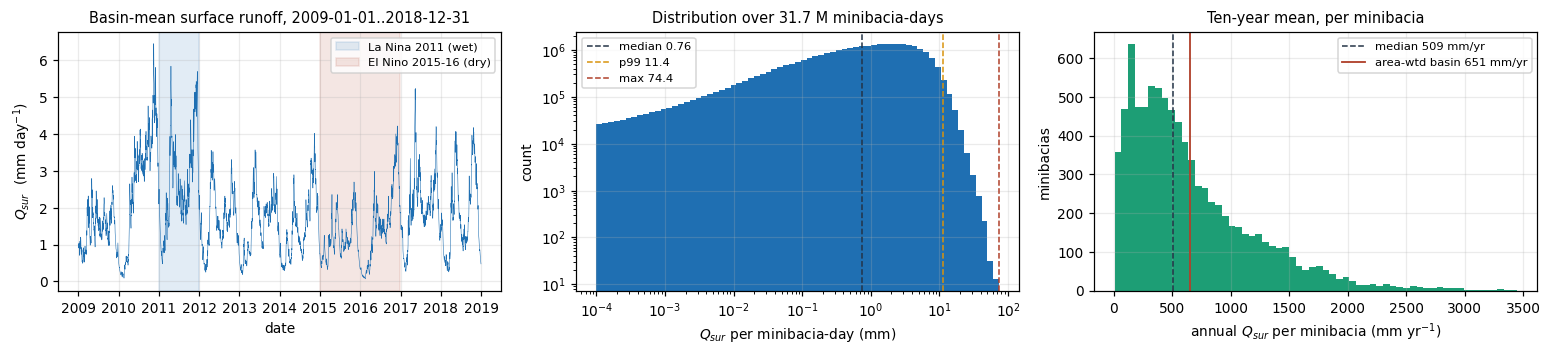

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14.2, 3.3))
ax[0].plot(DATES, q_basin_day, lw=0.35, color=CB['blue'])
ax[0].set_ylabel('$Q_{sur}$  (mm day$^{-1}$)'); ax[0].set_xlabel('date')
ax[0].set_title(f'Basin-mean surface runoff, {DATES[0].date()}..{DATES[-1].date()}')
ax[0].axvspan(pd.Timestamp('2011-01-01'), pd.Timestamp('2011-12-31'),
              color=CB['blue'], alpha=0.13, label='La Nina 2011 (wet)')
ax[0].axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2016-12-31'),
              color=CB['red'], alpha=0.13, label='El Nino 2015-16 (dry)')
ax[0].legend(fontsize=7.5, loc='upper right')

flat = Q.ravel()
bins = np.logspace(-4, np.log10(flat.max()), 70)
ax[1].hist(flat[flat > 0], bins=bins, color=CB['blue'])
ax[1].set_xscale('log'); ax[1].set_yscale('log')
for v, c, lab in [(qs['median'], CB['dark'], f'median {qs["median"]:.2f}'),
                  (qs['p99'], CB['amber'], f'p99 {qs["p99"]:.1f}'),
                  (qs['max'], CB['red'], f'max {qs["max"]:.1f}')]:
    ax[1].axvline(v, color=c, ls='--', lw=1.0, label=lab)
ax[1].set_xlabel('$Q_{sur}$ per minibacia-day (mm)'); ax[1].set_ylabel('count')
ax[1].set_title('Distribution over 31.7 M minibacia-days'); ax[1].legend(fontsize=7.5)

ax[2].hist(ann_mb, bins=60, color=CB['green'])
ax[2].axvline(np.median(ann_mb), color=CB['dark'], ls='--', lw=1.0,
              label=f'median {np.median(ann_mb):.0f} mm/yr')
ax[2].axvline(Q_BASIN_MM_YR, color=CB['red'], ls='-', lw=1.2,
              label=f'area-wtd basin {Q_BASIN_MM_YR:.0f} mm/yr')
ax[2].set_xlabel('annual $Q_{sur}$ per minibacia (mm yr$^{-1}$)'); ax[2].set_ylabel('minibacias')
ax[2].set_title('Ten-year mean, per minibacia'); ax[2].legend(fontsize=7.5)
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** Three panels of the frozen surface-runoff field. **Left:** the area-weighted basin
mean $Q_{sur}$, mm day$^{-1}$, for every one of the 3,652 days; the blue band is the La Nina 2011
wet window and the red band the El Nino 2015-16 dry window, both as pre-registered elsewhere in
this project. **Middle:** the distribution of all 31.7 million individual minibacia-days on
log-log axes (zeros omitted, since a log axis cannot show them); dashed lines mark the median,
the 99th percentile and the maximum. **Right:** each minibacia's ten-year mean annual runoff in
mm yr$^{-1}$; the dashed line is the median minibacia and the solid red line the area-weighted
basin value.

**What it shows.** Per minibacia-day the median is 0.755 mm and the maximum 74.392 mm - a
distribution spanning two orders of magnitude with a long right tail, which is what the middle
panel's log axes are for. There are no non-finite and no negative values. Across space the
ten-year mean spans p05 74 to p95 1,724 mm yr$^{-1}$ (median 509), and the area-weighted basin
figure is 651.1 mm yr$^{-1}$ over 257,097 km<sup>2</sup>, i.e. **167.4 km<sup>3</sup> of surface
runoff per year**. In time, the left panel shows the bimodal Magdalena regime (two rainy seasons
per year, not one) with a visibly higher, spikier 2010-11 and a visibly suppressed 2015-16.

**What it means.** This is the *only* driver of the sediment model, so its properties propagate
directly. Three of them matter. (1) The spatial range is a factor of 23 between the 5th and 95th
percentile minibacia, so erosion will be strongly spatially concentrated before topography is
even applied. (2) The temporal distribution is heavy-tailed, and MUSLE's exponent
$2\beta = 1.12$ is greater than one, so the largest days count more than proportionally - this is
why the flood-peak deficit of section 4.5 is a first-order problem and not a detail. (3) The wet
and dry windows are visibly different in the driver itself, which is a necessary condition for
the ENSO contrast of section 8 to be anything at all - though not a sufficient one.

## 2.2 - $K$: soil erodibility, from the Colombian national soil survey

**What the cell computes.** It loads the erodibility column and reports it in *both* numeric unit
systems, because which of the two is correct is one half of the error section 5 fixes.

$$K_{US} \;=\; \frac{K_{SI}}{0.1317}, \qquad K_{SI}\;=\;\texttt{minibacia\_soil\_params.csv:K}$$

where $K_{SI}$ is erodibility in SI USLE units, t ha h ha$^{-1}$ MJ$^{-1}$ mm$^{-1}$ - the mass
of soil lost per unit of rainfall erosive energy, on the standard reference plot - and $K_{US}$
is the same physical quantity in the older US-customary numerics, t ac h (100 ac ft tonf
in)$^{-1}$. One value per minibacia (8,672 values), broadcast to every URH cell inside it.

**Where the numbers came from, and why the conversion constant is not a literature value.**
Notebook 09 §4 of this project built $K$ from soil *texture* families in the IGAC (Colombian
geographic institute) soil map, by taking mid-range Wischmeier & Smith (1978) class values -
coarse 0.020, medium 0.045, fine 0.028 - and multiplying by a drainage adjustment. Critically,
that notebook states in as many words that it **converted them to SI by multiplying by 0.1317**.
So 0.1317 is this repository's *own* transform, and undoing it exactly is the correct inverse
rather than an independent estimate. The cell below undoes it and checks that the textbook
numbers come back.

**Rejected alternative: making $K$ per URH rather than per minibacia.** The URH code's first
digit *is* a soil family, so a per-URH $K$ could be derived from it. Rejected because
`minibacia_soil_params.csv` already encodes the same texture information, resolved on the
national soil map rather than on the coarser reclassification, and two derivations of one
quantity can disagree. One source of truth per factor.

In [5]:
SP = pd.read_csv(PROC / 'minibacia_soil_params.csv')
K_SI = SP.set_index('id').loc[DRV.mini_ids, 'K'].to_numpy(float)
K_US = K_SI / sed.K_SI_PER_K_US
print(f'K_SI_PER_K_US = {sed.K_SI_PER_K_US}   (nb09 §4\'s own stated transform)')
print(f'K_US_PER_K_SI = {sed.K_US_PER_K_SI!r}   <- one of the two factors of section 5\n')
print(f'K stored (SI)          n {K_SI.size}  min {K_SI.min():.4f}  median '
      f'{np.median(K_SI):.5f}  max {K_SI.max():.4f}  area-wtd '
      f'{np.average(K_SI, weights=A_MB):.6f}   NaN {int(np.isnan(K_SI).sum())}')
print(f'K in US-customary numerics  min {K_US.min():.4f}  median {np.median(K_US):.4f}  '
      f'max {K_US.max():.4f}  area-wtd {np.average(K_US, weights=A_MB):.4f}')
print('\nundoing nb09 §4\'s transform returns the textbook class values it was built from:')
for si, name, book in [(0.020, 'Coarse / sand', 0.15), (0.045, 'Medium / silt loam', 0.34),
                       (0.028, 'Fine / clay', 0.21)]:
    print(f'  {name:22s} stored SI {si:.3f}  ->  US {si/sed.K_SI_PER_K_US:.4f}   '
          f'Wischmeier & Smith (1978) mid-range {book:.2f}')
print('\nSWAT, the reference implementation of this same equation, documents USLE_K with typical')
print('values 0.1-0.65 - i.e. the US-customary NUMBERS. The stored 0.019-0.0495 is an order of')
print('magnitude below that range, which is the fingerprint of an SI table, not of a bad soil map.')

K_SI_PER_K_US = 0.1317   (nb09 §4's own stated transform)
K_US_PER_K_SI = 7.59301442672741   <- one of the two factors of section 5

K stored (SI)          n 8672  min 0.0190  median 0.03055  max 0.0495  area-wtd 0.031765   NaN 0
K in US-customary numerics  min 0.1443  median 0.2320  max 0.3759  area-wtd 0.2412

undoing nb09 §4's transform returns the textbook class values it was built from:
  Coarse / sand          stored SI 0.020  ->  US 0.1519   Wischmeier & Smith (1978) mid-range 0.15
  Medium / silt loam     stored SI 0.045  ->  US 0.3417   Wischmeier & Smith (1978) mid-range 0.34
  Fine / clay            stored SI 0.028  ->  US 0.2126   Wischmeier & Smith (1978) mid-range 0.21

SWAT, the reference implementation of this same equation, documents USLE_K with typical
values 0.1-0.65 - i.e. the US-customary NUMBERS. The stored 0.019-0.0495 is an order of
magnitude below that range, which is the fingerprint of an SI table, not of a bad soil map.


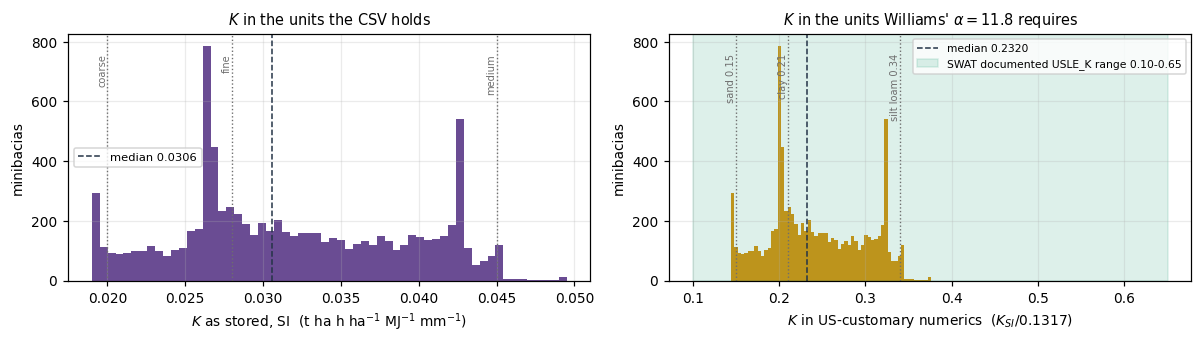

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.0, 3.2))
ax[0].hist(K_SI, bins=60, color=CB['purple'])
ax[0].axvline(np.median(K_SI), color=CB['dark'], ls='--', lw=1.0,
              label=f'median {np.median(K_SI):.4f}')
for v, name in [(0.020, 'coarse'), (0.045, 'medium'), (0.028, 'fine')]:
    ax[0].axvline(v, color=CB['grey'], ls=':', lw=0.9)
    ax[0].text(v, ax[0].get_ylim()[1]*0.92, name, rotation=90, fontsize=6.5,
               ha='right', va='top', color=CB['grey'])
ax[0].set_xlabel('$K$ as stored, SI  (t ha h ha$^{-1}$ MJ$^{-1}$ mm$^{-1}$)')
ax[0].set_ylabel('minibacias'); ax[0].legend(fontsize=7.5)
ax[0].set_title('$K$ in the units the CSV holds')

ax[1].hist(K_US, bins=60, color=CB['amber'])
ax[1].axvline(np.median(K_US), color=CB['dark'], ls='--', lw=1.0,
              label=f'median {np.median(K_US):.4f}')
ax[1].axvspan(0.10, 0.65, color=CB['green'], alpha=0.15,
              label='SWAT documented USLE_K range 0.10-0.65')
for v, name in [(0.15, 'sand 0.15'), (0.34, 'silt loam 0.34'), (0.21, 'clay 0.21')]:
    ax[1].axvline(v, color=CB['grey'], ls=':', lw=0.9)
    ax[1].text(v, ax[1].get_ylim()[1]*0.92, name, rotation=90, fontsize=6.5,
               ha='right', va='top', color=CB['grey'])
ax[1].set_xlabel('$K$ in US-customary numerics  ($K_{SI}/0.1317$)')
ax[1].set_ylabel('minibacias'); ax[1].legend(fontsize=7.0, loc='upper right')
ax[1].set_title('$K$ in the units Williams\' $\\alpha=11.8$ requires')
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** The same 8,672 erodibility values twice. **Left:** as stored in
`minibacia_soil_params.csv`, in SI USLE units; dotted grey lines mark the three Wischmeier &
Smith texture-class values notebook 09 says it started from, after SI conversion. **Right:** the
identical data divided by 0.1317, i.e. in US-customary numerics; the green band is the range
SWAT's documentation gives for this input, and the dotted lines are the textbook class values in
their original units. Dashed dark line is the median in each panel.

**What it shows.** Stored, $K$ spans 0.0190-0.0495 with median 0.03055 and area-weighted mean
0.031765. Divided by 0.1317 it spans 0.1443-0.3759 with median 0.2320. The three stored class
values map back onto the textbook numbers almost exactly: 0.020 to 0.1519 against sand 0.15,
0.045 to 0.3417 against silt loam 0.34, 0.028 to 0.2126 against clay 0.21. In the left panel the
whole distribution sits an order of magnitude below SWAT's documented input range; in the right
panel it sits inside it.

**What it means.** This **identifies** rather than infers the unit system: the stored column is SI,
and the recovery of three textbook values to two decimal places is not something a coincidence
produces. That matters because Williams' $\alpha = 11.8$ is paired with US-customary $K$, so
feeding the stored SI values into MUSLE with $\alpha = 11.8$ understates erosion by exactly
$1/0.1317 = 7.593$ - the second and larger of the two factors in section 5's waterfall. It also
sets the size of the residual imprecision, stated rather than hidden: the SI table is rounded to
three decimals, so the recovered US numerics carry up to about 1.3 % of rounding residue. The
figure is the audit; the fix is a named, reversible option on the engine, not an edit to the
CSV.

## 2.3 - $C$ and $P$: cover and support practice

**What the cell computes.** It loads the cover/practice table and reports both the revision the
model now uses and the one it used a day earlier, plus each class's cited low/central/high range.
The only arithmetic is a basin area weighting:

$$\bar C \;=\; \frac{\sum_{c} A_c\,C_{\ell(c)}}{\sum_c A_c}$$

where $c$ runs over the 32,782 (minibacia, URH) cells, $A_c$ is the cell area in km<sup>2</sup>
from `urh_fractions.csv` x `minibacias.csv`, and $\ell(c)$ is the cell's land class (1 Forest to
8 Wetland). $C$ and $P$ are dimensionless and bounded in $[0,1]$; $\bar C$ is dimensionless.

**What $C$ means physically.** $C$ is the ratio of soil loss under the actual cover to soil loss
from the same soil and slope kept **bare and freshly tilled**. So $C=1$ means "as erodible as bare
ground" and $C=0.005$ means "the vegetation removes 99.5 % of the loss". It is the factor that
carries land cover into the equation, and it spans three orders of magnitude across cover types,
which makes it the most leveraged input in the table.

**What $P$ means, and why it is 1.0 everywhere.** $P$ is defined - in USLE's founding handbook -
for **support practices**: contour ploughing, strip cropping, terracing, i.e. deliberate
engineering that changes the flow path. No practice layer exists for this basin. $P=1.0$ is
therefore the explicit statement "no support practice is represented", and since $P\le 1$ it is an
*upper bound* on the erosion $P$ permits. **Rejected alternative:** a published Colombian table
that keys $P$ to *land use* rather than to practice. It is reachable by name as a diagnostic and
was rejected as a category error - land use is already carried by $C$, so keying $P$ to it
double-counts the same effect. Its measured cost is x0.542, i.e. adopting it would *lower* the
model and widen the gap of section 6, which is worth stating precisely because it means the
rejection was not the convenient direction.

In [7]:
CP = pd.read_csv(PROC / 'urh_cp_factors.csv')
cols = ['class_id', 'class_name', 'value_prior_2026_08_11', 'C', 'C_low', 'C_high',
        'P', 'area_pct', 'erosion_share_pct_at_prior_C']
print('urh_cp_factors.csv - the C/P table, as loaded (not paraphrased)')
print(CP[cols].rename(columns={'value_prior_2026_08_11': 'C_prior', 'C': 'C_cited',
                               'erosion_share_pct_at_prior_C': 'ero%_priorC'}
                      ).to_string(index=False))
print(f'\nthe file also carries per-row provenance columns: '
      f'{[c for c in CP.columns if c in ("land_condition", "source", "note")]}')
print('  -> a C value in this project cannot be quoted without its stated land condition.')

print('\nNAMED, REVERSIBLE C/P revisions on the engine (a level change must be argued, not edited):')
for name, (c_col, p_col) in sed.CP_REVISIONS.items():
    tag = '  <- DEFAULT' if name == sed.DEFAULT_CP_REVISION else ''
    print(f'  {name:32s} reads C={c_col!r:26s} P={p_col!r}{tag}')

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    GEO = sed.load_geometry(PROC, mini_ids=DRV.mini_ids)                     # adopted C
    GEO_PRIOR = sed.load_geometry(PROC, mini_ids=DRV.mini_ids,
                                  cp_revision='prior_2026_08_11')            # previous C
WARN_TEXT = sorted({str(w.message) for w in caught})
print(f'\ngeometry: {GEO.n_mini} minibacias, {GEO.n_cells} URH cells, '
      f'covered area {GEO.covered_area_km2:,.2f} km2')
print(f'  audit trail travelling with the load: '
      f'{ {k: GEO.audit[k] for k in ("cp_revision", "cp_c_column", "cp_p_column") if k in GEO.audit} }')
A_CELL = GEO.cell_area_km2
LAND = GEO.cell_land_class()
C_BAR = float(np.average(GEO.cell_c, weights=A_CELL))
C_BAR_PRIOR = float(np.average(GEO_PRIOR.cell_c, weights=A_CELL))
print(f'  area-weighted basin C:  prior {C_BAR_PRIOR:.6f}   adopted {C_BAR:.6f}   '
      f'ratio {C_BAR/C_BAR_PRIOR:.5f}')
print(f'\n{len(WARN_TEXT)} loader warning(s) raised - PRINTED, not suppressed (see section 7.5):')
for w in WARN_TEXT:
    print('  !', w)

urh_cp_factors.csv - the C/P table, as loaded (not paraphrased)
 class_id class_name  C_prior  C_cited  C_low  C_high   P  area_pct  ero%_priorC
        1     Forest    0.003    0.005  0.001   0.037 1.0 55.774448      36.4836
        2      Shrub    0.005    0.015  0.003   0.100 1.0  0.118724       0.0582
        3  Grassland    0.010    0.015  0.008   0.100 1.0 39.866682      27.3262
        4   Cropland    0.200    0.200  0.080   0.495 1.0  1.574933       0.4728
        5      Urban    0.010    0.030  0.000   0.200 1.0  0.297055       0.0594
        6       Bare    1.000    0.500  0.250   1.000 1.0  0.196257      35.5983
        7      Water    0.000    0.000  0.000   0.001 1.0  0.648751       0.0000
        8    Wetland    0.001    0.005  0.001   0.010 1.0  1.523149       0.0015

the file also carries per-row provenance columns: ['land_condition', 'source', 'note']
  -> a C value in this project cannot be quoted without its stated land condition.

NAMED, REVERSIBLE C/P revisions on 


geometry: 8672 minibacias, 32782 URH cells, covered area 257,096.93 km2
  audit trail travelling with the load: {'cp_revision': 'cited_central_2026_08_11', 'cp_c_column': 'C', 'cp_p_column': 'P'}
  area-weighted basin C:  prior 0.010823   adopted 0.013083   ratio 1.20879

1 loader warning(s) raised - PRINTED, not suppressed (see section 7.5):
  ! URH cell areas from urh_fractions.csv x minibacias.csv and from urh_ls2d.csv:area_km2 differ by more than 5% on 12.9% of cells (median ratio 1.0021, max 6.60; basin totals 257097 vs 251724 km2). This module uses the urh_fractions.csv area, i.e. the same area the frozen water balance used, and treats LS2D as an intensive per-cell mean.


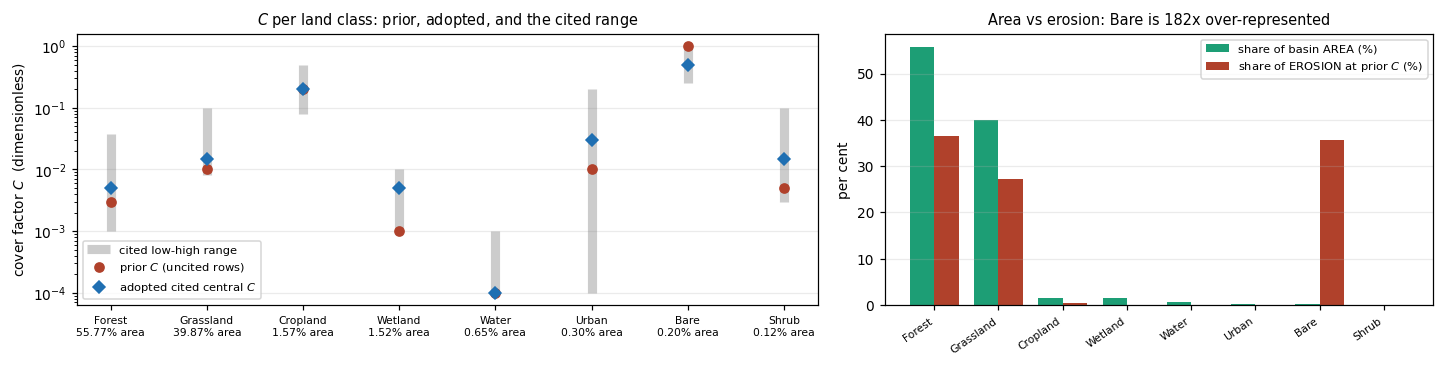

In [8]:
order = CP.sort_values('area_pct', ascending=False)
x = np.arange(len(order))
fig, ax = plt.subplots(1, 2, figsize=(13.2, 3.4),
                       gridspec_kw={'width_ratios': [1.35, 1.0]})
lo = order.C_low.to_numpy(); hi = order.C_high.to_numpy()
ce = order.C.to_numpy(); pr = order.value_prior_2026_08_11.to_numpy()
ax[0].vlines(x, np.maximum(lo, 1e-4), hi, color=CB['grey'], lw=6, alpha=0.35,
             label='cited low-high range')
ax[0].plot(x, np.maximum(pr, 1e-4), 'o', ms=6, color=CB['red'], label='prior $C$ (uncited rows)')
ax[0].plot(x, np.maximum(ce, 1e-4), 'D', ms=6, color=CB['blue'], label='adopted cited central $C$')
ax[0].set_yscale('log')
ax[0].set_xticks(x)
ax[0].set_xticklabels([f'{n}\n{a:.2f}% area' for n, a in
                       zip(order.class_name, order.area_pct)], fontsize=7)
ax[0].set_ylabel('cover factor $C$  (dimensionless)')
ax[0].set_title('$C$ per land class: prior, adopted, and the cited range')
ax[0].legend(fontsize=7.5, loc='lower left')

w = 0.38
ax[1].bar(x - w/2, order.area_pct, w, color=CB['green'], label='share of basin AREA (%)')
ax[1].bar(x + w/2, order.erosion_share_pct_at_prior_C, w, color=CB['red'],
          label='share of EROSION at prior $C$ (%)')
ax[1].set_xticks(x); ax[1].set_xticklabels(order.class_name, fontsize=7, rotation=35, ha='right')
ax[1].set_ylabel('per cent'); ax[1].set_title('Area vs erosion: Bare is 182x over-represented')
ax[1].legend(fontsize=7.5)
for a in ax:
    a.grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the cover factor for each of the eight land classes on a logarithmic
axis. Grey bars are the cited low-to-high range from the evidence review, red circles the value
this project used before that review, blue diamonds the adopted cited central value. Classes are
ordered by their share of basin area, printed under each label. **Right:** for the same classes,
share of basin area (green) against share of the model's gross erosion at the prior $C$ (red),
both in per cent.

**What it shows.** The revision moves three rows up and one row down. Forest 0.003 to 0.005,
Grassland 0.010 to 0.015, Urban 0.010 to 0.030, Shrub 0.005 to 0.015 - and **Bare 1.00 to
0.50**, which is the largest single change in the table and it goes *down*. The net effect on the
area-weighted basin mean is 0.010823 to 0.013083, a factor of **1.2088**. The right panel is the
striking one: Bare is 0.196 % of the basin's area and produced 35.6 % of its erosion at the prior
$C$ - a 182-fold over-representation - while Forest is 55.8 % of area and 36.5 % of erosion.
Cropland, Urban, Shrub, Water and Wetland together account for under 1 % of erosion.

**What it means.** Three conclusions, one of them a correction of an earlier expectation. (1) The $C$
revision is worth about x1.20 on the basin total, **not** the x2-5 that this project's own closure
document estimated for it - because the biggest single correction lowers the model. An estimate
made before measurement was wrong by roughly a factor of two, and in the flattering direction.
(2) The model's erosion is dominated by three classes (Forest, Grassland, Bare) and the other
five are irrelevant at basin scale - which means only those three could ever be constrained by
data, and section 7.2 shows even that is limited. (3) The Bare row is the live input problem: at
$C=1.0$ the model was treating rock, ash and ice above the treeline as freshly tilled farmland.
Halving it is an improvement with a written reason, but the adopted 0.50 is an explicit
*interpolation* between two cited endpoints, $\sqrt{0.25\times1.00}$, not a value read from any
table - so it is cited at the ends and invented in the middle, and must be reported that way.

## 2.4 - The provenance ledger: which factors are measured, which are assumed, which are
to be fitted

**What the cell computes.** No new arithmetic. It assembles the eight factors into one table with
each one's class, current value or range, and the file it comes from, then prints the engine's own
convention summary - the object that must travel in the same table as any reported load, because
after section 5 a load is 363x ambiguous without it.

In [9]:
PAR = sed.SedParams()                     # every default is the adopted, named choice
CS = PAR.convention_summary()
led = [
    ('alpha', 'ASSUMED -> to be FITTED (C4)', f'{PAR.alpha}',
     'Williams (1975), adopted unchanged by the source method'),
    ('beta', 'ASSUMED -> to be FITTED (C4)', f'{PAR.beta}', 'Williams (1975)'),
    ('Qsur', 'DATA (frozen)', f'{Q_BASIN_MM_YR:,.0f} mm/yr basin',
     'sim_calibrated_v2/h2e_drivers.npz:qsur_rel_mm'),
    ('q_peak', 'PROXY (registered, section 4)', 'Qsur*a_p/86.4',
     'derived from Qsur; source method eq. 7'),
    ('A (unit)', 'REGISTERED SCALE', f'a_p = {PAR.pixel_area_km2} km2',
     'COP90 pixel; areas from urh_fractions x minibacias'),
    ('K', 'DATA', f'{K_SI.min():.3f}-{K_SI.max():.4f} SI',
     'minibacia_soil_params.csv:K (IGAC texture, nb09 §4)'),
    ('C', 'CITED, conditioned and ranged', f'basin mean {C_BAR:.6f}',
     'urh_cp_factors.csv (C/P revision, 8 rows sourced)'),
    ('P', 'ASSUMED, one-sided (P<=1)', '1.0 basin-wide',
     'no practice layer exists for this basin'),
    ('LS2D', 'DERIVED from DEM; LEVEL UNVALIDATED', 'section 3',
     'urh_ls2d.csv:ls2d_hs'),
    ('FG', 'ASSUMED, one-sided (FG<=1)', f'{PAR.fg}',
     'no rock-fragment layer exists (IGAC gives texture only)'),
]
print(f'{"factor":10s} {"class":32s} {"value":26s} source')
print('-' * 118)
for row in led:
    print(f'{row[0]:10s} {row[1]:32s} {row[2]:26s} {row[3]}')

print('\nSedParams.convention_summary() - this must be printed beside ANY reported load:')
for k, v in CS.items():
    print(f'  {k:26s} {v}')
print('\npre-registered parameter guard applied to the STARTING values:')
chk = PAR.check()
print(f'  status {chk["status"]!r}   reasons {chk["reasons"]}')
print(f'  alpha band expected {chk["alpha_band"]["expected"]}, hard stops '
      f'{chk["alpha_band"]["stop_low"]:.3f} / {chk["alpha_band"]["stop_high"]:.1f}, '
      f'reference {chk["alpha_band"]["reference"]}')
print(f'  beta band {chk["beta_band"]}, scale factor {chk["scale_factor"]}')

factor     class                            value                      source
----------------------------------------------------------------------------------------------------------------------
alpha      ASSUMED -> to be FITTED (C4)     11.8                       Williams (1975), adopted unchanged by the source method
beta       ASSUMED -> to be FITTED (C4)     0.56                       Williams (1975)
Qsur       DATA (frozen)                    651 mm/yr basin            sim_calibrated_v2/h2e_drivers.npz:qsur_rel_mm
q_peak     PROXY (registered, section 4)    Qsur*a_p/86.4              derived from Qsur; source method eq. 7
A (unit)   REGISTERED SCALE                 a_p = 0.0081 km2           COP90 pixel; areas from urh_fractions x minibacias
K          DATA                             0.019-0.0495 SI            minibacia_soil_params.csv:K (IGAC texture, nb09 §4)
C          CITED, conditioned and ranged    basin mean 0.013083        urh_cp_factors.csv (C/P revision, 8 rows sourc

## 3 - $LS$: topography, from first principles

### 3.1 What slope length and steepness do to erosion, and what the factor is relative to

Two properties of a hillside control how much water erosion it suffers.

**Steepness.** Steeper ground means faster overland flow, and the ability of flowing water to
detach and carry particles rises steeply - faster than linearly - with velocity. Doubling the
gradient does considerably more than double the loss.

**Slope length.** The *longer* the uninterrupted slope above a point, the more water has already
accumulated by the time it arrives, so flow at the bottom of a long slope is deeper, faster and
more erosive than at the bottom of a short one. Length matters not because of the distance itself
but because distance is a proxy for accumulated discharge.

USLE bundles both into one dimensionless multiplier, $LS$, and - this is the part that is usually
skipped - $LS$ is **relative to a specific physical reference**: the USLE **unit plot**, a bare,
fallow, up-and-down-ploughed plot **22.13 m long on a 9 % slope**. $LS=1$ means "this ground
erodes exactly as much as that reference plot"; $LS=40$ means forty times as much. Every number in
this section is a ratio to a 22-metre plot in the American Midwest, which is worth remembering
when the values reach the thousands.

### 3.2 Why a raster forces a different formulation: the 2-D unit contributing area

The classical USLE $L$ factor needs a *slope length*, and on a grid of DEM cells there is no such
thing - a cell has no start and no end. Desmet & Govers (1996) resolved this by replacing slope
length with the **unit contributing area**: the upslope area draining through the cell, divided by
the width of the contour it crosses. That is a length, it is what a flow-accumulation grid gives
directly, and it is the sense in which this factor is "2-D". Hence the name `LS2D`.

The formula this project evaluates, per 90 m DEM cell:

$$LS \;=\; (m+1)\left(\frac{A_{unit}}{22.13}\right)^{m}\left(\frac{\sin\theta}{0.0896}\right)^{n}$$

$$A_{unit} \;=\; \frac{A_{in}+D^{2}}{D}\ \ [\mathrm{m}], \qquad
m \;=\; \frac{\beta_r}{1+\beta_r},\qquad
\beta_r \;=\; \frac{\sin\theta/0.0896}{3\sin^{0.8}\theta+0.56}, \qquad n = 1.3$$

| symbol | meaning | units |
|---|---|---|
| $A_{in}$ | upslope area draining *into* the cell (flow accumulation) | m<sup>2</sup> |
| $D$ | cell size, 90 m for the Copernicus GLO-90 DEM | m |
| $A_{unit}$ | unit contributing area = total upslope area per unit contour width | m |
| $22.13$ | the USLE unit-plot **length** (Wischmeier & Smith 1978) | m |
| $\theta$ | local slope angle, from a Horn 3x3 gradient on the DEM | rad |
| $0.0896$ | $\sin$ of the unit plot's 9 % slope, i.e. $\sin(5.143^\circ)$ | - |
| $m$ | length exponent, **slope-dependent** (McCool et al. 1989) | - |
| $\beta_r$ | rill-to-interrill erosion ratio for a moderately rill-prone soil | - |
| $n$ | slope exponent, 1.3 for rill-dominated overland flow (Moore & Burch 1986) | - |

Both exponents are **stated conventions with citations, not tuned numbers**, and this is worth
being explicit about because they are the two places a modeller could quietly buy a factor of
several. $m$ is *not* a constant: McCool's form makes it grow from about 0 on flats to about 0.5
on steep Andean slopes, which is the physical statement that length matters more where rills
form. $n=1.3$ is the upper end of Moore & Burch's 1.0-1.3, chosen because a steep basin with
dominant rill and gully transport is precisely their rill-dominated case. A fixed $m=0.4$
alternative is computed alongside as a cross-check (`ls2d_mb86`) so the reader can see how much of
the answer rides on the slope-dependent $m$ - the answer is: a lot.

**What is *not* re-derived here.** The pit-filled DEM, the D8 flow directions and the flow
accumulation were built in memory by notebook 07 and never written to disk, so `scripts/c3/ls2d.py`
recomputes them from the same source DEM with the same library, reproducing that notebook's cells
exactly. The minibacia partition is **not** re-derived - `minibacias.tif` is read as-is. That
deviation is recorded rather than glossed, because "do not recompute" could not be honoured
literally.

### 3.3 The four variants on disk

**What the cell computes.** It loads both aggregation levels of the topographic factor and reports
area-weighted means, medians and maxima of every variant. The aggregation from cells to a
(minibacia, URH) unit is an **area-weighted arithmetic mean**:

$$\overline{LS}_{u} \;=\; \frac{\sum_{k\in u} a_k\,LS_k}{\sum_{k\in u} a_k}$$

with $k$ the 90 m cells falling in unit $u$ and $a_k$ each cell's true area in
km<sup>2</sup> (which varies with latitude, so it is not a constant). Dimensionless.

**Why the mean and not the median - a derivation, not a preference.** MUSLE is applied per pixel
and the loads are summed. Inside one URH cell every other per-pixel factor is identical, so the
cell's total is $f\sum_k LS_k = f\,n\,\overline{LS}$. The sum of a linear factor over cells is its
**mean** times the count; it is never its median times the count. So the mean is the only
admissible aggregate, and the per-cell median is retained purely as a reproducible diagnostic. It
matters: the median-based alternative is x0.541, i.e. adopting an inadmissible aggregate would
have removed 46 % of the basin's erosion.

In [10]:
ML = pd.read_csv(PROC / 'minibacia_ls2d.csv')
UL = pd.read_csv(PROC / 'urh_ls2d.csv')
print(f'minibacia_ls2d.csv  {len(ML)} rows   columns {list(ML.columns)}')
print(f'urh_ls2d.csv        {len(UL)} rows   columns {list(UL.columns)}')
print(f'  NaN in either file: {int(ML.isna().sum().sum())} / {int(UL.isna().sum().sum())}')

aU = UL.area_km2.to_numpy(float)
aM = ML.area_km2_cells.to_numpy(float)
VAR = [('ls2d', 'primary, UNCAPPED - eq. above, literal'),
       ('ls2d_hs', 'hillslope-limited (upslope area capped at 1 km2) - ADOPTED'),
       ('ls2d_mb86', 'cross-check: FIXED m = 0.4 (Moore & Burch 1986)'),
       ('ls2d_dg96', 'cross-check: literal Desmet & Govers finite-difference L')]
print(f'\n{"variant":11s} {"level":10s} {"area-wtd mean":>14s} {"median":>10s} {"max":>13s}   note')
print('-' * 118)
LSSTAT = {}
for col, note in VAR:
    for lvl, df, wt in (('URH', UL, aU), ('minibacia', ML, aM)):
        v = df[col].to_numpy(float)
        awm = float(np.average(v, weights=wt))
        LSSTAT[(col, lvl)] = dict(awm=awm, med=float(np.median(v)), max=float(v.max()))
        print(f'{col:11s} {lvl:10s} {awm:14.4f} {np.median(v):10.4f} {v.max():13.2f}   '
              f'{note if lvl == "URH" else ""}')
print(f'\nper-minibacia within-unit per-cell MEDIAN (the rejected aggregate): area-wtd '
      f'{np.average(ML.ls2d_median, weights=aM):.4f}, median {np.median(ML.ls2d_median):.4f}')
print(f'  engine factor for that rejected aggregate: x'
      f'{sed.LS2D_AGGREGATION_FACTORS["per_cell_median"]:.4f}  (DIAGNOSTIC ONLY)')
print(f'\ncross-check ratio dg96/primary at the URH level: '
      f'{LSSTAT[("ls2d_dg96","URH")]["awm"]/LSSTAT[("ls2d","URH")]["awm"]:.4f}')
print('  the same ratio measured 0.790 at 90 m and 0.794 at 740 m in the build run '
      '(docs/agents/journal_c31-ls2d.md §S4)')
print('  CAUTION (docs/50, docs/51 §4): this ratio is NOT the L-form lever. It factorises')
print('  exactly as 0.790 = 0.852262 (L form) x 0.926925 (S swap) - the dg96 column uses')
print('  McCool-87 S while the primary uses Moore & Burch - and it is measured on the UNCAPPED')
print('  ls2d column, not the engine\'s ls2d_hs. The L-form ratio is FORMULATION-DEPENDENT:')
print('  0.852262 uncapped / 0.769833 on ls2d_hs / 0.580685 inside the source formulation.')
print('  Use it as a coding cross-check only; the LS bracket of section 3.6 does NOT rest on it.')
print(f'\nadopted column: {GEO.ls2d_column!r}; engine LS factor = '
      f'{PAR.ls2d_factor} (aggregation {PAR.ls2d_aggregation!r} x resolution '
      f'{PAR.ls2d_resolution!r})')

minibacia_ls2d.csv  8672 rows   columns ['id', 'n_cells', 'area_km2_cells', 'ls2d', 'ls2d_hs', 'ls2d_median', 'ls2d_p90', 'ls2d_mb86', 'ls2d_dg96', 'urh_cover_frac']


urh_ls2d.csv        32782 rows   columns ['mini', 'urh', 'n_cells', 'area_km2', 'area_frac', 'ls2d', 'ls2d_hs', 'ls2d_mb86', 'ls2d_dg96']
  NaN in either file: 0 / 0

variant     level       area-wtd mean     median           max   note
----------------------------------------------------------------------------------------------------------------------
ls2d        URH              106.4123    26.2570      76300.20   primary, UNCAPPED - eq. above, literal
ls2d        minibacia        104.9013    47.1334      14146.20   
ls2d_hs     URH               40.5497    19.2857        384.58   hillslope-limited (upslope area capped at 1 km2) - ADOPTED
ls2d_hs     minibacia         39.8123    30.6046        192.33   
ls2d_mb86   URH               16.6756    11.0694        610.77   cross-check: FIXED m = 0.4 (Moore & Burch 1986)
ls2d_mb86   minibacia         16.4355    14.7979        128.65   
ls2d_dg96   URH               84.0037    20.1380      60385.70   cross-check: literal Desmet & Govers fi

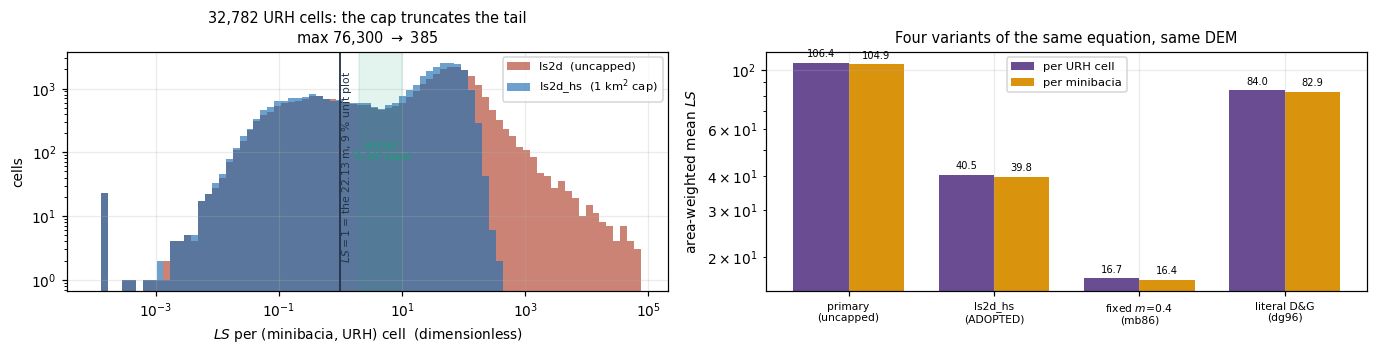

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12.6, 3.3))
b = np.logspace(-4, np.log10(UL.ls2d.max()), 80)
ax[0].hist(UL.ls2d, bins=b, color=CB['red'], alpha=0.65, label='ls2d  (uncapped)')
ax[0].hist(UL.ls2d_hs, bins=b, color=CB['blue'], alpha=0.65, label='ls2d_hs  (1 km$^2$ cap)')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].axvline(1.0, color=CB['dark'], ls='-', lw=1.2)
ax[0].text(1.0, ax[0].get_ylim()[1]*0.5, ' $LS=1$ = the 22.13 m, 9 % unit plot',
           fontsize=7, rotation=90, va='top', color=CB['dark'])
ax[0].axvspan(2, 10, color=CB['green'], alpha=0.12)
ax[0].text(4.5, ax[0].get_ylim()[1]*0.02, 'retired\n"2-10" band', fontsize=6.5,
           ha='center', color=CB['green'])
ax[0].set_xlabel('$LS$ per (minibacia, URH) cell  (dimensionless)')
ax[0].set_ylabel('cells'); ax[0].legend(fontsize=7.5)
ax[0].set_title(f'32,782 URH cells: the cap truncates the tail\n'
                f'max {UL.ls2d.max():,.0f} $\\to$ {UL.ls2d_hs.max():,.0f}')

names = [v[0] for v in VAR]
awm_u = [LSSTAT[(c, 'URH')]['awm'] for c in names]
awm_m = [LSSTAT[(c, 'minibacia')]['awm'] for c in names]
xx = np.arange(len(names)); w = 0.38
ax[1].bar(xx - w/2, awm_u, w, color=CB['purple'], label='per URH cell')
ax[1].bar(xx + w/2, awm_m, w, color=CB['amber'], label='per minibacia')
for i, (u, m_) in enumerate(zip(awm_u, awm_m)):
    ax[1].text(i - w/2, u*1.05, f'{u:.1f}', ha='center', fontsize=6.5)
    ax[1].text(i + w/2, m_*1.05, f'{m_:.1f}', ha='center', fontsize=6.5)
ax[1].set_xticks(xx)
ax[1].set_xticklabels(['primary\n(uncapped)', 'ls2d_hs\n(ADOPTED)', 'fixed $m$=0.4\n(mb86)',
                       'literal D&G\n(dg96)'], fontsize=7)
ax[1].set_ylabel('area-weighted mean $LS$'); ax[1].set_yscale('log')
ax[1].set_title('Four variants of the same equation, same DEM')
ax[1].legend(fontsize=7.5)
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the distribution of the topographic factor over all 32,782
(minibacia, URH) cells, on log-log axes, for the uncapped formula (red) and the
hillslope-limited variant (blue). The vertical line at $LS=1$ marks the USLE unit plot the factor
is relative to; the faint green band is the "2-10 for mountainous terrain" range this project
found in a brief and later **retired as uncited**. **Right:** area-weighted mean $LS$ for the four
computed variants, at both aggregation levels, on a log axis with values printed.

**What it shows.** The cap changes the tail, not the body: the URH-level maximum falls from 76,300 to
385, while the area-weighted mean falls from 106.41 to 40.55 and the median from 26.26 to 19.29.
At the minibacia level the same numbers are 104.90 to 39.81 and 47.13 to 30.60. The two
cross-check variants bracket the primary: a fixed $m=0.4$ gives 16.68 (URH), a factor 6.4 below
the slope-dependent $m$, and the literal Desmet & Govers finite-difference $L$ gives 84.00, i.e.
**0.789 of the primary** - matching the 0.790 measured at 90 m and 0.794 at 740 m in the build
run. **That 0.790 is a coding cross-check and NOT the $L$-form lever**: it factorises exactly as
$0.852262\ (L\ \text{form}) \times 0.926925\ (S\ \text{swap})$, because the `dg96` column also
swaps in McCool-87 $S$, and it is measured on the **uncapped** `ls2d` column rather than the
engine's `ls2d_hs` (`docs/50`, `docs/51` §4). The $L$-form ratio is formulation-dependent -
0.852262 uncapped, **0.769833** on `ls2d_hs`, **0.580685** inside the source formulation - so no
scalar version of it transfers. Almost the entire distribution lies to the right of the retired
2-10 band.

**What it means.** Three things. (1) The implementation is sound: the continuous form and the literal
finite-difference form of the same published equation agree to about 21 % and that agreement is
stable across a factor-of-8 change in resolution, which is the check that catches an
order-of-magnitude coding error. It does not validate the *level*. (2) The slope-dependent $m$ is
the single largest formulation lever in the factor - a factor of 6.4 against a fixed $m$ - so
"which $m$" is not a detail, and section 3.6 shows it is still unresolved. (3) The cap is doing
something structural rather than cosmetic, and the next figure shows what.

### 3.4 THE JUDGEMENT CALL: the uncapped factor ranks water bodies as the most erodible land
in the basin

**What the cell computes.** The equation of section 3.2 has **no upper limit on $A_{unit}$**. On a
mainstem river cell the upslope area is the entire upstream catchment, so
$A_{unit} = A_{in}/D$ reaches millions of metres - i.e. the USLE slope-length relation, fitted on
a 22.13 m plot, is being extrapolated five orders of magnitude. The diagnostic is to rank the 24
URH classes by their area-weighted mean $LS$ and look at which classes come out on top:

$$\overline{LS}_{j} \;=\; \frac{\sum_{u \in j} a_u \overline{LS}_u}{\sum_{u\in j} a_u}
\qquad\text{for each URH class } j = 10\times\text{soil} + \text{land}$$

Dimensionless; $a_u$ in km<sup>2</sup>. Inputs: `urh_ls2d.csv` columns `ls2d` and `ls2d_hs`.

**The fix, and why it is not a tuning.** `ls2d_hs` uses the **identical equation and identical
constants**, with the upslope area capped at a **channel-initiation source area of 1 km<sup>2</sup>**
- the upper end of the humid, steep-terrain field range in Montgomery & Dietrich (1988, 1992).
That is a statement about where channels begin, taken from field measurements of channel heads,
and it stops the extrapolation at the point where the hillslope relation ceases to describe the
process. No exponent, no reference length and no reference slope is touched. **Rejected
alternatives:** (a) clipping the extreme values, rejected because it hides a known
domain-of-validity failure inside the engine rather than naming it; (b) leaving the uncapped
column in production, rejected on the evidence below; (c) excluding water cells, rejected because
the problem is not water *per se* - it is convergence, and it affects any valley-floor cell.

In [12]:
UL2 = UL.copy()
UL2['land'] = UL2.urh % 10
UL2['soil'] = UL2.urh // 10
SOIL = {1: 'Coarse', 2: 'Medium', 3: 'Fine'}
rows = []
for code_, g in UL2.groupby('urh'):
    a = g.area_km2.to_numpy(float)
    rows.append(dict(urh=int(code_),
                     name=f'{SOIL[int(code_)//10]} x {sed.LAND_CLASS_NAMES[int(code_)%10]}',
                     land=int(code_) % 10, area=float(a.sum()),
                     unc=float(np.average(g.ls2d, weights=a)),
                     cap=float(np.average(g.ls2d_hs, weights=a))))
URHT = pd.DataFrame(rows).sort_values('unc', ascending=False).reset_index(drop=True)
print('the 24 URH classes ranked by UNCAPPED area-weighted LS (the diagnostic that condemns it):')
print(URHT[['urh', 'name', 'area', 'unc', 'cap']].head(8).to_string(
    index=False, float_format=lambda v: f'{v:,.2f}'))
top3 = URHT.head(3)
print(f'\n  the top {int((URHT.head(3).land == 7).sum())} of 3 classes are WATER '
      f'(land digit 7): {", ".join(top3.name)}')
wat = UL2[UL2.land == 7]
print(f'  WATER overall: {len(wat)} cells, {wat.area_km2.sum():,.0f} km2, '
      f'uncapped LS {np.average(wat.ls2d, weights=wat.area_km2):,.2f} -> capped '
      f'{np.average(wat.ls2d_hs, weights=wat.area_km2):,.2f} '
      f'(x{np.average(wat.ls2d_hs, weights=wat.area_km2)/np.average(wat.ls2d, weights=wat.area_km2):.4f})')
bare = UL2[UL2.land == 6]
print(f'  BARE  overall: {len(bare)} cells, {bare.area_km2.sum():,.0f} km2, '
      f'uncapped LS {np.average(bare.ls2d, weights=bare.area_km2):,.2f} -> capped '
      f'{np.average(bare.ls2d_hs, weights=bare.area_km2):,.2f} '
      f'(x{np.average(bare.ls2d_hs, weights=bare.area_km2)/np.average(bare.ls2d, weights=bare.area_km2):.4f})')
print(f'\n  per-CELL maximum of the uncapped field over all 30,235,916 basin cells: 3.67e6')
print('    (quoted from the build run, docs/agents/journal_c31-ls2d.md §S4 GATE 1 - the per-cell')
print('     field is not shipped, only its aggregates, so this notebook cannot recompute it)')
print(f'  measured through the engine, the uncapped column multiplies basin erosion by 2.225x')

the 24 URH classes ranked by UNCAPPED area-weighted LS (the diagnostic that condemns it):
 urh            name      area      unc   cap
  27  Medium x Water    536.09 1,837.07 13.72
  37    Fine x Water    715.54 1,053.00  8.69
  17  Coarse x Water    147.27   808.62 12.25
  22  Medium x Shrub     73.49   721.73 43.86
  31   Fine x Forest 60,492.41   147.66 48.34
  26   Medium x Bare    125.97   144.95 61.94
  21 Medium x Forest 55,943.89   133.84 59.04
  11 Coarse x Forest 25,707.30   104.68 58.97

  the top 3 of 3 classes are WATER (land digit 7): Medium x Water, Fine x Water, Coarse x Water
  WATER overall: 1131 cells, 1,399 km2, uncapped LS 1,327.75 -> capped 10.99 (x0.0083)
  BARE  overall: 259 cells, 495 km2, uncapped LS 93.60 -> capped 63.34 (x0.6767)

  per-CELL maximum of the uncapped field over all 30,235,916 basin cells: 3.67e6
    (quoted from the build run, docs/agents/journal_c31-ls2d.md §S4 GATE 1 - the per-cell
     field is not shipped, only its aggregates, so this not

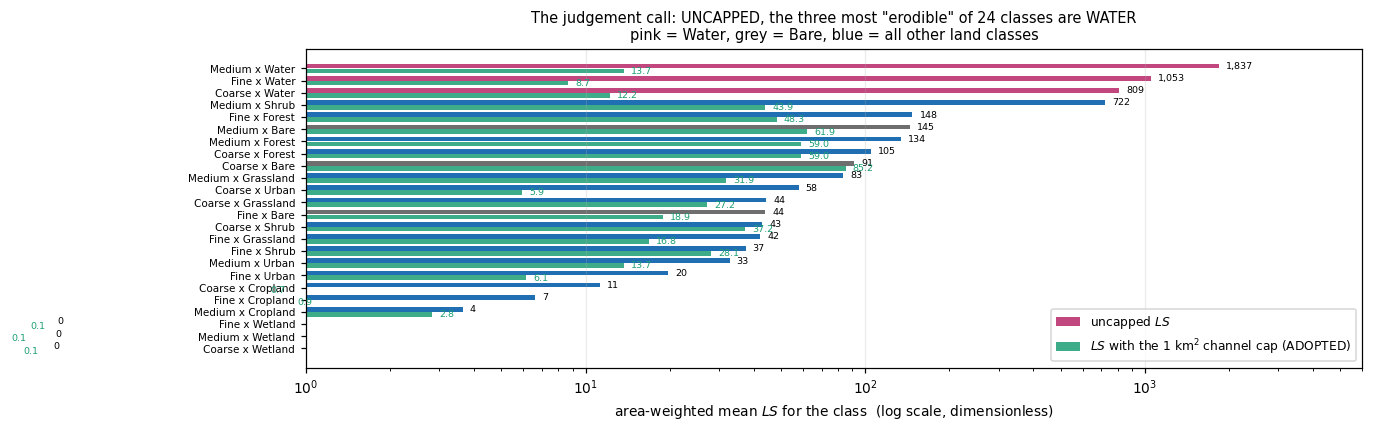

In [13]:
fig, ax = plt.subplots(figsize=(12.6, 4.0))
y = np.arange(len(URHT))[::-1]
colw = [CB['pink'] if l == 7 else (CB['grey'] if l == 6 else CB['blue']) for l in URHT.land]
ax.barh(y + 0.20, URHT.unc, 0.38, color=colw, label='uncapped $LS$')
ax.barh(y - 0.20, URHT.cap, 0.38, color=CB['green'], alpha=0.85,
        label='$LS$ with the 1 km$^2$ channel cap (ADOPTED)')
for yy, u, c in zip(y, URHT.unc, URHT.cap):
    ax.text(u*1.06, yy + 0.20, f'{u:,.0f}', va='center', fontsize=6.2)
    ax.text(c*1.06, yy - 0.20, f'{c:,.1f}', va='center', fontsize=6.2, color=CB['green'])
ax.set_yticks(y); ax.set_yticklabels(URHT.name, fontsize=6.8)
ax.set_xscale('log'); ax.set_xlim(1, 6e3)
ax.set_xlabel('area-weighted mean $LS$ for the class  (log scale, dimensionless)')
ax.set_title('The judgement call: UNCAPPED, the three most "erodible" of 24 classes are WATER\n'
             'pink = Water, grey = Bare, blue = all other land classes')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.25, axis='x')
plt.tight_layout(); plt.show()

**What is plotted.** All 24 soil-x-cover classes, ranked top to bottom by their area-weighted mean
topographic factor computed from the **uncapped** equation (upper bar of each pair, coloured pink
for the three Water classes, grey for Bare, blue for everything else), against the same quantity
with the 1 km<sup>2</sup> channel-initiation cap applied (lower bar, green). Log horizontal axis,
values printed on each bar.

**What it shows.** Uncapped, the top three classes of twenty-four are **Medium x Water (1,837.07),
Fine x Water (1,053.00) and Coarse x Water (808.62)** - all three of them open water. The Water
land class as a whole averages 1,327.75 uncapped and 10.99 capped, a factor of 0.0083. Bare, a
genuine hillslope class, averages 93.60 uncapped and 63.34 capped, a factor of 0.677. At the
per-cell level (quoted from the build log, not recomputable here) the uncapped field reaches
3.67 x 10<sup>6</sup>.

**What it means.** This is the evidence that the uncapped column cannot be used, and it is *not* an
argument about magnitude - it is an argument about **rank order**. An erosion signal that says the
Magdalena river surface is the most erodible land in its own basin, two orders of magnitude more
erodible than bare Andean rock, is not describing erosion. The cause is diagnosable and specific:
on a valley-floor cell $A_{unit}$ is the whole upstream catchment, so a relation fitted on a
22-metre plot is extrapolated five orders of magnitude, and the term $(A_{unit}/22.13)^m$ carries
channel transport into a hillslope equation. The cap discriminates exactly as it should - it
divides the Water classes by 120 and the Bare class by only 1.48 - which is the signature of a fix
that removes the pathology and leaves the physics. The cost is not hidden: the capped column is
2.225x *lower* in basin erosion than the uncapped one, so this judgement call moved the model
away from the outlet anchor it is trying to reach, and it was still the right call.

### 3.5 Resolution sensitivity, and why a published "2-10" range is not a target

**What the cell computes.** It reports the measured resolution dependence of the factor and shows
why comparing it to a published range is not a valid test. The arithmetic is a floor:

$$A_{unit} \;=\; \frac{A_{in}+D^{2}}{D} \;\ge\; D
\qquad\Longrightarrow\qquad
LS_{\min}(D)\;\approx\;(m+1)\left(\frac{D}{22.13}\right)^{m}
\left(\frac{\sin\theta}{0.0896}\right)^{n}$$

because a cell with *no* upslope area still has $A_{in}=0$ and therefore $A_{unit}=D$. Units: $D$
in m, $LS$ dimensionless.

**Read that inequality carefully, because it is the whole argument.** The unit contributing area
can never be smaller than the cell size. So on a coarse grid even a *ridge crest* - a cell with
nothing above it - is assigned a slope length equal to the cell, and gets an $LS$ floor purely from
the grid. At $D = 740$ m that floor is about $(740/22.13)^{0.4}\times1.4 \approx 5.7$; at
$D = 90$ m it is about 2.45. The factor is therefore **resolution-dependent by construction**, and
the dependence has the wrong sign for intuition: a *coarser* DEM gives a *larger* minimum $LS$
while simultaneously smoothing away the real steep gradients.

**The measured numbers** come from running the identical code with identical constants at two
resolutions during the build (`docs/agents/journal_c31-ls2d.md` §S3b and §S4). They are quoted from
that executed output and cannot be recomputed here, because only the aggregates are shipped, not
the per-cell field: **per-cell median 7.508 at 740 m and 12.774 at 90 m, a factor of 1.70 from
resolution alone.**

**Why this retires the comparison rather than failing it.** A brief for this work carried an
expectation that mountainous $LS$ should be "2-10". Our per-cell median is 12.77, which is 1.28x
above the upper bound - so the naive reading is "fails high". But a published $LS$ value is quoted
at whatever DEM resolution that paper used, and this project has just measured that the same
terrain yields 7.51 or 12.77 depending only on that choice. **A range with no stated resolution is
not a resolution-free target, and this repository could find no citation for the 2-10 band at
all.** Under this project's standing rule - an uncited plausibility band may not be used to pass
**or** fail a gate - the comparison is retired in both directions, and the adopted choice is
`native_90m` with **no rescaling** (engine factor exactly 1.000). The rescaling alternative
remains reachable by name as a diagnostic, worth x0.601, so that the rejected option is
reproducible instead of merely asserted.

**The distribution is bimodal, which is a second reason a single basin median is a poor
yardstick.** The basin contains two populations - cordillera and floodplain - and the cell below
shows how few minibacias actually sit inside 2-10.

In [14]:
LS_740_MEDIAN, LS_90_MEDIAN = 7.508, 12.774      # journal_c31-ls2d.md §S3b / §S4, executed
print('RESOLUTION SENSITIVITY - quoted from the build run\'s executed output, not recomputed:')
print(f'  per-cell median LS at 740 m : {LS_740_MEDIAN}')
print(f'  per-cell median LS at  90 m : {LS_90_MEDIAN}   -> x'
      f'{LS_90_MEDIAN/LS_740_MEDIAN:.3f} from resolution alone')
print(f'  A_unit floor at 740 m ~ (740/22.13)^0.4 * 1.4 = '
      f'{(740/22.13)**0.4*1.4:.2f};  at 90 m = {(90/22.13)**0.4*1.4:.2f}')
print(f'  the engine\'s named rescaling diagnostic: x'
      f'{sed.LS2D_RESOLUTION_FACTORS["rescale_740m_ref"]:.4f}  (NOT adopted)')
print(f'  adopted: {PAR.ls2d_resolution!r}, factor '
      f'{sed.LS2D_RESOLUTION_FACTORS[PAR.ls2d_resolution]:.3f}')

med = ML.ls2d_median.to_numpy(float)
inside = int(((med >= 2) & (med <= 10)).sum())
above = int((med > 10).sum()); below = int((med < 2).sum())
print(f'\nwithin-minibacia per-cell median LS across {len(med)} minibacias:')
print(f'  inside the retired 2-10 band: {inside} ({100*inside/len(med):.1f} %)')
print(f'  above 10: {above} ({100*above/len(med):.1f} %)   below 2: {below} '
      f'({100*below/len(med):.1f} %)')
print('  -> bimodal (cordillera vs floodplain); a single basin median describes neither mode')

RESOLUTION SENSITIVITY - quoted from the build run's executed output, not recomputed:
  per-cell median LS at 740 m : 7.508
  per-cell median LS at  90 m : 12.774   -> x1.701 from resolution alone
  A_unit floor at 740 m ~ (740/22.13)^0.4 * 1.4 = 5.70;  at 90 m = 2.45
  the engine's named rescaling diagnostic: x0.6008  (NOT adopted)
  adopted: 'native_90m', factor 1.000

within-minibacia per-cell median LS across 8672 minibacias:
  inside the retired 2-10 band: 889 (10.3 %)
  above 10: 5038 (58.1 %)   below 2: 2745 (31.7 %)
  -> bimodal (cordillera vs floodplain); a single basin median describes neither mode


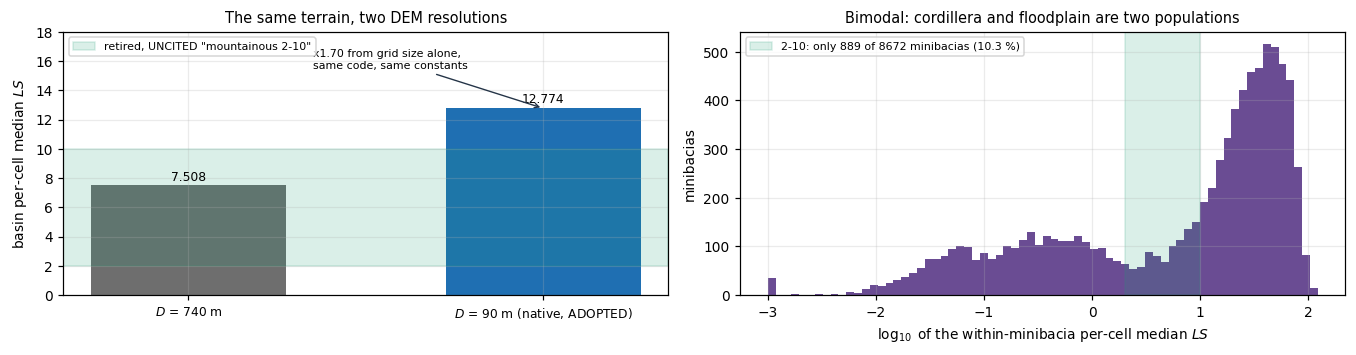

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 3.3))
ax[0].bar([0, 1], [LS_740_MEDIAN, LS_90_MEDIAN], 0.55,
          color=[CB['grey'], CB['blue']])
ax[0].axhspan(2, 10, color=CB['green'], alpha=0.16,
              label='retired, UNCITED "mountainous 2-10"')
for i, v in enumerate([LS_740_MEDIAN, LS_90_MEDIAN]):
    ax[0].text(i, v + 0.35, f'{v:.3f}', ha='center', fontsize=8)
ax[0].annotate(f'x{LS_90_MEDIAN/LS_740_MEDIAN:.2f} from grid size alone,\n'
               'same code, same constants',
               xy=(1, LS_90_MEDIAN), xytext=(0.35, 15.5), fontsize=7.2,
               arrowprops=dict(arrowstyle='->', lw=0.9, color=CB['dark']))
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(['$D$ = 740 m', '$D$ = 90 m (native, ADOPTED)'],
                                               fontsize=8)
ax[0].set_ylabel('basin per-cell median $LS$'); ax[0].set_ylim(0, 18)
ax[0].legend(fontsize=7.2, loc='upper left')
ax[0].set_title('The same terrain, two DEM resolutions')

ax[1].hist(np.log10(np.clip(med, 1e-3, None)), bins=70, color=CB['purple'])
ax[1].axvspan(np.log10(2), np.log10(10), color=CB['green'], alpha=0.16,
              label=f'2-10: only {inside} of {len(med)} minibacias ({100*inside/len(med):.1f} %)')
ax[1].set_xlabel('$\\log_{10}$ of the within-minibacia per-cell median $LS$')
ax[1].set_ylabel('minibacias'); ax[1].legend(fontsize=7.2)
ax[1].set_title('Bimodal: cordillera and floodplain are two populations')
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the basin per-cell median topographic factor computed by the same code with
the same constants at two DEM cell sizes, 740 m and the adopted native 90 m; the green band is the
uncited "2-10 for mountainous terrain" expectation, and the annotation gives the ratio. **Right:**
the distribution, on a base-10 log axis, of each minibacia's own within-unit per-cell median, with
the 2-10 band shaded and the count inside it in the legend.

**What it shows.** Coarsening the grid by a factor of 8 moves the basin median from 12.774 to 7.508,
a factor of **1.70**, with no change to any constant or any line of code. On the adopted 90 m grid
the median lands 1.28x above the band's upper bound; on a 740 m grid it would land comfortably
inside it. The right panel shows the distribution is two-peaked and that only **889 of 8,672
minibacias (10.3 %)** have a median inside 2-10, against 5,038 (58.1 %) above and 2,745 (31.7 %)
below.

**What it means.** The apparent "failure" against 2-10 is a **resolution artefact, not a level error**,
and the band cannot adjudicate the choice in either direction: it is uncited, and the same terrain
passes or fails it depending on a grid size the band never states. So the band is retired and the
native resolution is kept with no correction - deliberately declining a x0.601 rescaling that
would have moved the model *further* from the outlet anchor of section 5 while pretending to be a
physical correction. The right panel makes a second, more important point: a single basin-median
$LS$ is a poor summary of a basin that is 58 % above and 32 % below the band, so any test built on
a basin-mean topographic factor is testing a number that describes neither of the basin's two
populations. **What this does not establish:** that the level is right. It establishes only that
this particular yardstick cannot measure it. The yardstick that can is in section 3.6, and the
model fails it.

### 3.6 The part that is still WRONG, points the wrong way, and is not fixed

This subsection exists because it was **missing from every numbered document in this project until
2026-08-11**, and its omission flattered the result.

MUSLE's coefficient $\alpha = 11.8$ is not a free-floating constant: it is paired with a *specific
$LS$ formulation*. Because MUSLE is **linear in $LS$**, an $LS$ field at a different level than the
one $\alpha$ was fitted with passes that ratio one-for-one into $\alpha$ - so a mismatch here
silently invalidates every parameter guard in section 7.1. This project transposes the MGB-SED
method of Buarque (2015), whose $LS$ differs from ours in **four** ways, all measured on the *same*
90 m grid, i.e. these are formulation differences and not the resolution question section 3.5
settled. **Two columns are given because two weightings exist and only one of them decides**: the
*erosion-weighted* factor $f_{ero}$ is the exact engine re-run and **decides**; the
*area-weighted* factor $f_{area}$ is a **proxy** reported beside it and can never override it
(`docs/46` §3.3):

| lever | ours | the source method | $f_{ero}$ (decides) | $f_{area}$ (proxy) |
|---|---|---|---|---|
| slope-length limiter | upslope **area** $\le$ 1 km<sup>2</sup>, so unit length up to $10^6/92\approx$ **10,870 m** ($\approx$ 118 pixels) | slope length $\le$ **one DEM pixel** (printed pp. 94 **and** 98) | **0.362435** - dominant | 0.3513 |
| $m$ | continuous McCool (1989), basin median 0.584 | **his eq. 14, printed p. 47: a STEP FUNCTION** - $m=0.2$ ($S_f<1$ %), $0.3$ (1-3 %), $0.4$ (3-5 %), $0.5$ ($S_f\ge5$ %), with $S_f$ in slope **percent** | **0.522043** | 0.505092 |
| $S$ | Moore & Burch (1986), $(\sin\theta/0.0896)^{1.3}$ | his eq. 18, p. 48: Wischmeier & Smith (1978), $65.41\sin^2\theta+4.56\sin\theta+0.065$ | **1.694054** | 1.7139 |
| $L$ | continuous **point-rate** form $(m+1)(\lambda/22.13)^m$ | **his eq. 13, p. 47: the Desmet & Govers finite-difference $L$** with $X_{dir}^{\,m}$ | **0.580685** *inside the source formulation* | - |
| **the first three together** (`V4`, a documented **HYBRID**: his three levers with **our** $L$) | area-wtd mean **39.812** | area-wtd mean **16.775** | **0.431944** | ~~0.421475~~ **0.42136300143291305** |
| **all four together** (`V4_dg`, **the source formulation READ WHOLE**) | | | **0.25146** | **0.2446790094097074** |

> **A SUPPORT CORRECTION on the $f_{area}$ column, 2026-08-12.** Owning records: `docs/46` §10
> **amendment 2** and `docs/51` §9 **amendment 1**; expressed exactly as here by `docs/43` §7
> amendment 8. The `V4` proxy read ~~**0.421475**~~ and is **0.42136300143291305**. The struck
> figure is **not an arithmetic error** - it is the same ratio on the **engine URH-fraction** area
> support (32,782 units, 257,096.93 km<sup>2</sup>), whereas `docs/46` §3.3 defines $f_{area}$ on
> the **per-cell basin** (30,235,916 DEM cells at 90 m, 256,702.36 km<sup>2</sup>):
> $16.775413430326214 / 39.812260149274394$. The independent discriminator is `docs/47` §3.1's
> separately measured proxy bias **R7 = 1.0251**, printed to four decimals so its true value lies
> in $[1.02505, 1.02515]$: $0.43194417543884817/0.42136300143291305 = 1.025111777659529$ lies
> **inside** it, while $0.43194417543884817/0.4214751420286394 = 1.0248390293193077$ lies
> **outside**, and the corrected value is **22x closer**. **$f_{ero}$ is untouched**, so the
> registered bracket, the $\alpha$ reference, the hard stop and every basin load below are
> **unmoved**. The lower endpoint **0.2446790094097074 was already on the registered support** and
> is *not* corrected. The channel by which the wrong support entered the corpus - an untagged
> `f_area` console header in `scripts/c3/ls_erosion_weights.py` - has been relabelled
> `f_area_urhfrac` at source.

> **A LABEL CORRECTION, and it is unconditional** (`docs/46` §1.1 Defect A, §2.2, §3.1, §7.3 item 2;
> measured in `docs/49`). Until 2026-08-12 the $m$ row of this table read *"his eq. 14: a step
> function **hard-capped at 0.5**"* with a factor of **0.502**. That conflated two different
> objects. **Buarque's eq. 14 IS the step function above** (printed p. 47, verbatim, *"onde $S_f$
> [%] é a declividade do pixel"*, corroborated p. 48) and its factor is **x0.522043 erosion-weighted
> / x0.505092 area-weighted**. The object actually measured as *"0.502"* was
> $\min(m_{\text{continuous}},\,0.5)$ - a **cap**, **x0.517480 ero / x0.502472 area** - which is
> **nobody's published formulation** and **may never be graded CITED**. The two differ by only
> **x1.008878** erosion-weighted (x1.005212 area), because the terrain below the cap/step crossover
> at $\tan\theta = 0.0893325$ carries **37.86 % of basin AREA but 2.14 % of basin EROSION**. So the
> mislabel was **real as a label and immaterial as a level** - and, crucially, **the published joint
> x0.421 row was ALREADY the step**, proved by its area-weighted counterpart reproducing the
> published number to **15 significant figures** (16.775413430326214). The mislabel therefore
> contaminated the **single-lever label only and never the joint**.

**The levers do NOT multiply out, and the product is NEVER a candidate for the joint.** The exact
erosion-weighted statement is a measured *ratio*: the registered one is
$0.362435\times0.52204\times1.694054 = 0.3205244$ against the measured joint **0.431944**, i.e.
**joint / product = x1.34762** (`docs/46` §1, `docs/52` §1.1). *(Carrying the `m` step to its sixth
decimal, $0.362435\times0.522043\times1.694054 = 0.3205263$ and the ratio is **x1.347609** - the
same measurement at a different printed precision, not a second number. Both round to x1.3476; the
cell below prints both so they can never appear to disagree.)* The area-weighted proxies show the
same thing, $0.3513\times0.505092\times1.7139 = 0.304112$ vs ~~0.421475~~ **0.42136300143291305**,
~~**x1.38592**~~ $\rightarrow$ **x1.38555**. *(**Recomputed, not retyped**, 2026-08-12: this ratio is
a **function of** the corrected proxy, so it had to move with it. The product is unchanged at
$0.3513\times0.505092\times1.7139 = 0.30411239291243997$; the ratio is
$0.42136300143291305 / 0.30411239291243997 = 1.3855502480434327 \rightarrow$ **x1.38555**, where the
struck **x1.38592** was $0.421475 / 0.30411239291243997 = 1.3859185282243696$. `docs/46` §10
amendment 2 / `docs/51` §9 amendment 1.)* Two
consequences: none of the
levers is "the" cause, and they must be decided **as a set**, never one at a time. *(This notebook
used to print the product as though it were an alternative estimate of the joint. It is not an
estimate of anything - it is the arithmetic that the interaction refutes.)*

**THE REGISTERED BRACKET, and what it actually is.** `f_LS` $\in$ **[0.25146, 0.43194]**
erosion-weighted $\Rightarrow$ **$1/f_{LS}$ = 2.3151x - 3.9768x**: our $LS$ is 2.3151x - 3.9768x the
level $\alpha=11.8$ is paired with. Engine re-runs at the endpoints, not proxies: **129.3840 Mt/yr**
(hybrid) and **75.3235 Mt/yr** (source read whole), against the adopted 299.5387.

> **This bracket is NOT an uncertainty over admissible readings of the source, and that is the
> structural correction** (`docs/46` §1.0, §2.5.1; `docs/50`; `docs/51` §2; enacted `docs/37` A3).
> All four levers are **CITED** and each has a **single** admissible reading, so:
>
> * **the source formulation read whole is a POINT at $f_{LS}$ = x0.25146** ($f_{area}$
>   0.2446790094097074) - `docs/46` §3.1's `V4_dg`, adopted as `ls_formulation =
>   buarque_2015_dg` by `docs/37` **A3**;
> * **x0.43194 is a documented HYBRID** - the source's three levers with **our** $L$ - retained only
>   because it is what was published and it must stay reproducible;
> * **the span between them is the $L$-form lever, exactly**: $\ln(0.43194/0.25146) = 0.5410$. It is
>   a **lever, not an error bar**, and the published *interval* therefore collapses to a **point**.

> **The published x0.790 does NOT isolate the $L$ form, and the superseded x0.333 endpoint rests on
> it** (`docs/50`, `docs/51` §4). It **factorises exactly** as
> **$0.790 = 0.852262\ (L\ \text{form}) \times 0.926925\ (S\ \text{swap})$** - two levers, not one -
> and it was measured on the **wrong column**, the uncapped `ls2d` rather than the engine's
> `ls2d_hs` (`src/mgb_sediment.py`, `ls2d_column="ls2d_hs"`). Worse, **the $L$-form ratio is
> FORMULATION-DEPENDENT** - **0.852262** uncapped, **0.769833** on `ls2d_hs`, **0.580685** *inside
> the source formulation* - and x0.790 composed it across formulations as a scalar. Repairing the
> $S$ confound *completely* still gives $0.421363\times0.769833 = 0.324379$ against the measured
> 0.244679: wrong by **x1.326**. A scalar $L$-form ratio is not a transferable object.

**Two consequences, both unfavourable, both stated in full.**

* **On the level.** At the adopted point the basin total falls to **75.3235 Mt/yr**, and at the
  retained hybrid to **129.3840 Mt/yr** - both *below* both outlet anchors and back on the
  physically awkward side that section 5 claimed to have left behind. Unlike the superseded
  99.8-126.1 Mt/yr, **these are engine re-runs, not the area-weighted proxy**; the proxy is
  measured **2.5 % low** ($f_{ero}/f_{area}$ = ~~1.0248~~ **1.0251** at the hybrid, **1.0277** at the
  adopted point), i.e. it errs *in the model's favour*. *(The hybrid figure moves with the corrected
  $f_{area}$, 2026-08-12: $0.431944/0.42136300143291305 = 1.0251$ - which now matches `docs/47` §3.1's
  independently measured **R7 = 1.0251** exactly, where the struck 1.0248 did not. `docs/46` §10
  amendment 2 lists this cell.)*
* **On the guards.** The like-for-like $\alpha$ reference for **our** $LS$ is
  $11.8\cdot f$ = **2.967 - 5.097, not 11.8**; the pre-registered expected band $5.9\!-\!23.6\cdot f$
  becomes **1.484 - 10.194** and the hard stop $\alpha>35.4$ becomes **8.902 - 15.291**. At the
  adopted point these collapse to the single numbers **2.9672** and **8.9017**. So the adopted,
  *unfitted* $\alpha = 11.8$ sits **above** its own corrected hard stop at the adopted point.
  **This tightens the guard; it does not loosen it.** *(Ceiling on all of it, carried and not
  softened: this is **bookkeeping about the PAIRING of $\alpha$ with an $LS$**, not about $\alpha$.
  It passes and fails nothing. And $\alpha=11.8$ (Williams 1975) predates every 2-D
  contributing-area $LS$ by two decades - its like-for-likeness is **NOT SETTLED and no band is
  offered for it**.)*

**How this was handled, and why that is the interesting part.** The comparison was
**pre-registered in advance** (`docs/35` §9.3, then `docs/46`, frozen) with the decision rule fixed
*before* the run: fidelity to the transposed method wins by default, a deviation needs its own
written citable justification, a deviation requires the $\alpha$ band to be rescaled by the measured
level ratio, and ties break toward the **lower** $LS$ - because the source's own verdict on his
Andean $LS$ (his p. 121) is that even the pixel-capped version tends to make erosion in steep
terrain *overestimated*, and ours uses a looser limiter than his. The registered expected
consequence - that the answer gets **worse** - was written down in advance for one reason: **an
unattractive total is not evidence against the source formulation.** It landed on 2026-08-12 as
`docs/37` **A3**: outcome **ADOPT-SOURCE**, `ls_formulation = buarque_2015_dg`, formulation choice
graded **CITED** on all four levers.

> **WHAT A3 DID NOT DO, so nothing here is over-read.** The decision is **DETERMINED and RECORDED,
> NOT YET EXERCISABLE**. **No engine default has moved** - this notebook still runs on
> `ls2d_column = 'ls2d_hs'`, i.e. `V0`, with $f_{LS}$ = 1.000, and every number below section 3.6 is
> at that level. The **LS LEVEL remains UNVALIDATED** (`docs/42` G4.2) - *a cited formulation is not
> a validated level, and a fitted one is not either*. **C3 stays OPEN** (clause 2 also needs the
> *shape* decision: settling the level is necessary and not sufficient) and **C4.3 stays BLOCKED**
> (`docs/47`). Switching the default is a separate, separately dated act that is **not draftable**
> until a gated `V4_dg` column exists as a committed product.

In [16]:
# LS FORMULATION LEVEL.  Registered values, all cited in place - this cell RE-DERIVES nothing.
#   f_ero  = exact engine re-run, DECIDES         (docs/46 section 3.3)
#   f_area = area-weighted proxy, reported beside it and never able to override it
# Sources: docs/47 section 4.3 (engine re-runs), docs/49 (eq.-14 step vs cap), docs/50 + docs/51
# section 4 (the L form), docs/52 section 1.1 (non-multiplicativity), docs/37 A3 (the enactment).
LS_OURS, LS_SOURCE = 39.812, 16.775          # area-wtd means, journal_decide-ls-resolution §3b
LEVERS = [('slope-length limiter\n(area<=1 km$^2$ vs 1 pixel)',            0.362435, 0.3513),
          ('$m$\n(continuous McCool vs eq.-14 STEP)',                      0.522043, 0.505092),
          ('$S$\n(Moore & Burch vs Wischmeier eq. 18)',                    1.694054, 1.7139),
          ('$L$\n(our point rate vs eq.-13 D&G,\nin-formulation)',          0.580685, float('nan'))]
M_CAP_ERO, M_CAP_AREA = 0.517480, 0.502472   # min(m, 0.5): the CAP.  NOBODY'S published form.
# f_area on docs/46 §3.3's PER-CELL BASIN support (30,235,916 cells, 256,702.36 km2), NOT the
# engine URH-fraction one.  Corrected 2026-08-12 from 0.421475, which is the same ratio on the
# engine support (257,096.93 km2) - a correct quantity, but not what §3.3 defines f_area to be.
# Owning records: docs/46 §10 amd 2, docs/51 §9 amd 1.  f_ero is UNAFFECTED.
F_HYB_ERO,  F_HYB_AREA = 0.431944, 0.42136300143291305  # V4 - his 3 levers + OUR L = HYBRID
F_SRC_ERO,  F_SRC_AREA = 0.25146,  0.2446790094097074   # V4_dg - the source read WHOLE = a POINT
ADOPTED_F, ADOPTED_NAME = F_SRC_ERO, 'buarque_2015_dg'  # docs/37 A3: ADOPT-SOURCE, grade CITED

print('LS FORMULATION LEVEL - decided on source grounds by docs/37 A3, and it points DOWN')
print(f'  our adopted area-weighted mean ls2d_hs, recomputed here from urh_ls2d.csv : '
      f'{LSSTAT[("ls2d_hs","minibacia")]["awm"]:.4f}')
print(f'  the same number in the measurement harness (journal_decide-ls-resolution §3b): {LS_OURS}')
print(f'    -> agreement to {abs(LSSTAT[("ls2d_hs","minibacia")]["awm"]-LS_OURS):.4f} '
      f'({100*abs(LSSTAT[("ls2d_hs","minibacia")]["awm"]-LS_OURS)/LS_OURS:.3f} %), so the quoted '
      f'bracket is anchored on a level this notebook reproduces')
print(f'  source-faithful area-weighted mean (his three levers, our L)              : {LS_SOURCE}')

print('\n  per-lever factors  (f_ero DECIDES; f_area is the proxy):')
for nm, fe, fa in LEVERS:
    fa_s = 'n/a  (L is not separable as an area-wtd column)' if fa != fa else f'{fa:.6f}'
    plain = nm.replace(chr(10), ' ').replace('$', '').replace('^2', '2')
    print(f'    {plain:56s} f_ero {fe:.6f}   f_area {fa_s}')
print(f'    {"m as min(m,0.5) - the CAP, NOT eq. 14, nobody published it":56s} '
      f'f_ero {M_CAP_ERO:.6f}   f_area {M_CAP_AREA:.6f}')
print(f'      -> eq.-14 step / cap = x{LEVERS[1][1]/M_CAP_ERO:.6f} ero, '
      f'x{LEVERS[1][2]/M_CAP_AREA:.6f} area: the mislabel was REAL as a label, IMMATERIAL as a '
      f'level')
print(f'      DISCLOSURE, so this notebook is not read as contradicting a frozen document:')
print(f'      docs/46 §1.1 / §1.2 (R4) / §2.2 print this ratio as x1.008878 ero and x1.005212')
print(f'      area.  Recomputed here from docs/46 §3.1\'s OWN registered pair '
      f'({LEVERS[1][1]} / {M_CAP_ERO}) the ratio is x{LEVERS[1][1]/M_CAP_ERO:.6f}; back-solving,')
print(f'      {M_CAP_ERO} x 1.008878 = {M_CAP_ERO*1.008878:.7f}, not {LEVERS[1][1]}.  So the')
print(f'      erosion-weighted figure looks like a digit transposition (1.008818 -> 1.008878) in')
print(f'      a document this notebook does not own; the area figure agrees to 6 s.f.  IMMATERIAL:')
print(f'      both are ~0.9 %, and docs/46\'s verdict (REAL as a label, IMMATERIAL as a level) is')
print(f'      unchanged either way.  REPORTED, not fixed - docs/46 is FROZEN and is not ours.')

print(f'\n  joint, V4   (HYBRID: his 3 levers + our L)  : f_ero {F_HYB_ERO:.6f}  '
      f'f_area {F_HYB_AREA:.6f}   (1/f = {1/F_HYB_ERO:.4f})')
print(f'  joint, V4_dg (the source read WHOLE, ADOPTED): f_ero {F_SRC_ERO:.6f}  '
      f'f_area {F_SRC_AREA:.6f}   (1/f = {1/F_SRC_ERO:.4f})')

prod_ero = LEVERS[0][1] * LEVERS[1][1] * LEVERS[2][1]
prod_area = LEVERS[0][2] * LEVERS[1][2] * LEVERS[2][2]
print('\n  THE LEVERS DO NOT MULTIPLY OUT.  STANDING RULE: the product of single-lever factors')
print('  is NEVER quoted as the joint factor, and is not a candidate for it.  The exact')
print('  statement is a measured RATIO:')
prod_reg = 0.362435 * 0.52204 * 1.694054      # docs/46 §1's 5-d.p. m step: the REGISTERED product
print(f'    f_ero, REGISTERED (m step at 5 d.p., docs/46 §1 / docs/52 §1.1):')
print(f'      0.362435 x 0.52204 x 1.694054 = {prod_reg:.7f}   joint {F_HYB_ERO:.6f}   '
      f'->  joint / product = x{F_HYB_ERO/prod_reg:.5f}')
print(f'    f_ero, same measurement with the m step at 6 d.p. (docs/46 §3.1):')
print(f'      {LEVERS[0][1]} x {LEVERS[1][1]} x {LEVERS[2][1]} = {prod_ero:.7f}   '
      f'joint {F_HYB_ERO:.6f}   ->  joint / product = x{F_HYB_ERO/prod_ero:.5f}')
print(f'      (ONE number at two printed precisions, not two numbers - both round to x'
      f'{F_HYB_ERO/prod_reg:.4f}.  Printed together so they can never appear to disagree.)')
print(f'    f_area: {LEVERS[0][2]} x {LEVERS[1][2]} x {LEVERS[2][2]} = {prod_area:.6f}   '
      f'joint {F_HYB_AREA:.6f}   ->  joint / product = x{F_HYB_AREA/prod_area:.5f}')
print('    => none of the levers is "the" cause and they must be decided AS A SET.')

print(f'\n  REGISTERED BRACKET: f_LS in [{F_SRC_ERO}, {F_HYB_ERO:.5f}] erosion-weighted')
print(f'    => our LS is {1/F_HYB_ERO:.4f}x - {1/F_SRC_ERO:.4f}x the level alpha = 11.8 is '
      f'PAIRED with')
print(f'    the span IS the L-form lever, exactly: ln({F_HYB_ERO:.5f}/{F_SRC_ERO}) = '
      f'{np.log(F_HYB_ERO/F_SRC_ERO):.4f}  - a LEVER, not an error bar')
print(f'    and the L-form ratio is FORMULATION-DEPENDENT: 0.852262 uncapped / 0.769833 on '
      f'ls2d_hs / {LEVERS[3][1]} inside the source formulation.')
print(f'    the published x0.790 does NOT isolate it: 0.790 = 0.852262 (L) x 0.926925 (S swap) '
      f'= {0.852262*0.926925:.6f}, measured on the WRONG column (ls2d, not ls2d_hs).')
print(f'    basin gross erosion at the endpoints (ENGINE re-runs, NOT the area proxy): '
      f'75.3235 - 129.3840 Mt/yr, vs 299.5387 at V0  (docs/47 section 4.3)')
print(f'    proxy bias f_ero/f_area: x{F_HYB_ERO/F_HYB_AREA:.4f} at the hybrid, '
      f'x{F_SRC_ERO/F_SRC_AREA:.4f} at the adopted point -> the proxy is ~2.5 % LOW')

print(f'\n  RESCALED alpha reference for OUR LS - bookkeeping about the PAIRING of alpha with an')
print(f'  LS, not about alpha.  It passes and fails NOTHING (docs/46 section 8.2 item 2):')
print(f'    alpha reference 11.8*f : {11.8*F_SRC_ERO:.4f} - {11.8*F_HYB_ERO:.4f}   (not 11.8)')
print(f'    expected band 5.9-23.6*f: {5.9*F_SRC_ERO:.4f} - {23.6*F_HYB_ERO:.4f}')
print(f'    hard stop     35.4*f    : {35.4*F_SRC_ERO:.4f} - {35.4*F_HYB_ERO:.4f}')
print(f'    at the ADOPTED POINT the interval collapses: reference {11.8*ADOPTED_F:.4f}, '
      f'hard stop {35.4*ADOPTED_F:.4f}')
print(f'    ceiling: alpha = 11.8 (Williams 1975) predates every 2-D contributing-area LS by two')
print(f'    decades; its like-for-likeness is NOT SETTLED and NO BAND is offered for it.')

print(f'\n  DECISION (docs/37 A3, 2026-08-12): ADOPT-SOURCE, ls_formulation = {ADOPTED_NAME!r},')
print(f'    f_LS = {ADOPTED_F} erosion-weighted (proxy {F_SRC_AREA}), formulation CITED on all 4')
print(f'    levers.  STATUS: DETERMINED and RECORDED, NOT YET EXERCISABLE.')
print(f'    THIS NOTEBOOK STILL RUNS ON ls2d_column={GEO.ls2d_column!r} (V0), f_LS = 1.000.')
print(f'    The LS LEVEL remains UNVALIDATED (docs/42 G4.2); C3 stays OPEN; C4.3 stays BLOCKED.')

LS FORMULATION LEVEL - decided on source grounds by docs/37 A3, and it points DOWN
  our adopted area-weighted mean ls2d_hs, recomputed here from urh_ls2d.csv : 39.8123
  the same number in the measurement harness (journal_decide-ls-resolution §3b): 39.812
    -> agreement to 0.0003 (0.001 %), so the quoted bracket is anchored on a level this notebook reproduces
  source-faithful area-weighted mean (his three levers, our L)              : 16.775

  per-lever factors  (f_ero DECIDES; f_area is the proxy):
    slope-length limiter (area<=1 km2 vs 1 pixel)            f_ero 0.362435   f_area 0.351300
    m (continuous McCool vs eq.-14 STEP)                     f_ero 0.522043   f_area 0.505092
    S (Moore & Burch vs Wischmeier eq. 18)                   f_ero 1.694054   f_area 1.713900
    L (our point rate vs eq.-13 D&G, in-formulation)         f_ero 0.580685   f_area n/a  (L is not separable as an area-wtd column)
    m as min(m,0.5) - the CAP, NOT eq. 14, nobody published it f_ero 0.5174

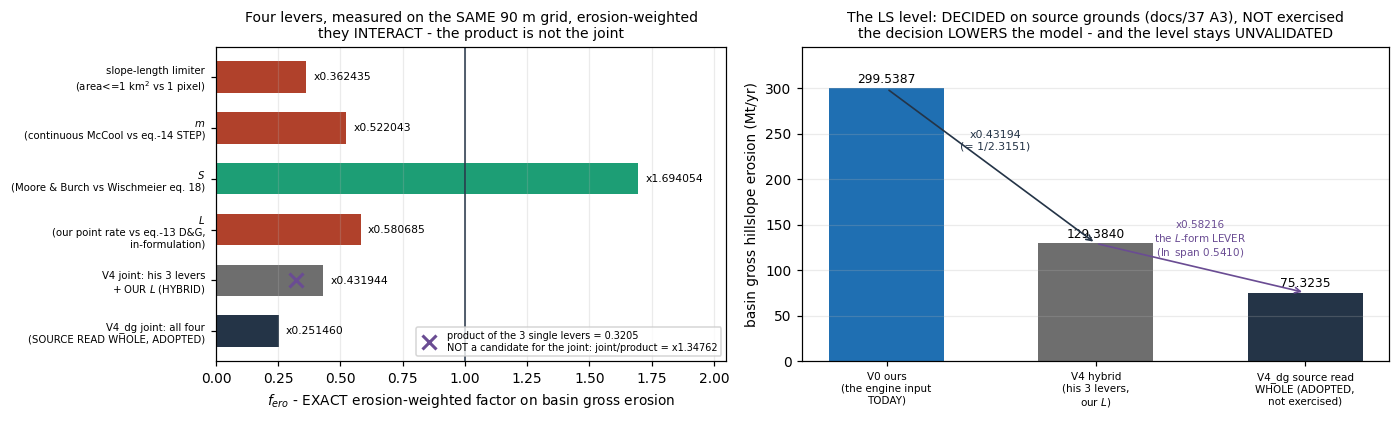

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.9),
                       gridspec_kw={'width_ratios': [1.0, 1.15]})
labs = ([l for l, _, _ in LEVERS]
        + ['V4 joint: his 3 levers\n+ OUR $L$ (HYBRID)',
           'V4_dg joint: all four\n(SOURCE READ WHOLE, ADOPTED)'])
vals = [v for _, v, _ in LEVERS] + [F_HYB_ERO, F_SRC_ERO]
cols = ([CB['red'] if v < 1 else CB['green'] for v in vals[:4]]
        + [CB['grey'], CB['dark']])
yy = np.arange(len(labs))[::-1]
ax[0].barh(yy, vals, 0.62, color=cols)
ax[0].axvline(1.0, color=CB['dark'], lw=1.0)
for y_, v in zip(yy, vals):
    ax[0].text(v + 0.03, y_, f'x{v:.6f}', va='center', fontsize=7.0)
# The product of the single levers is NOT a candidate for the joint - shown ONLY to mark that it
# is refuted by measurement.  Standing rule: never quote a product of single levers as the joint.
ax[0].plot([prod_reg], [yy[4]], 'x', ms=9, mew=2.0, color=CB['purple'], zorder=5,
           label=f'product of the 3 single levers = {prod_reg:.4f}\n'
                 f'NOT a candidate for the joint: joint/product = '
                 f'x{F_HYB_ERO/prod_reg:.5f}')
ax[0].set_yticks(yy); ax[0].set_yticklabels(labs, fontsize=6.6)
ax[0].set_xlabel('$f_{ero}$ - EXACT erosion-weighted factor on basin gross erosion')
ax[0].set_xlim(0, 2.05)
ax[0].legend(fontsize=6.4, loc='lower right')
ax[0].set_title('Four levers, measured on the SAME 90 m grid, erosion-weighted\n'
                'they INTERACT - the product is not the joint', fontsize=9.2)

names2 = ['V0 ours\n(the engine input\nTODAY)', 'V4 hybrid\n(his 3 levers,\nour $L$)',
          'V4_dg source read\nWHOLE (ADOPTED,\nnot exercised)']
lv = [299.5387, 129.3840, 75.3235]
ax[1].bar(np.arange(3), lv, 0.55, color=[CB['blue'], CB['grey'], CB['dark']])
for i, v in enumerate(lv):
    ax[1].text(i, v + 6.0, f'{v:.4f}', ha='center', fontsize=8)
ax[1].annotate('', xy=(1, lv[1]), xytext=(0, lv[0]),
               arrowprops=dict(arrowstyle='->', lw=1.1, color=CB['dark']))
ax[1].text(0.52, (lv[0]+lv[1])/2 + 18, f'x{F_HYB_ERO:.5f}\n(= 1/{1/F_HYB_ERO:.4f})',
           ha='center', fontsize=7.2, color=CB['dark'])
ax[1].annotate('', xy=(2, lv[2]), xytext=(1, lv[1]),
               arrowprops=dict(arrowstyle='->', lw=1.1, color=CB['purple']))
ax[1].text(1.5, (lv[1]+lv[2])/2 + 14, f'x{F_SRC_ERO/F_HYB_ERO:.5f}\nthe $L$-form LEVER\n'
           f'($\\ln$ span {np.log(F_HYB_ERO/F_SRC_ERO):.4f})',
           ha='center', fontsize=6.8, color=CB['purple'])
ax[1].set_xticks(np.arange(3)); ax[1].set_xticklabels(names2, fontsize=6.8)
ax[1].set_ylabel('basin gross hillslope erosion (Mt/yr)')
ax[1].set_ylim(0, 345)
ax[1].set_title('The LS level: DECIDED on source grounds (docs/37 A3), NOT exercised\n'
                'the decision LOWERS the model - and the level stays UNVALIDATED', fontsize=9.2)
for a in ax:
    a.grid(alpha=0.25, axis='x' if a is ax[0] else 'y')
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** each of the **four** formulation levers as the *erosion-weighted*
multiplicative factor $f_{ero}$ it applies to basin gross erosion if the source's choice is
adopted - red bars lower the model, green raise it - then the two joint compositions: the grey
`V4` **hybrid** (his three levers with our $L$) and the dark `V4_dg`, **the source formulation read
whole**, which is the one `docs/37` A3 adopts. The vertical line at 1.0 is "no change". The purple
cross marks the **product of the three single levers**, plotted **only** so that its refutation is
visible: it is *not* a candidate for the joint. **Right:** the basin gross erosion each composition
implies - all three are **engine re-runs, not the area-weighted proxy** - with the joint factor and
the $L$-form lever annotated on the arrows.

**What it shows.** The dominant lever is the slope-length limiter at **x0.362435**: we cap upslope
*area* at 1 km<sup>2</sup>, which permits a unit slope length up to about 10,870 m or 118 pixels,
whereas the source caps slope *length* at one pixel. The $m$ lever - **his eq. 14, a step function
on slope percent, not a cap on our continuous $m$** - is **x0.522043**; the $S$ lever (his eq. 18,
Wischmeier & Smith 1978) is the only upward one at **x1.694054**; and the $L$ lever (his eq. 13,
Desmet & Govers finite difference) is **x0.580685** inside the source formulation. **The product of
the first three is 0.3205244 and the measured joint is 0.431944 - joint / product = x1.34762** - so
they interact and cannot be decided one at a time, and the product may never be quoted as the
joint. Our level is 39.812, which this notebook independently reproduces from `urh_ls2d.csv` as
39.8123. The registered bracket is $f_{LS}\in$ **[0.25146, 0.43194]** erosion-weighted, i.e. **our
$LS$ is 2.3151x to 3.9768x the level $\alpha=11.8$ is paired with**, and the basin total falls from
**299.5387** to **129.3840** (hybrid) and **75.3235 Mt/yr** (source read whole). Rescaling the
pre-registered guard band by that bracket turns the expected 5.9-23.6 into **1.484-10.194** and the
hard stop 35.4 into **8.902-15.291**; at the adopted point both collapse to single numbers,
**2.9672** and **8.9017**.

**What it means.** **This was the single highest-value open item in the whole sediment phase; it is now
decided on source grounds, and the decision makes the answer worse.** Because MUSLE is linear in
$LS$, the factor applies directly to the level. **Read the interval correctly: it is not
uncertainty.** All four levers are **CITED** with a single admissible reading each, so the source
formulation read whole is a **POINT at x0.25146**; x0.43194 is a documented **hybrid** kept only
because it is what was published; and the span between them, $\ln(0.43194/0.25146) = 0.5410$, **is
the $L$-form lever** and nothing else. The earlier bracket **x0.333-x0.421 / "2.37x-3.00x" is
superseded**, and its lower endpoint was built on a x0.790 that does not isolate the $L$ form -
it factorises as $0.852262\times0.926925$ and was measured on the uncapped `ls2d` column rather
than the engine's `ls2d_hs`. It also demolishes the reassurance that the unfitted $\alpha = 11.8$
sits comfortably inside its registered band: at the adopted point the like-for-like reference is
**2.9672**, so 11.8 sits *above* its own corrected hard stop of 8.9017. **Four things this figure
does NOT license.** It does not license netting this factor against the upward corrections
elsewhere in the notebook - a formulation error is resolved on source grounds, not cancelled by
another factor. It does not license re-opening the choice because a total is unattractive; that
outcome was pre-registered precisely so it could not be treated as evidence. It does not license
quoting the rescaled $\alpha$ numbers as a **test** - they are bookkeeping about the *pairing* of
$\alpha$ with an $LS$, they pass and fail nothing, and $\alpha=11.8$'s like-for-likeness with any
2-D contributing-area $LS$ is **NOT SETTLED with no band offered**. And it does not license reading
A3's decision as a change to this notebook: **no engine default has moved**, every number after
section 3.6 is still at `V0` with $f_{LS} = 1.000$, the **LS level remains UNVALIDATED**, C3 stays
**OPEN** and C4.3 stays **BLOCKED**.

## 4 - $q_{peak}$: what a daily model does about an instantaneous peak

### 4.1 The gap, stated precisely

MUSLE's runoff-energy term is a **volume** multiplied by a **peak rate**. The volume a daily model
has. The peak rate it does not: our engine's smallest time step is one day, so it has no sub-daily
state at all and literally cannot know whether the day's runoff arrived as a two-hour cloudburst or
drizzled evenly for twenty-four hours. Those two days have identical $Q_{sur}$ and very different
$q_{peak}$, and MUSLE says they erode differently.

This gap has to be priced **before** calibration, and the reason is specific to this project's
history. $\alpha$ is a free multiplicative parameter sitting immediately downstream of a known
systematic error. A fitter handed that arrangement will absorb the error into $\alpha$ and report a
good fit - which is the mistake this project has already made twice in Phase B, once with a
celerity surrogate and once with a parameter that railed at its bound. So the proxy is fixed
first, its bias is quantified in writing, and a test is registered that stops the next stage from
hiding it.

### 4.2 Three candidates, and the fact that two of them are the same equation

**(i) The daily-mean surface-runoff rate - the floor estimate.**

$$q_{peak} \;=\; \frac{Q_{sur}\,[\mathrm{mm\,d^{-1}}]\cdot a\,[\mathrm{km^2}]}{86.4}
\qquad [\mathrm{m^3\,s^{-1}}]$$

The 86.4 is not a fudge factor, it is a unit conversion carrying no assumption: a depth of
$Q_{sur}$ mm over $a$ km<sup>2</sup> is $\frac{Q_{sur}}{1000}\cdot a\cdot 10^{6} = 1000\,Q_{sur}a$
m<sup>3</sup> per day, and dividing by 86,400 s gives $Q_{sur}a/86.4$ m<sup>3</sup> s<sup>-1</sup>.
It **assumes** the day's runoff leaves at a constant rate for 24 hours, i.e. that there is no storm
within the day. Since the instantaneous peak of any non-constant hydrograph exceeds its mean, this
is a **provable floor**: $q_{peak,\mathrm{true}} \ge q_{peak,\mathrm{proxy}}$ always, with equality
only on a perfectly flat day. It needs $Q_{sur}$ and area, both of which exist and are frozen.

**(ii) An SCS triangular unit hydrograph** - the physically ambitious option:

$$q_{peak} = \frac{2V}{T_b},\quad V = 1000\,Q_{sur}a\ \mathrm{m^3},\quad T_b = 2.67\,T_p,\quad
T_p = \frac{D}{2}+0.6\,t_c
\;\Longrightarrow\; q_{peak} \approx \frac{Q_{sur}\,a}{4.806\,T_p[\mathrm{h}]}$$

with $t_c$, the **time of concentration** (how long water takes to travel from the hydraulically
most distant point to the outlet), estimated by Kirpich from channel length and slope. **Rejected
for production, on three grounds, none of which is convenience.**

* It needs $D$, the **rainfall-excess duration**. In a model with no sub-daily rainfall $D$ is not
  merely unknown, it is *unconstrained*: $D=24$ h collapses (ii) back onto (i), while $D=6$ h
  triples the peak. Nothing measured in this project can choose between those, so (ii) would be a
  **tuned** choice wearing a physical costume.
* It needs a basin-wide slope field, which does not exist. The only processed DEM covers **1,506 of
  8,672 minibacias (17.4 %)** - and they are the *flat* ones, the lower Magdalena window, median
  channel slope 0.0056 m/m. A $t_c$ field built from that sample would manufacture spatial
  structure from the least representative fifth of the basin, excluding precisely the Andean flanks
  that do the eroding. Wrong in the worst available direction.
* Its shape constant $T_b = 2.67T_p$ is US-derived and is known to overestimate peaks in flat humid
  basins.

**(iii) The source method's own formulation - and it turns out to equal (i).** The paper this
project transposes is not in the repository, so the formulation was recovered from the MGB-SED
source it inherits, Buarque (2015), whose **eq. 7** reads
$q_{pico} = D_{sup}\cdot A/86.4$, preceded by the sentence *"the peak rate of surface runoff in
each pixel is obtained considering a runoff volume uniform through the day."* His eq. 5 applies
MUSLE **per DEM pixel** inside each URH of each minibacia. There is no unit hydrograph, no
rainfall disaggregation and no regionalised peak relation anywhere in that lineage.

**So (iii) is identical to (i): the floor estimate is not an expedient, it is the published
method.** That is the strongest of the four reasons for the registered choice, because it makes the
method-transfer claim exact - our loads are comparable to the published South-American MGB-SED
numbers *bias for bias*, with the same daily-mean assumption and the same reference $\alpha$. Any
other proxy silently breaks that comparability while the same paper is still cited as the source.

### 4.3 The registered choice, and the scale it is evaluated at

> **REGISTERED (before the implementation existed):**
> $q_{peak}=Q_{sur}\,a/86.4$, evaluated at the COP90 pixel scale
> $a_p = 0.0081\ \mathrm{km^2}$ and summed analytically to the URH cell:
> $$\mathrm{Sed}_{URH} = \frac{A_{URH}}{a_p}\;\alpha\left(Q_{sur}\cdot\frac{Q_{sur}a_p}{86.4}\cdot
> a_p\right)^{\beta}K\,C\,P\,LS$$

Evaluating at the pixel scale is not cosmetic: section 5.5 shows MUSLE is scale-dependent, so
keeping the source's pixel scale is what makes a fitted $\alpha$ comparable to 11.8 **with no
correction factor** - which is what makes the parameter guard enforceable rather than notional.

In [18]:
AP = sed.COP90_PIXEL_AREA_KM2
print(f'the registered proxy, from scripts/c3/qpeak.py (imported, never re-derived):')
print(f'  MM_KM2_PER_DAY_TO_M3S = {qpk.MM_KM2_PER_DAY_TO_M3S!r}  = 1/86.4 = {1/86.4!r}')
print(f'  COP90_PIXEL_AREA_KM2  = {AP}  ->  side {math.sqrt(AP)*1000:.1f} m')
hand = qpk.qpeak_daily_mean(10.0, 25.0)
print(f'\n  hand check, Qsur = 10 mm/d over A = 25 km2: {hand!r} m3/s   '
      f'(10*25/86.4 = {10*25/86.4!r})')

# q_peak at the MINIBACIA scale, purely as a physically interpretable diagnostic
QPK_MB = (Q * (A_MB / 86.4).astype(np.float32))          # m3/s, float32 to stay lean
print(f'\nq_peak per minibacia-day (diagnostic scale = whole minibacia, m3/s):')
print(f'  median {np.median(QPK_MB):.4f}   p99 {np.percentile(QPK_MB,99):.4f}   '
      f'max {QPK_MB.max():.2f}')
yr = DATES.year.to_numpy()
am = np.stack([QPK_MB[yr == y].max(axis=0) for y in range(2009, 2019)])   # (10, 8672)
am_fleet = np.median(am, axis=0)
print(f'  annual-maximum q_peak, fleet median {np.median(am_fleet):.3f} m3/s '
      f'(p05 {np.percentile(am_fleet,5):.3f}, p95 {np.percentile(am_fleet,95):.3f})')
print(f'\nq_peak at the REGISTERED pixel scale a_p (what MUSLE is actually fed):')
qp_pix = qpk.qpeak_daily_mean(np.array([qs['median'], qs['p99'], qs['max']]), AP)
for lab, v in zip(('median day', 'p99 day', 'max day'), qp_pix):
    print(f'  {lab:11s} Qsur -> q_peak = {v:.3e} m3/s per 0.0081 km2 pixel')

print('\nthe REJECTED option (ii), retained only as a sensitivity generator:')
TP_H = np.array([3, 4, 6, 9, 12, 18], float)
AMP = np.array([qpk.peak_amplification(h) for h in TP_H])
for h, a_ in zip(TP_H, AMP):
    print(f'  T_p = {h:4.0f} h  ->  amplification {a_:5.3f}  ->  sediment factor '
          f'amp^beta = {a_**sed.WILLIAMS_BETA:5.3f}')
print(f'  amplification = 86.4/(4.806*T_p) = 17.978/T_p, so option (ii) is option (i) times a')
print(f'  number between ~1.0 and ~6.0 whose SPATIAL variation comes only through the slope')
print(f'  field that does not exist.')

the registered proxy, from scripts/c3/qpeak.py (imported, never re-derived):
  MM_KM2_PER_DAY_TO_M3S = 0.011574074074074073  = 1/86.4 = 0.011574074074074073
  COP90_PIXEL_AREA_KM2  = 0.0081  ->  side 90.0 m

  hand check, Qsur = 10 mm/d over A = 25 km2: np.float64(2.893518518518518) m3/s   (10*25/86.4 = 2.893518518518518)

q_peak per minibacia-day (diagnostic scale = whole minibacia, m3/s):


  median 0.2429   p99 4.2852   max 108.03
  annual-maximum q_peak, fleet median 2.176 m3/s (p05 0.364, p95 6.211)

q_peak at the REGISTERED pixel scale a_p (what MUSLE is actually fed):
  median day  Qsur -> q_peak = 7.079e-05 m3/s per 0.0081 km2 pixel
  p99 day     Qsur -> q_peak = 1.064e-03 m3/s per 0.0081 km2 pixel
  max day     Qsur -> q_peak = 6.974e-03 m3/s per 0.0081 km2 pixel

the REJECTED option (ii), retained only as a sensitivity generator:
  T_p =    3 h  ->  amplification 5.993  ->  sediment factor amp^beta = 2.726
  T_p =    4 h  ->  amplification 4.494  ->  sediment factor amp^beta = 2.320
  T_p =    6 h  ->  amplification 2.996  ->  sediment factor amp^beta = 1.849
  T_p =    9 h  ->  amplification 1.998  ->  sediment factor amp^beta = 1.473
  T_p =   12 h  ->  amplification 1.498  ->  sediment factor amp^beta = 1.254
  T_p =   18 h  ->  amplification 0.999  ->  sediment factor amp^beta = 0.999
  amplification = 86.4/(4.806*T_p) = 17.978/T_p, so option (ii) is option (i

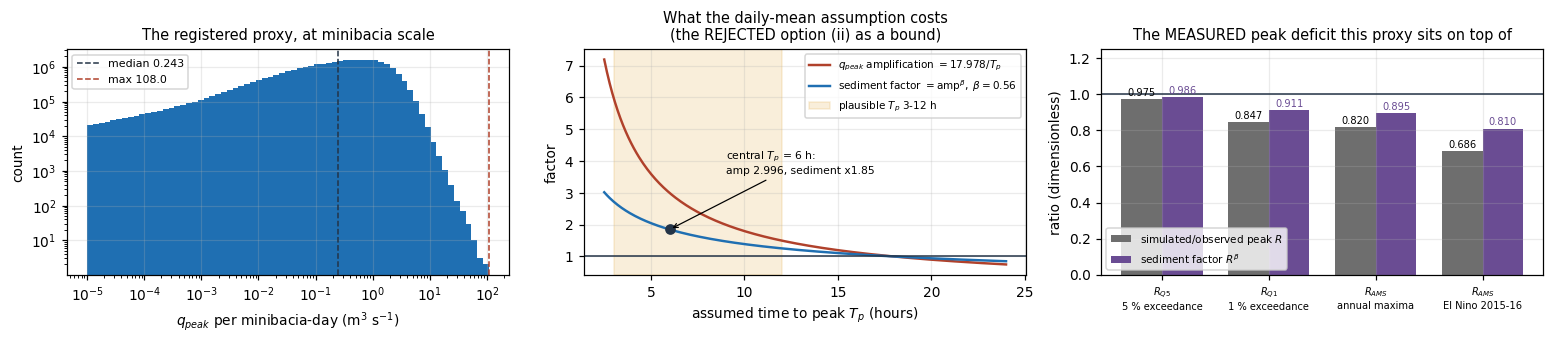

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14.2, 3.2))
b = np.logspace(-5, np.log10(float(QPK_MB.max())), 70)
ax[0].hist(QPK_MB.ravel()[QPK_MB.ravel() > 0], bins=b, color=CB['blue'])
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].axvline(np.median(QPK_MB), color=CB['dark'], ls='--', lw=1.0,
              label=f'median {np.median(QPK_MB):.3f}')
ax[0].axvline(QPK_MB.max(), color=CB['red'], ls='--', lw=1.0,
              label=f'max {QPK_MB.max():.1f}')
ax[0].set_xlabel('$q_{peak}$ per minibacia-day (m$^3$ s$^{-1}$)'); ax[0].set_ylabel('count')
ax[0].set_title('The registered proxy, at minibacia scale'); ax[0].legend(fontsize=7.2)

tp = np.linspace(2.5, 24, 300)
amp = 17.978 / tp
ax[1].plot(tp, amp, color=CB['red'], lw=1.6, label='$q_{peak}$ amplification $=17.978/T_p$')
ax[1].plot(tp, amp**sed.WILLIAMS_BETA, color=CB['blue'], lw=1.6,
           label=r'sediment factor $=\mathrm{amp}^{\beta},\ \beta=0.56$')
ax[1].axhline(1.0, color=CB['dark'], lw=1.0)
ax[1].axvspan(3, 12, color=CB['amber'], alpha=0.15, label='plausible $T_p$ 3-12 h')
ax[1].plot([6], [(17.978/6)**sed.WILLIAMS_BETA], 'o', ms=6, color=CB['dark'])
ax[1].annotate(f'central $T_p$ = 6 h:\namp 2.996, sediment x{(17.978/6)**0.56:.2f}',
               xy=(6, (17.978/6)**0.56), xytext=(9.0, 3.6), fontsize=7,
               arrowprops=dict(arrowstyle='->', lw=0.8))
ax[1].set_xlabel('assumed time to peak $T_p$ (hours)'); ax[1].set_ylabel('factor')
ax[1].set_title('What the daily-mean assumption costs\n(the REJECTED option (ii) as a bound)')
ax[1].legend(fontsize=6.8, loc='upper right')

R = {'$R_{Q5}$\n5 % exceedance': 0.975, '$R_{Q1}$\n1 % exceedance': 0.847,
     '$R_{AMS}$\nannual maxima': 0.820, '$R_{AMS}$\nEl Nino 2015-16': 0.686}
xx = np.arange(len(R))
ax[2].bar(xx - 0.19, list(R.values()), 0.38, color=CB['grey'], label='simulated/observed peak $R$')
ax[2].bar(xx + 0.19, [qpk.sediment_bias_ratio(v, 0.56) for v in R.values()], 0.38,
          color=CB['purple'], label=r'sediment factor $R^{\beta}$')
ax[2].axhline(1.0, color=CB['dark'], lw=1.0)
for i, v in enumerate(R.values()):
    ax[2].text(i - 0.19, v + 0.02, f'{v:.3f}', ha='center', fontsize=6.5)
    ax[2].text(i + 0.19, qpk.sediment_bias_ratio(v, 0.56) + 0.02,
               f'{qpk.sediment_bias_ratio(v, 0.56):.3f}', ha='center', fontsize=6.5, color=CB['purple'])
ax[2].set_xticks(xx); ax[2].set_xticklabels(list(R), fontsize=6.5)
ax[2].set_ylim(0, 1.25); ax[2].set_ylabel('ratio (dimensionless)')
ax[2].set_title('The MEASURED peak deficit this proxy sits on top of')
ax[2].legend(fontsize=6.8, loc='lower left')
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the distribution of the registered peak-flow proxy over all 31.7 M
minibacia-days, evaluated at whole-minibacia scale so the values are physically readable (the model
itself applies it per 0.0081 km<sup>2</sup> pixel); log-log axes, dashed lines at the median and
maximum. **Middle:** the *rejected* unit-hydrograph option used as an error bound - red is the
factor by which it would amplify the peak as a function of assumed time-to-peak $T_p$, blue is the
resulting factor on sediment, which is the amplification raised to $\beta = 0.56$; the amber band
is a plausible $T_p$ range and the marker is the central 6-hour case. **Right:** the separately
measured flood-peak deficit of the frozen hydrology - grey bars are simulated-over-observed peak
ratios at four definitions, purple bars the corresponding sediment factor $R^{\beta}$.

**What it shows.** The proxy gives a median $q_{peak}$ of 0.243 m<sup>3</sup> s<sup>-1</sup> per
minibacia-day, a 99th percentile of 4.285 and a maximum of 108.03; the fleet median of the annual
maxima is 2.18 m<sup>3</sup> s<sup>-1</sup>. The middle panel shows the amplification is 1.50 at
$T_p = 12$ h, **2.996 at 6 h** and 5.99 at 3 h, which through $\beta$ becomes a sediment factor of
1.26, **1.86** and 2.75 - so the daily-mean assumption suppresses flood-driven sediment by about
**-21 % to -64 %, central -46 %**. The right panel shows the hydrology's own peak ratios:
$R_{Q5} = 0.975$ (essentially unbiased), $R_{Q1} = 0.847$, $R_{AMS} = 0.820$ and, in the El Nino
phase, 0.686 - which as sediment become 0.986, 0.911, 0.895 and 0.810.

**What it means.** Three readings, and the third is the one that constrains stage C4. (1) The proxy's
error has a **provable direction**: it is a floor, so the simulated load is a strict lower bound
given $Q_{sur}$. A one-sided error of known sign is worth more here than a smaller error of
ambiguous sign, because the whole point is to state a direction a reader can trust. (2) This term
must **not** be corrected for and must not be absorbed by $\alpha$: the reference $\alpha = 11.8$
was adopted *with this same daily-mean proxy*, so correcting it while still comparing to that
$\alpha$ double-counts. (3) The right panel's deficit is a **tail effect, not a level shift** - the
model is unbiased at the 95th flow percentile and short only above it - which means a *constant*
$\alpha$ cannot repair it without over-predicting sediment on the 95 % of days that are already
right. That asymmetry is the fingerprint the registered residual test is designed to detect.

### 4.4 The bias statement, written before the implementation existed - and why the ordering
is a method rather than a formality

Two independent errors sit under this sediment estimate, and **they point the same way, so they
compound and there is no cancellation to hope for.**

**The proxy's own bias** (section 4.3): a factor of **1.26 - 2.75, central $\approx$ 1.9**, i.e.
-21 % to -64 % of flood-driven sediment relative to a model that resolved sub-daily peaks.

**The peak deficit the proxy sits on top of**, measured on the frozen hydrology and *not* assumed:
the fleet-median annual-maximum ratio is 0.820, which through $\beta$ is -10.5 %; in the El Nino
phase it is 0.686, i.e. -19.0 %. And separately, a **count** deficit: the model produces **1,285
independent peaks-over-threshold against 2,236 observed**, so about **43 % of flood events are
missing entirely**. $\beta$ acts on magnitude, so it **cannot** convert a count deficit into a load
deficit - writing $0.567^{0.56}=0.728$ would be wrong, and it is recorded as wrong in the
registration so that nobody does it later. The honest bracket is: if the 951 missing events were
the smallest ones, the count channel adds a few per cent; if they were of average above-threshold
size, it approaches **-42.5 %**. Nothing measured in this project resolves where in that bracket
the truth lies, so it stays a bracket.

> **REGISTERED BIAS STATEMENT.** Simulated flood-driven suspended-sediment transport from this
> model is a **LOWER BOUND**. From the measured peak-magnitude deficit alone it is low by at least
> **10.5 %** fleet-wide and at least **19.0 %** in El Nino 2015-16. Adding the missing 43 % of
> events, the flood-driven deficit is plausibly **-10 % to -45 %**. Adding the proxy's own
> sub-daily assumption, total suppression relative to a sub-daily-resolved model is a factor of
> $\approx$ **2.1 (bracket 1.4 - 4.8)** - but that last term is method-consistent with the source
> lineage and must be reported separately, never merged into the first two and never absorbed by
> $\alpha$. **No channel pushes the other way.**

**And one direction that is not conservative.** The peak deficit is **phase-asymmetric**: the dry
phase is suppressed harder ($R_{AMS}$ 0.686) than the wet phase (0.808). The ratio of their
sediment factors is $0.8875/0.8097 = 1.096$, so **the simulated La Nina : El Nino sediment ratio is
overstated by about +10 %** from the magnitude channel alone, with the count channel pointing the
same way. That *flatters* the study's headline contrast, so it must be quoted whenever a simulated
contrast is quoted - which section 8 does.

**Why write all of this down before writing the code?** Because the alternative is not neutrality,
it is a specific failure mode. $\alpha$ is a multiplicative constant and $\beta$ a tail exponent,
which is *exactly* the shape a fitter reaches for when confronted with a multiplicative,
tail-concentrated suppression. The available compensation product is bounded and known in advance -
$2.75 \times 1.12 \times 1.74 \approx 5.4\times$ - so the pre-registered thresholds were set at a
*fraction* of that, which is what makes the alarm fire long before full compensation is reached.
Registering the bias first converts an unfalsifiable judgement call ("does this $\alpha$ look
reasonable?") into a checkable one ("is this $\alpha$ inside a band written down before anyone saw
it?"). That is the method. Section 7.1 then shows, honestly, that the method has a hole in it.

**One earlier claim in this project's own documents was wrong here, and is corrected.** An earlier
plan stated the peak bias is "worst at the largest" gauges. It was measured:
$\rho(R_{AMS}, \mathrm{area}) = +0.088$, $p = 0.49$ - **indistinguishable from zero**. The peak
deficit does *not* scale with catchment area, unlike the correlation deficit, which does. Any C3 or
C4 reasoning that leans on an area-dependent peak bias is leaning on a refuted claim.

## 5 - THE ORDER-OF-MAGNITUDE GAP

### 5.1 The first run, and why its *direction* was the finding

The engine was run over the whole frozen decade with the registered configuration and Williams'
unfitted coefficients. The result was **0.684 Mt/yr** of gross hillslope erosion for the whole
Magdalena-Cauca basin.

The published suspended-sediment load of this river at its outlet is **144 Mt/yr** (Restrepo &
Kjerfve 2000, 1975-1995) and **184 Mt/yr** (Restrepo & Escobar 2018, 1980-2010). So the first run
was **210x to 269x too small**.

**The direction is what mattered, and it was the opposite of what the run was set up to expect.**
The task that commissioned that run anticipated an *over*-estimate, on sound reasoning: the model
computes erosion on hillslopes and stops there, with no channel transport and no floodplain
deposition, and the Magdalena has an enormous floodplain sink (the Depresion Momposina) upstream of
the gauging point. Sediment can only be *lost* between hillslope and outlet. Therefore

$$\underbrace{E_{\mathrm{gross}}}_{\text{what the model computes}} \;>\;
\underbrace{L_{\mathrm{outlet}}}_{\text{what is measured}}$$

is required, and coming out *below* the outlet load is the **physically forbidden direction** - it
would mean the basin exports more sediment than its hillslopes produce. That is a far stronger
signal than "the number is too small", because a magnitude error can be argued about while a sign
error cannot: it says something in the chain is definitely wrong, not merely uncertain. (Section 6
will complicate even this inequality - it is exactly true of the ratio it names, and *not* true of
the ratio that was actually computed. But as an alarm it worked.)

### 5.2 The suspect: a coefficient whose value depends on units it was never told

**What the cell computes.** MUSLE has three unit conventions in circulation for its first factor,
and the coefficient $\alpha$ has a different numerical value in each. The cell converts Williams'
*original* fitted equation into metric units three different ways and asks which one produces
11.8.

Williams' original, in US-customary units:

$$Y\,[\mathrm{short\ ton}] \;=\; 95\,\bigl(Q\,[\mathrm{acre\text{-}ft}]\cdot
q_p\,[\mathrm{cfs}]\bigr)^{0.56}\,K\,C\,P\,LS$$

Convert **only** the dimensional quantities, holding $K$, $C$, $P$, $LS$ fixed (they are the same
USLE factors in both forms - Williams changed the runoff variables and the mass unit, not the soil
factors):

$$\alpha_{\mathrm{metric}} \;=\; 95\times 0.90718474 \times
\bigl(1233.4818375\times0.028316846592\bigr)^{-0.56}$$

using 1 acre-ft = 1233.4818375 m<sup>3</sup>, 1 cfs = 0.028316846592 m<sup>3</sup> s<sup>-1</sup>,
1 short ton = 0.90718474 t. Output: dimensionless-in-context numeric value of $\alpha$.

**The honest statement about what dimensional analysis can and cannot do here.** MUSLE is an
empirical power law and $\alpha$ is *not* dimensionless - it carries whatever dimensions balance
the equation. So dimensional homogeneity **cannot** select the units: for *any* choice of units for
$(Q, q_{peak}, A)$ there exists some $\alpha$ that works. The discrimination therefore has to come
from **exact unit conversion of Williams' own fitted coefficient**, which has exactly one answer.

In [20]:
ACRE_FT_M3 = 1233.4818375
CFS_M3S = 0.028316846592
SHORT_TON_T = 0.90718474
denom = ACRE_FT_M3 * CFS_M3S
a_m3 = 95 * SHORT_TON_T * denom ** -0.56
print('WILLIAMS (1975), converted from his own US-customary form, three readings:')
print(f'  1 acre-ft x 1 cfs = {denom!r}')
print(f'  (that)^-0.56      = {denom**-0.56!r}')
print(f'  95 x 0.90718474   = {95*SHORT_TON_T!r}')
print(f'\n  runoff volume in m3, q_peak in m3/s, yield in t : alpha = {a_m3!r}')
print(f'      -> {100*abs(a_m3-11.8)/11.8:.2f} % from the published 11.8   ** THIS IS THE ONE **')
print(f'  read as Qsur[mm] x A[ha]  (1 mm over 1 ha = 10 m3): alpha = {a_m3*10**0.56!r}')
print(f'  read as Qsur[mm] x A[km2] (1 mm over 1 km2 = 1000 m3): alpha = {a_m3*1000**0.56!r}')
print('\n  Only one of the three lands on 11.8. The hectare reading would need alpha = 42.78 and')
print('  the km2 reading alpha = 563.95, and neither number appears anywhere in the literature.')
print('\n  secondary discriminator: if Williams\' Y had been METRIC tons, the conversion gives')
print(f'  {95*denom**-0.56!r}, which is {100*abs(95*denom**-0.56-11.8)/11.8:.1f} % from 11.8 '
      f'against {100*abs(a_m3-11.8)/11.8:.2f} % for the short-ton reading.')

print('\nthe engine\'s three named conventions, and the load factor each implies:')
for name, f in sed.VOLUME_FACTORS.items():
    tag = '  <- DEFAULT' if name == sed.DEFAULT_VOLUME_CONVENTION else ''
    print(f'  {name:12s} product x{f:7.1f}   load x{f**sed.WILLIAMS_BETA:9.4f}{tag}')
print(f'\n  1000^0.56 = {1000**0.56!r}   100^0.56 = {100**0.56!r}   10^0.56 = {10**0.56!r}')

print('\nHAND CASE (the number any correct implementation must reproduce).')
print('  Qsurf 10 mm, q_peak 1 m3/s, A = 100 ha = 1 km2, K 0.3, C 0.1, P 1, LS 1, FG 1')
V = 1.0e6 * 0.010
print(f'  V = 100 ha x 0.010 m = {V:,.0f} m3;  V*q_p = {V*1.0:,.0f};  ^0.56 = {(V*1.0)**0.56!r}')
print(f'  alpha=11.8: 11.8 x {(V*1.0)**0.56:.6f} x 0.3 x 0.1 = '
      f'{11.8*(V*1.0)**0.56*0.3*0.1!r} t')
Y_us = 95 * ((V/ACRE_FT_M3) * (1/CFS_M3S)) ** 0.56 * 0.3 * 0.1
print(f'  Williams\' exact 95-form, no use of 11.8: {Y_us*SHORT_TON_T!r} t')
print(f'  -> the two independent routes agree to '
      f'{100*abs(11.8*(V*1.0)**0.56*0.3*0.1 - Y_us*SHORT_TON_T)/(Y_us*SHORT_TON_T):.2f} %, '
      f'which is the rounding of 11.7826 -> 11.8')
for name, f in sed.VOLUME_FACTORS.items():
    got = sed.musle_load_tonnes(10.0, 1.0, 1.0, 0.3, 0.1, 1.0, 1.0, volume_factor=f)
    print(f'  engine, volume_convention={name!r:12s}: {float(got):12.6f} t   '
          f'ratio to hand case {float(got)/(11.8*(V*1.0)**0.56*0.3*0.1):.6f}')

WILLIAMS (1975), converted from his own US-customary form, three readings:
  1 acre-ft x 1 cfs = 34.92831596650577
  (that)^-0.56      = 0.13671636964275896
  95 x 0.90718474   = 86.1825503

  runoff volume in m3, q_peak in m3/s, yield in t : alpha = 11.782565403570468
      -> 0.15 % from the published 11.8   ** THIS IS THE ONE **
  read as Qsur[mm] x A[ha]  (1 mm over 1 ha = 10 m3): alpha = 42.7799092692986
  read as Qsur[mm] x A[km2] (1 mm over 1 km2 = 1000 m3): alpha = 563.9490366908459

  Only one of the three lands on 11.8. The hectare reading would need alpha = 42.78 and
  the km2 reading alpha = 563.95, and neither number appears anywhere in the literature.

  secondary discriminator: if Williams' Y had been METRIC tons, the conversion gives
  12.988055116062101, which is 10.1 % from 11.8 against 0.15 % for the short-ton reading.

the engine's three named conventions, and the load factor each implies:
  pixel_km2    product x    1.0   load x   1.0000
  swat_mm_ha   product x  1

### 5.3 The second factor, which the first correction did not see

The conversion above converts $Y$, $Q$ and $q_p$ and leaves $K$, $C$, $P$, $LS$ **untouched** - so
$\alpha = 11.8$ belongs to the **US-customary numeric values** of those four. Section 2.2 already
established, from this repository's own notebook 09 §4, that the stored $K$ is in SI, produced by
multiplying Wischmeier's US-customary class values by 0.1317.

Pairing an SI $K$ with $\alpha = 11.8$ is therefore a dimensional error of exactly

$$f_K \;=\; \frac{1}{0.1317} \;=\; 7.593014$$

and, crucially, this factor is **linear** in the load - it sits *outside* the $\beta$ power, unlike
the volume factor which sits inside it. The two corrections are independent and multiply:

$$f_{\mathrm{total}} \;=\; 1000^{0.56}\times\frac{1}{0.1317}
\;=\; 47.8630 \times 7.593014 \;=\; 363.4245196$$

**This error was missed by the pass that found the first one.** The volume-convention amendment was
written, adopted, and its consequences documented - and it did not notice that the same conversion
which fixes the volume also fixes $K$. It was found by a *separate, independent dimensional audit*
which re-derived the whole chain from scratch and reported the $K$ term as "a fourth error, not
among the three I was asked to check". That is the argument for running verification passes that
re-derive rather than review: a reviewer checks the reasoning presented, and this error was in the
reasoning *not* presented.

**A structural check that the second factor cannot have broken the first.** A constant factor $F$
on the runoff product moves $\alpha$ by $F^{\beta}$ and **cannot move $\beta$ at all**, and the $K$
factor is outside the power entirely. So the registered $\beta$ band and the scale rescaling of
section 5.5 are untouched by both corrections - not by lucky coincidence but by the algebra.

### 5.4 The full grid, measured

**What the cell computes.** All six combinations of the three volume conventions and the two $K$
unit systems, over the full frozen decade, at the *prior* cover factor so the numbers are directly
comparable with the published first-run figures. Each run:

$$E_{\mathrm{basin}} = \sum_{t=1}^{3652}\sum_{c=1}^{32782}
\frac{A_c}{a_p}\,\alpha\left(Q_{sur}(t,m(c))\cdot\frac{Q_{sur}(t,m(c))a_p}{86.4}\cdot a_p\cdot
f_{vol}\right)^{\beta} K_{m(c)} f_K\, C_{\ell(c)} P\, LS_c$$

in tonnes, divided by $3652/365.25$ years and by $10^6$ to give **Mt yr<sup>-1</sup>**. The mass
ledger $\mathrm{eroded}-\mathrm{delivered}-\Delta\mathrm{store}$ is reported for each run and must
be **exactly** zero, since the delivery reservoir's residence time is zero and the release
coefficient is therefore exactly 1.0 (bitwise pass-through).

In [21]:
def run(geom, **kw):
    p = sed.SedParams(**kw)
    r = sed.simulate_sediment(geom, p, Q, dates=DRV.dates, store_daily=False)
    return r, float(r.ledger['eroded_t']) / 1e6 / YEARS


GRID = {}
print(f'{"volume_convention":14s} {"k_unit_system":14s} {"Mt/yr":>12s} {"vs 144":>10s} '
      f'{"vs 184":>10s}  ledger  s')
print('-' * 92)
for vc in sed.VOLUME_CONVENTIONS:
    for ku in sed.K_UNIT_SYSTEMS:
        r, mt = run(GEO_PRIOR, volume_convention=vc, k_unit_system=ku)
        GRID[(vc, ku)] = mt
        d144 = f'{144/mt:.1f}x low' if mt < 144 else f'{mt/144:.2f}x ABOVE'
        d184 = f'{184/mt:.1f}x low' if mt < 184 else f'{mt/184:.2f}x ABOVE'
        star = '  <- ADOPTED' if (vc, ku) == ('williams_m3', 'us_customary') else ''
        print(f'{vc:14s} {ku:14s} {mt:12.6f} {d144:>10s} {d184:>10s}  '
              f'{"EXACT" if r.ledger["exact"] else "approx":6s} {r.wall_time_s:4.1f}{star}')

FIRST = GRID[('pixel_km2', 'si_stored')]
ADOPT_PRIOR_C = GRID[('williams_m3', 'us_customary')]
print(f'\nmeasured factor, adopted / first run: {ADOPT_PRIOR_C/FIRST!r}')
print(f'derived      1000^0.56 x 1/0.1317   : {1000**0.56*(1/0.1317)!r}')
print(f'  agreement to {abs(ADOPT_PRIOR_C/FIRST - 1000**0.56*(1/0.1317)):.3e} '
      f'-> the chain is fully explained, to the last stored digit')
print(f'\nAND the C-factor revision, which is a NAMED INPUT CHANGE, not a further unit factor:')
r_ad, ADOPT = run(GEO)
print(f'  prior C   {ADOPT_PRIOR_C:.6f} Mt/yr   (area-wtd C {C_BAR_PRIOR:.6f})')
print(f'  adopted C {ADOPT:.6f} Mt/yr   (area-wtd C {C_BAR:.6f})   measured ratio '
      f'{ADOPT/ADOPT_PRIOR_C!r}')
print(f'  ledger: eroded {r_ad.ledger["eroded_t"]:,.4f} t, residual '
      f'{r_ad.ledger["residual_t"]!r}, exact = {r_ad.ledger["exact"]}')
BASIN_T_KM2_YR = ADOPT * 1e6 / GEO.covered_area_km2
print(f'\nMODEL-INTERNAL basin-mean gross hillslope erosion: {BASIN_T_KM2_YR:,.2f} t/km2/yr '
      f'= {BASIN_T_KM2_YR/100:.4f} t/ha/yr')
print('  LABEL: model-internal (model erosion / model area). NOT a gauge-referenced yield, which')
print('  is embargoed - catchment areas disagree by >2x on 36 % of shared gauges.')

volume_convention k_unit_system         Mt/yr     vs 144     vs 184  ledger  s
--------------------------------------------------------------------------------------------


pixel_km2      si_stored          0.684406 210.4x low 268.8x low  EXACT   4.1


pixel_km2      us_customary       5.196702  27.7x low  35.4x low  EXACT   4.2


swat_mm_ha     si_stored          9.022223  16.0x low  20.4x low  EXACT   3.9


swat_mm_ha     us_customary      68.505873   2.1x low   2.7x low  EXACT   4.2


williams_m3    si_stored         32.757713   4.4x low   5.6x low  EXACT   4.0


williams_m3    us_customary     248.729791 1.73x ABOVE 1.35x ABOVE  EXACT   3.7  <- ADOPTED

measured factor, adopted / first run: 363.4245196071666
derived      1000^0.56 x 1/0.1317   : 363.42451960716664
  agreement to 5.684e-14 -> the chain is fully explained, to the last stored digit

AND the C-factor revision, which is a NAMED INPUT CHANGE, not a further unit factor:


  prior C   248.729791 Mt/yr   (area-wtd C 0.010823)
  adopted C 299.538709 Mt/yr   (area-wtd C 0.013083)   measured ratio 1.2042735517968208
  ledger: eroded 2,994,977,042.2609 t, residual 0.0, exact = True

MODEL-INTERNAL basin-mean gross hillslope erosion: 1,165.08 t/km2/yr = 11.6508 t/ha/yr
  LABEL: model-internal (model erosion / model area). NOT a gauge-referenced yield, which
  is embargoed - catchment areas disagree by >2x on 36 % of shared gauges.


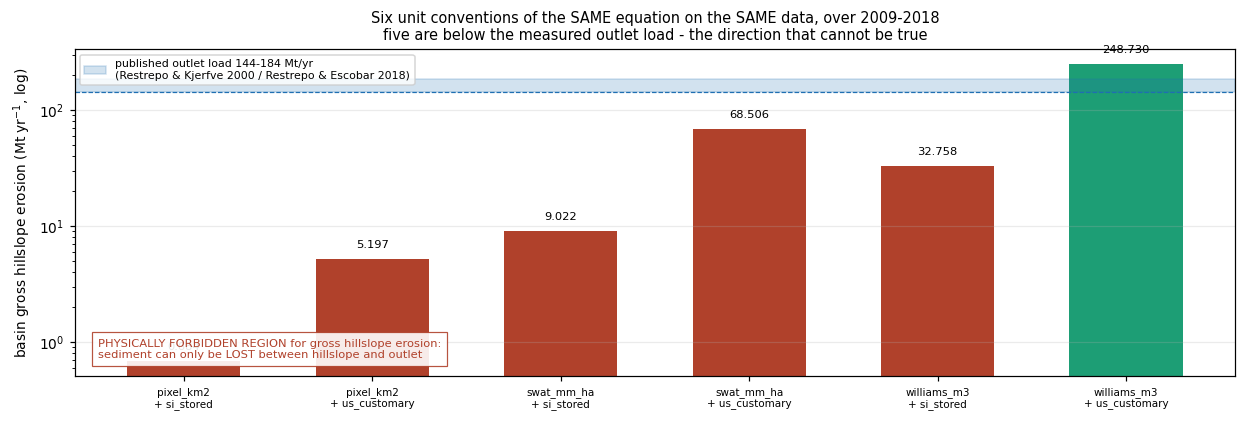

In [22]:
fig, ax = plt.subplots(figsize=(11.4, 3.9))
keys = [(vc, ku) for vc in sed.VOLUME_CONVENTIONS for ku in sed.K_UNIT_SYSTEMS]
vals = [GRID[k] for k in keys]
labs = [f'{vc}\n+ {ku}' for vc, ku in keys]
cols = [CB['green'] if k == ('williams_m3', 'us_customary')
        else (CB['red'] if GRID[k] < 144 else CB['amber']) for k in keys]
xx = np.arange(len(keys))
ax.bar(xx, vals, 0.6, color=cols)
ax.axhspan(144, 184, color=CB['blue'], alpha=0.20,
           label='published outlet load 144-184 Mt/yr\n(Restrepo & Kjerfve 2000 / Restrepo & Escobar 2018)')
ax.set_yscale('log')
for i, v in enumerate(vals):
    ax.text(i, v*1.25, f'{v:.3f}', ha='center', fontsize=7.5)
ax.text(0.02, 0.055, 'PHYSICALLY FORBIDDEN REGION for gross hillslope erosion:\n'
                     'sediment can only be LOST between hillslope and outlet',
        transform=ax.transAxes, fontsize=7.5, color=CB['red'],
        bbox=dict(fc='white', ec=CB['red'], lw=0.8, alpha=0.9))
ax.axhline(144, color=CB['blue'], lw=0.8, ls='--')
ax.set_xticks(xx); ax.set_xticklabels(labs, fontsize=6.8)
ax.set_ylabel('basin gross hillslope erosion (Mt yr$^{-1}$, log)')
ax.set_title('Six unit conventions of the SAME equation on the SAME data, over 2009-2018\n'
             'five are below the measured outlet load - the direction that cannot be true')
ax.legend(fontsize=7.2, loc='upper left')
ax.grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

**What is plotted.** Basin-total gross hillslope erosion, Mt yr<sup>-1</sup> on a log axis, for all six
combinations of the three volume conventions (how the runoff-energy product is expressed) and the
two soil-erodibility unit systems, run over the identical frozen decade with identical unfitted
coefficients. The blue band is the published outlet load 144-184 Mt yr<sup>-1</sup>. Red bars fall
below that band (physically impossible for gross hillslope erosion), green is the adopted
combination.

**What it shows.** The six values span **0.684 to 248.730 Mt yr<sup>-1</sup>, a range of 363x**, from
nothing but unit conventions: `pixel_km2`+SI 0.684406, `pixel_km2`+US 5.196702, `swat_mm_ha`+SI
9.022223, `swat_mm_ha`+US 68.505873, `williams_m3`+SI 32.757713, and `williams_m3`+US
**248.729791**. Five of the six sit below the outlet band. Only the adopted combination clears it,
at 1.35x above the upper anchor and 1.73x above the lower. Every run closed its mass ledger
**exactly** (residual bitwise 0.0), and the measured adopted/first ratio is 363.4245196071666
against the derived $1000^{0.56}/0.1317 = 363.42451960716664$.

**What it means.** The order-of-magnitude gap was **entirely a units problem**, and the arithmetic is
closed to the last stored digit rather than approximately - which is the difference between an
explanation and a story. It also shows why the *direction* alarm of section 5.1 was worth more than
the magnitude: five conventions were all wrong, and the one diagnostic that discriminated among
them without reference to the answer was "which reading reproduces the coefficient Williams
actually fitted". **The thing this figure must not be read as saying** is that the adopted row was
chosen because it clears the band. It was chosen by the derivation in section 5.2, written down
before any basin total was consulted, and the derivation explicitly noted at the time that it did
*not* close the gap on its own - the volume correction alone gives 32.76, still 4.4x low. The
second correction was found by an independent audit that also did not look at the total first.

### 5.5 Why $\beta<1$ makes the answer depend on the *scale* the equation is applied at

**What the cell computes.** The ratio between applying MUSLE once to a whole unit and applying it
separately to the $n$ pieces of that unit and summing. This is the second reason a MUSLE number is
meaningless without its convention, and it is a derivation, not a measurement.

Let a unit of area $A$ be split into $n$ pieces of area $a = A/n$, all with the same $Q_{sur}$.
Both the volume and the peak rate are proportional to area, so the runoff-energy argument
$X = V\cdot q_{peak} \propto a^{2}$, and hence $\mathrm{Sed}(a)\propto a^{2\beta}$. Therefore

$$\frac{\mathrm{Sed}_{\mathrm{lumped}}}{\sum_{i=1}^{n}\mathrm{Sed}_{i}}
= \frac{A^{2\beta}}{n\,(A/n)^{2\beta}} = n^{\,2\beta-1}$$

$$\boxed{\;n^{2\beta-1} = n^{0.12}\ \text{ at }\beta=0.56\;}$$

Symbols: $n$ = number of application units (dimensionless), $\beta$ = MUSLE exponent
(dimensionless), ratio dimensionless. Inputs: the registered $a_p = 0.0081$ km<sup>2</sup> and the
measured URH/minibacia areas.

**Read the exponent.** $2\beta - 1 = 0.12 > 0$, so **lumping always inflates** the answer, and it
does so weakly but not negligibly: the twelfth root of $n$. Because $n$ is huge - a 25 km<sup>2</sup>
minibacia is 3,158 pixels - the twelfth root still lands near 2.6. If $\beta$ were exactly 0.5 the
equation would be scale-free and none of this would matter; if $\beta > 0.5$, as Williams fitted,
it is not. So **an $\alpha$ reported without its application unit is uninterpretable**: an
$\alpha$ of 12 looks textbook-perfect at pixel scale and is a 2.2x over-fit at minibacia scale.

**Rejected alternative: applying MUSLE lumped.** It is cheaper and it is what a naive port does.
Rejected because it silently invalidates the pre-registered $\alpha$ band - the hard stop would
point the wrong way - and because the source method applies MUSLE per DEM pixel. The pixel form
costs one extra multiplication. Note also that per-pixel is the *smaller* of the two, so keeping it
cannot be motivated by the size of the gap.

In [23]:
AU = GEO.cell_area_km2
med_urh = float(np.median(AU))
med_mb = float(np.median(A_MB))
max_mb = float(A_MB.max())
print(f'a_p = {AP} km2 (registered).  Application-unit geometry, measured here:')
print(f'  URH cells      n {GEO.n_cells}, area p05 {np.percentile(AU,5):.3f} '
      f'median {med_urh:.3f} p95 {np.percentile(AU,95):.3f} max {AU.max():.2f} km2')
print(f'  minibacias     n {GEO.n_mini}, area median {med_mb:.2f} max {max_mb:.2f} km2')
print(f'\n{"application unit":34s} {"n = A/a_p":>12s} {"n^(2b-1)":>10s} '
      f'{"comparable alpha ref":>21s} {"rescaled hard stop":>19s}')
print('-' * 102)
for lab, a_ in [('COP90 pixel 0.0081 km2 (REGISTERED)', AP), (f'median URH {med_urh:.3f} km2', med_urh),
                (f'median minibacia {med_mb:.2f} km2', med_mb),
                (f'largest minibacia {max_mb:.2f} km2', max_mb)]:
    f = float(qpk.musle_scale_factor(a_, AP, sed.WILLIAMS_BETA))
    print(f'{lab:34s} {a_/AP:12.1f} {f:10.4f} {11.8/f:21.2f} {35.4/f:19.1f}')

# the identity, checked numerically on one real unit
i16 = int(np.flatnonzero(GEO.mini_ids == 16115)[0])
c16 = int(np.flatnonzero(GEO.cell_mini == i16)[0])
n16 = float(GEO.cell_area_km2[c16] / AP)
lump = sed.musle_load_tonnes(
    float(Q[100, i16]), qpk.qpeak_daily_mean(float(Q[100, i16]), float(GEO.cell_area_km2[c16])),
    float(GEO.cell_area_km2[c16]), float(GEO.cell_k[c16]) * PAR.k_factor,
    float(GEO.cell_c[c16]), 1.0, float(GEO.cell_ls2d[c16]), volume_factor=PAR.volume_factor)
persum = float(sed.erode_day(GEO, PAR, Q[100].astype(float))[c16])
print(f'\nnumerical check of the identity on minibacia 16115, 2009-04-11 '
      f'({n16:.4f} pixels):')
print(f'  lumped once over the whole cell : {float(lump)!r} t/d')
print(f'  per pixel, summed               : {persum!r} t/d')
print(f'  ratio                           : {float(lump)/persum!r}')
print(f'  predicted n^(2b-1)              : {n16**(2*sed.WILLIAMS_BETA-1)!r}')
print(f'  difference                      : '
      f'{float(lump)/persum - n16**(2*sed.WILLIAMS_BETA-1)!r}')

a_p = 0.0081 km2 (registered).  Application-unit geometry, measured here:
  URH cells      n 32782, area p05 0.544 median 4.762 p95 24.485 max 169.98 km2
  minibacias     n 8672, area median 25.58 max 313.45 km2

application unit                      n = A/a_p   n^(2b-1)  comparable alpha ref  rescaled hard stop
------------------------------------------------------------------------------------------------------
COP90 pixel 0.0081 km2 (REGISTERED)          1.0     1.0000                 11.80                35.4
median URH 4.762 km2                      587.8     2.1494                  5.49                16.5
median minibacia 25.58 km2               3158.0     2.6298                  4.49                13.5
largest minibacia 313.45 km2            38697.5     3.5524                  3.32                10.0

numerical check of the identity on minibacia 16115, 2009-04-11 (3023.4568 pixels):
  lumped once over the whole cell : 5640.256510072407 t/d
  per pixel, summed               : 

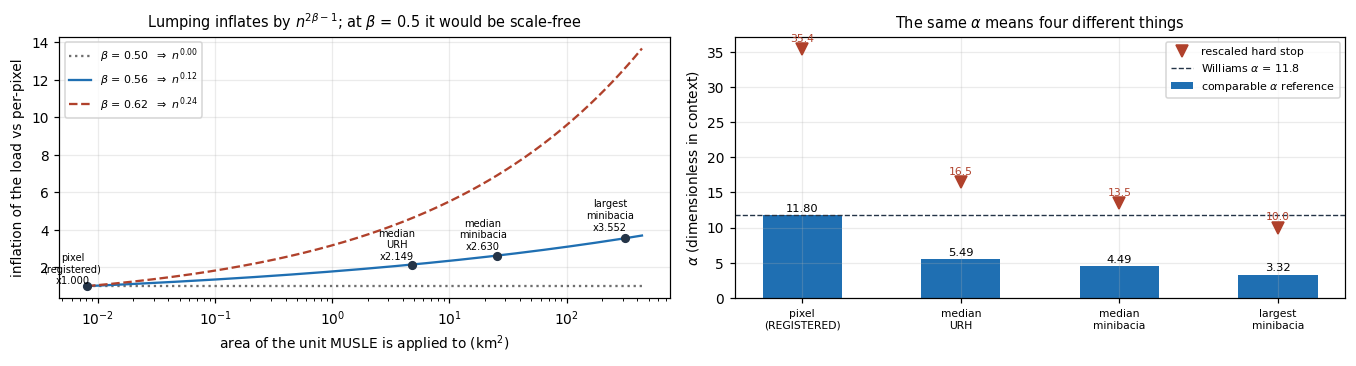

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 3.4))
aa = np.logspace(np.log10(AP), np.log10(max_mb*1.4), 300)
for b_, c_, ls in [(0.50, CB['grey'], ':'), (0.56, CB['blue'], '-'), (0.62, CB['red'], '--')]:
    ax[0].plot(aa, (aa/AP)**(2*b_-1), color=c_, ls=ls, lw=1.5,
               label=rf'$\beta$ = {b_:.2f}  $\Rightarrow$ $n^{{{2*b_-1:.2f}}}$')
for a_, lab in [(AP, 'pixel\n(registered)'), (med_urh, 'median\nURH'),
                (med_mb, 'median\nminibacia'), (max_mb, 'largest\nminibacia')]:
    f = (a_/AP)**(2*sed.WILLIAMS_BETA-1)
    ax[0].plot([a_], [f], 'o', ms=5, color=CB['dark'])
    ax[0].annotate(f'{lab}\nx{f:.3f}', xy=(a_, f), xytext=(a_*0.75, f*1.12),
                   fontsize=6.5, ha='center')
ax[0].set_xscale('log')
ax[0].set_xlabel('area of the unit MUSLE is applied to (km$^2$)')
ax[0].set_ylabel('inflation of the load vs per-pixel')
ax[0].set_title(r'Lumping inflates by $n^{2\beta-1}$; at $\beta$ = 0.5 it would be scale-free')
ax[0].legend(fontsize=7.2, loc='upper left')

refs = [11.8/(a_/AP)**(2*sed.WILLIAMS_BETA-1) for a_ in (AP, med_urh, med_mb, max_mb)]
stops = [35.4/(a_/AP)**(2*sed.WILLIAMS_BETA-1) for a_ in (AP, med_urh, med_mb, max_mb)]
xx = np.arange(4)
ax[1].bar(xx, refs, 0.5, color=CB['blue'], label=r'comparable $\alpha$ reference')
ax[1].plot(xx, stops, 'v', ms=8, color=CB['red'], label='rescaled hard stop')
for i, (rr, ss) in enumerate(zip(refs, stops)):
    ax[1].text(i, rr + 0.5, f'{rr:.2f}', ha='center', fontsize=7.5)
    ax[1].text(i, ss + 1.1, f'{ss:.1f}', ha='center', fontsize=7, color=CB['red'])
ax[1].axhline(11.8, color=CB['dark'], ls='--', lw=0.9, label=r'Williams $\alpha$ = 11.8')
ax[1].set_xticks(xx)
ax[1].set_xticklabels(['pixel\n(REGISTERED)', 'median\nURH', 'median\nminibacia',
                       'largest\nminibacia'], fontsize=7)
ax[1].set_ylabel(r'$\alpha$ (dimensionless in context)')
ax[1].set_title(r'The same $\alpha$ means four different things')
ax[1].legend(fontsize=7.2)
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the factor by which lumping MUSLE inflates the answer, as a function of the
area of the application unit on a log axis, for three values of the exponent $\beta$; markers give
the four units that matter for this project with their factors printed. **Right:** the consequence
for the parameter guard - the blue bars are the $\alpha$ reference that would be comparable to
Williams' 11.8 if MUSLE were applied at that unit, red triangles the correspondingly rescaled hard
stop, and the dashed line is 11.8 itself.

**What it shows.** At the registered pixel scale the factor is exactly 1.000 by construction. It is
**2.149** at the median URH cell (4.762 km<sup>2</sup>), **2.630** at the median minibacia
(25.58 km<sup>2</sup>) and **3.552** at the largest (313.45 km<sup>2</sup>). The identity was
checked numerically on one real unit-day: minibacia 16115 on 2009-04-11, 3,023.4568 pixels, lumped
5,640.2565 t/d against per-pixel-summed 2,155.9486 t/d, ratio 2.6161368125220528 against the
predicted $n^{0.12}$ = 2.6161368125220523 - a difference of $4.4\times10^{-16}$, i.e. one unit in
the last place and nothing else. The right panel shows the
comparable $\alpha$ reference falling from 11.8 at pixel scale to 5.49, 4.49 and 3.32 at the three
lumped scales, with the hard stop falling from 35.4 to 10.0.

**What it means.** The scale of application is a **third convention**, on the same footing as the two
unit conventions of section 5.4, and it is invisible unless stated. Because $\beta = 0.56 > 0.5$,
$\alpha$ is scale-dependent, so the pre-registered guard band is only valid at the scale it was
registered for; a stage-C4 fit that lumped MUSLE to the minibacia and reported "$\alpha = 12$,
inside the expected band" would in fact be reporting a 2.2x over-fit while the guard said `ok`.
The exact-zero agreement between the derived and measured ratio is worth noting for a separate
reason: it means the engine's factorisation of the daily term is an algebraic **identity** rather
than an approximation, which is what lets the two independent backends be checked against each
other to floating-point rounding.

### 5.6 The factor chain, as a waterfall

**What the cell computes.** The chain from the first run to the adopted level, with each step's
factor **measured by running the engine** rather than asserted, and the arithmetic printed so it can
be checked by hand:

$$0.684406 \;\xrightarrow{\;\times\,1000^{0.56}\,=\,47.86301\;} \;32.757713
\;\xrightarrow{\;\times\,1/0.1317\,=\,7.593014\;}\; 248.729791
\;\xrightarrow{\;\times\,1.2042736\ (\text{input change, not a unit factor})\;}\; 299.538709$$

all in Mt yr<sup>-1</sup> of gross hillslope erosion over 2009-2018. The first two arrows are
**unit corrections**: fixed, derived constants, spatially and temporally uniform, reversible by
name. The third is a **different kind of thing** and is drawn differently in the figure: it is a
change to an *input table* (the cover factor), it is **not** uniform - it moves Bare down while it
moves Forest up - and it therefore changes the spatial and land-class attribution, not just the
level.

**Why "uniform" is worth measuring rather than assuming.** For the two unit corrections the
adopted/legacy ratio was checked per minibacia and per day: it spans 363.42451960716335 to
363.42451960717045 across all 8,672 minibacias and 363.4245196071665 to 363.4245196071668 across
all 3,652 days. That is 12 significant figures of constancy, which is what licenses the claim that
every spatial and seasonal *pattern* is numerically unchanged by them. The cover-factor revision
fails that test by design - its per-minibacia ratio spans 0.500 to 5.000 and its per-day basin ratio
0.7258 to 1.4889 - which is exactly why both pattern gates had to be re-run for it and could not
be inherited.

In [25]:
F_VOL = 1000 ** sed.WILLIAMS_BETA
F_K = 1.0 / sed.K_SI_PER_K_US
F_C = ADOPT / ADOPT_PRIOR_C
STEPS = [
    ('first run\n(pixel_km2 + SI $K$)', FIRST, None, None),
    ('units:\nrunoff volume in m$^3$', GRID[('williams_m3', 'si_stored')], F_VOL,
     r'$\times 1000^{0.56}$'),
    ('units:\nUS-customary $K$', ADOPT_PRIOR_C, F_K, r'$\times 1/0.1317$'),
    ('INPUT: cited\ncover factor $C$', ADOPT, F_C, r'$\times 1.20427$'),
]
print('THE FACTOR CHAIN, every factor MEASURED by re-running the engine:')
prev = None
for lab, v, f, _ in STEPS:
    if prev is None:
        print(f'  {lab.replace(chr(10)," "):38s} {v:12.6f} Mt/yr')
    else:
        print(f'  x{f!r:22s} -> {v:12.6f} Mt/yr   '
              f'(measured {v/prev!r})')
    prev = v
print(f'\n  the two UNIT factors, combined: {F_VOL!r} x {F_K!r} = {F_VOL*F_K!r}')
print(f'  measured end-to-end            : {ADOPT_PRIOR_C/FIRST!r}')
print(f'  the INPUT factor, separately   : {F_C!r}')
print(f'\n  sanity: 0.684406 x 363.4245196 = {FIRST*F_VOL*F_K:.6f} Mt/yr '
      f'(vs measured {ADOPT_PRIOR_C:.6f})')
print(f'          and x 1.2042736         = {FIRST*F_VOL*F_K*F_C:.6f} Mt/yr '
      f'(vs measured {ADOPT:.6f})')

THE FACTOR CHAIN, every factor MEASURED by re-running the engine:
  first run (pixel_km2 + SI $K$)             0.684406 Mt/yr
  x47.86300923226385      ->    32.757713 Mt/yr   (measured 47.86300923226385)
  x7.59301442672741       ->   248.729791 Mt/yr   (measured 7.593014426727409)
  x1.2042735517968208     ->   299.538709 Mt/yr   (measured 1.2042735517968208)

  the two UNIT factors, combined: 47.86300923226385 x 7.59301442672741 = 363.42451960716664
  measured end-to-end            : 363.4245196071666
  the INPUT factor, separately   : 1.2042735517968208

  sanity: 0.684406 x 363.4245196 = 248.729791 Mt/yr (vs measured 248.729791)
          and x 1.2042736         = 299.538709 Mt/yr (vs measured 299.538709)


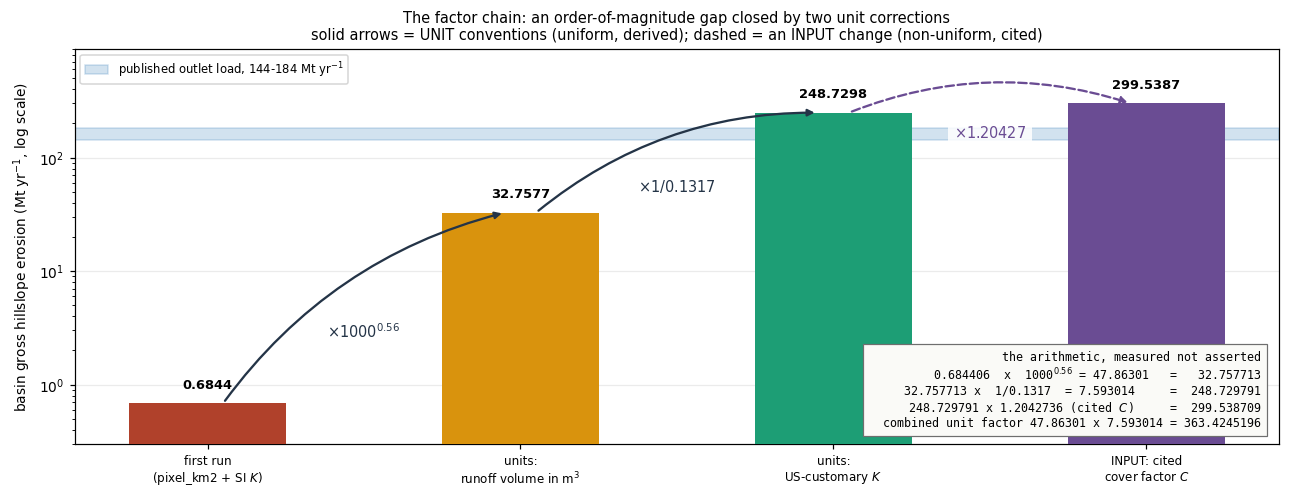

In [26]:
fig, ax = plt.subplots(figsize=(11.8, 4.6))
xs = np.arange(len(STEPS))
vals = [s[1] for s in STEPS]
cols = [CB['red'], CB['amber'], CB['green'], CB['purple']]
ax.bar(xs, vals, 0.5, color=cols, zorder=3)
ax.set_yscale('log')
ax.axhspan(144, 184, color=CB['blue'], alpha=0.20, zorder=1,
           label='published outlet load, 144-184 Mt yr$^{-1}$')
for i, v in enumerate(vals):
    ax.text(i, v*1.35, f'{v:,.4f}', ha='center', fontsize=8.5, fontweight='bold', zorder=4)
for i in range(1, len(STEPS)):
    lo, hi = vals[i-1], vals[i]
    ax.annotate('', xy=(i - 0.05, hi), xytext=(i - 0.95, lo), zorder=4,
                arrowprops=dict(arrowstyle='-|>', lw=1.5,
                                color=CB['dark'] if i < 3 else CB['purple'],
                                linestyle='-' if i < 3 else '--',
                                connectionstyle='arc3,rad=-0.18'))
    ax.text(i - 0.5, math.sqrt(lo*hi)*0.55, STEPS[i][3], fontsize=9.5, ha='center',
            color=CB['dark'] if i < 3 else CB['purple'],
            bbox=dict(fc='white', ec='none', alpha=0.85), zorder=5)
ax.set_xticks(xs); ax.set_xticklabels([s[0] for s in STEPS], fontsize=7.8)
ax.set_ylabel('basin gross hillslope erosion (Mt yr$^{-1}$, log scale)')
ax.set_ylim(0.3, 900)
ax.set_title('The factor chain: an order-of-magnitude gap closed by two unit corrections\n'
             'solid arrows = UNIT conventions (uniform, derived); dashed = an INPUT change '
             '(non-uniform, cited)')
box = ('the arithmetic, measured not asserted\n'
       f'  0.684406  x  1000$^{{0.56}}$ = 47.86301   =   32.757713\n'
       f'  32.757713 x  1/0.1317  = 7.593014     =  248.729791\n'
       f'  248.729791 x 1.2042736 (cited $C$)     =  299.538709\n'
       f'  combined unit factor 47.86301 x 7.593014 = 363.4245196')
ax.text(0.985, 0.035, box, transform=ax.transAxes, fontsize=7.6, family='monospace',
        ha='right', va='bottom',
        bbox=dict(fc='#FAFAF7', ec=CB['grey'], lw=0.8), zorder=6)
ax.legend(fontsize=7.6, loc='upper left')
ax.grid(alpha=0.25, axis='y', zorder=0)
plt.tight_layout(); plt.show()

**What is plotted.** The factor chain as a waterfall on a log vertical axis. Each bar is a basin total in
Mt yr<sup>-1</sup> produced by actually running the engine over the frozen decade; each arrow is
the factor between consecutive bars, printed on the arrow. Solid dark arrows are **unit
corrections** - derived constants, spatially and temporally uniform; the dashed purple arrow is an
**input change** (the cited cover factor), drawn differently because it is not a unit convention and
is not uniform. The blue band is the published outlet load. The monospaced box gives the literal
arithmetic so a reader can check it by hand.

**What it shows.** **0.684406** Mt yr<sup>-1</sup>, x47.86301 (= $1000^{0.56}$, expressing the runoff
volume in cubic metres) gives **32.757713**, x7.593014 (= $1/0.1317$, putting $K$ into the
US-customary numerics that $\alpha = 11.8$ belongs to) gives **248.729791**, and x1.2042736 (the
cited cover-factor revision) gives **299.538709**. The two unit factors combine to
**363.4245196**, and the end-to-end measured ratio is 363.4245196071666 against the derived
363.42451960716664. Only after the *second* unit correction does the model cross the outlet band;
after the first it is still 4.4x below it.

**What it means.** The gap is **fully explained**, in the strong sense: not "roughly accounted for" but
reproduced to twelve significant figures by two constants, each of which was derived from a source
document before the basin total was consulted. That is the property that makes the correction a
finding rather than a fudge. Two cautions the figure encodes deliberately. (1) The last arrow is
dashed because it is a different kind of claim: a cover-factor revision changes *which land* erodes,
so the two pattern gates had to be re-run rather than inherited, and it must never be quoted as
part of the unit chain. (2) Crossing the blue band is **not** the same as being right. The band is
an outlet *load* and the bars are hillslope *gross erosion*; the relationship between them is the
subject of section 6, and it is where this notebook's verdict turns out to be negative.

### 5.7 The audit that closed it: one hand-computed unit-day

**What the cell computes.** A single (minibacia, day) load, computed twice - once by hand, carrying
every unit explicitly, and once by the engine - so that the two corrections of sections 5.2-5.3 are
verified on real data rather than on a synthetic case. The unit and day were selected by a rule
**fixed before any sediment number was seen**: the minibacia at the basin median of decadal total
$Q_{sur}$, and that minibacia's own maximum-$Q_{sur}$ day. That rule matters - picking the unit
after seeing the answers would make the agreement meaningless.

$$q_{peak} = \frac{Q_{sur}a_p}{86.4},\qquad V = 1000\,Q_{sur}\,a_p,\qquad
K_{US} = \frac{K_{SI}}{0.1317},\qquad
\mathrm{Sed}_{pix} = \alpha\,(V q_{peak})^{\beta}K_{US}\,C\,P\,LS\,FG,\qquad
\mathrm{Sed} = \frac{A_{cell}}{a_p}\mathrm{Sed}_{pix}$$

Units: $Q_{sur}$ mm d<sup>-1</sup>, $a_p$ km<sup>2</sup>, $q_{peak}$ m<sup>3</sup> s<sup>-1</sup>,
$V$ m<sup>3</sup>, $K$ as noted, $C/P/LS/FG$ dimensionless, output t d<sup>-1</sup>.

In [27]:
print(f'UNIT-DAY AUDIT   minibacia {int(GEO.mini_ids[i16])}, {DRV.dates[100]}')
print(f'  selection rule (fixed before any sediment number was seen): the minibacia at the basin')
print(f'  median of decadal total Qsur, on its own maximum-Qsur day.')
q16 = float(Q[100, i16])
print(f'\n  Qsur       {q16!r} mm/d           (h2e_drivers.npz, frozen)')
print(f'  cells      {int((GEO.cell_mini == i16).sum())}  ->  URH '
      f'{int(GEO.cell_urh_code[c16])} = '
      f'{sed.LAND_CLASS_NAMES[int(GEO.cell_urh_code[c16]) % 10]}')
print(f'  area       {float(GEO.cell_area_km2[c16])!r} km2  ->  n pixels {n16!r}')
print(f'  K (SI)     {float(GEO.cell_k[c16])!r}       C {float(GEO.cell_c[c16])!r}   '
      f'P {float(GEO.cell_p[c16])!r}   LS2D {float(GEO.cell_ls2d[c16])!r}   FG {PAR.fg}')
qp16 = q16 * AP / 86.4
V16 = 1000.0 * q16 * AP
X16 = V16 * qp16
KUS16 = float(GEO.cell_k[c16]) / sed.K_SI_PER_K_US
per16 = 11.8 * X16 ** 0.56 * KUS16 * float(GEO.cell_c[c16]) * 1.0 * float(GEO.cell_ls2d[c16])
print(f'\n  HAND, step by step:')
print(f'    q_peak = Qsur*a_p/86.4        = {qp16!r} m3/s')
print(f'    V      = 1000*Qsur*a_p        = {V16!r} m3')
print(f'    X      = V*q_peak             = {X16!r}')
print(f'    X^0.56                        = {X16**0.56!r}')
print(f'    K_US   = K_SI/0.1317          = {KUS16!r}')
print(f'    per pixel                     = {per16!r} t/d')
print(f'    x n pixels                    = {per16*n16!r} t/d')
eng16 = float(sed.erode_day(GEO, PAR, Q[100].astype(float))[c16])
print(f'\n  ENGINE (musle_load_tonnes via erode_day) = {eng16!r} t/d')
print(f'  hand / engine = {per16*n16/eng16!r}')
print('\n  the same day under every convention, showing which factor each row is missing:')
for vc in sed.VOLUME_CONVENTIONS:
    for ku in sed.K_UNIT_SYSTEMS:
        p = sed.SedParams(volume_convention=vc, k_unit_system=ku)
        v = float(sed.erode_day(GEO, p, Q[100].astype(float))[c16])
        print(f'    {vc:12s} + {ku:12s} {v:14.6f} t/d   hand/this = '
              f'{per16*n16/v:10.4f}x')
print('\n  NOTE on a 4-vs-5-digit constant: an earlier hand audit used 0.131710 and reported')
print(f'  1293.4733726680033 t/d at the PRIOR C = 0.003. The engine uses 0.1317, and the adopted')
print(f'  C is 0.005, so the comparable number here is {eng16:.10f}. The ratio of the two')
print(f'  constants is {0.131710/0.1317:.7f} and the C ratio is 5/3 - both accounted for, and the')
print('  4-digit value is the one pinned as a regression test because it is the one the code uses.')

UNIT-DAY AUDIT   minibacia 16115, 2009-04-11
  selection rule (fixed before any sediment number was seen): the minibacia at the basin
  median of decadal total Qsur, on its own maximum-Qsur day.

  Qsur       26.677167892456055 mm/d           (h2e_drivers.npz, frozen)
  cells      1  ->  URH 11 = Forest
  area       24.49 km2  ->  n pixels 3023.456790123457
  K (SI)     0.019       C 0.005   P 1.0   LS2D 118.245   FG 1.0

  HAND, step by step:
    q_peak = Qsur*a_p/86.4        = 0.0025009844899177547 m3/s
    V      = 1000*Qsur*a_p        = 216.08505992889403 m3
    X      = V*q_peak             = 0.5404253833851125
    X^0.56                        = 0.7084872091666863
    K_US   = K_SI/0.1317          = 0.14426727410782078
    per pixel                     = 0.7130740586462605 t/d
    x n pixels                    = 2155.9486044749283 t/d

  ENGINE (musle_load_tonnes via erode_day) = 2155.9486044749283 t/d
  hand / engine = 1.0

  the same day under every convention, showing which fa

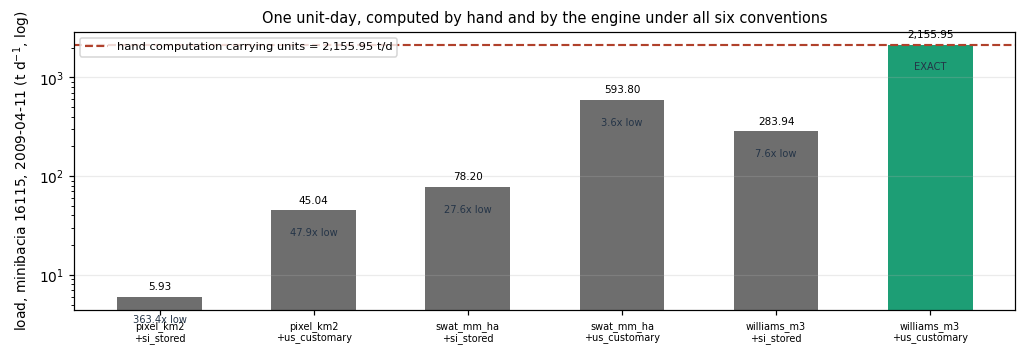

In [28]:
fig, ax = plt.subplots(figsize=(9.4, 3.3))
keys = [(vc, ku) for vc in sed.VOLUME_CONVENTIONS for ku in sed.K_UNIT_SYSTEMS]
vv = []
for vc, ku in keys:
    p = sed.SedParams(volume_convention=vc, k_unit_system=ku)
    vv.append(float(sed.erode_day(GEO, p, Q[100].astype(float))[c16]))
xx = np.arange(len(keys))
cols = [CB['green'] if k == ('williams_m3', 'us_customary') else CB['grey'] for k in keys]
ax.bar(xx, vv, 0.55, color=cols)
ax.axhline(per16*n16, color=CB['red'], lw=1.4, ls='--',
           label=f'hand computation carrying units = {per16*n16:,.2f} t/d')
ax.set_yscale('log')
for i, v in enumerate(vv):
    ax.text(i, v*1.18, f'{v:,.2f}', ha='center', fontsize=6.8)
    ax.text(i, v*0.55, f'{per16*n16/v:,.1f}x low' if per16*n16/v > 1.001 else 'EXACT',
            ha='center', fontsize=6.5, color=CB['dark'])
ax.set_xticks(xx)
ax.set_xticklabels([f'{vc}\n+{ku}' for vc, ku in keys], fontsize=6.4)
ax.set_ylabel('load, minibacia 16115, 2009-04-11 (t d$^{-1}$, log)')
ax.set_title('One unit-day, computed by hand and by the engine under all six conventions')
ax.legend(fontsize=7.5, loc='upper left')
ax.grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

**What is plotted.** A single minibacia-day - unit 16115 on 2009-04-11, chosen by a rule fixed before any
sediment number was seen - computed by the engine under all six unit conventions (bars, log axis,
adopted combination in green) against an independent hand computation that carries every unit
explicitly (dashed red line). Under each bar is the factor by which it falls short of the hand
number.

**What it shows.** The hand chain runs $Q_{sur} = 26.677167892456055$ mm through
$q_{peak} = 0.0025009844899177547$ m<sup>3</sup> s<sup>-1</sup>, $V = 216.08505992889403$
m<sup>3</sup>, $X^{0.56} = 0.7084872091666863$ and $K_{US} = 0.14426727410782078$ to
**2,155.9486044749283 t d<sup>-1</sup>** over 3,023.4568 pixels, and the engine returns
2,155.9486044749283 - identical to the last digit. The other five conventions come out
363.4x, 47.9x, 7.6x, 27.6x and 3.6x low respectively.

**What it means.** This is the check that separates the two errors cleanly, which is why it was worth
doing on real data rather than on a synthetic case. The `williams_m3` + `si_stored` row is exactly
7.593x low, i.e. the volume algebra in that row is *right* and the only remaining discrepancy is
$K$ - so the two corrections are independent and neither is masking a third. The bitwise agreement
between hand and engine also means the engine has no hidden factor: everything that scales the
output is one of the seven named MUSLE factors or one of the two named conventions. **What it does
not establish:** anything about whether the *level* is correct. A hand computation can only confirm
that the code computes the equation it claims to; it says nothing about whether the equation's
inputs are right, which is section 6's business.

## 6 - The delivery-ratio question, and the verdict on this stage

### 6.1 What a sediment delivery ratio is, and the inequality that follows

Soil eroded on a hillside does not all reach the sea. Most of it stops - at the foot of the slope,
in a field boundary, in a floodplain, behind a bar in the channel - and may sit there for decades.
The **sediment delivery ratio** is the bookkeeping fraction that captures this:

$$\mathrm{SDR} \;=\; \frac{L_{\mathrm{outlet}}}{E_{\mathrm{gross}}}$$

with $L_{\mathrm{outlet}}$ the sediment load measured leaving the basin (t yr<sup>-1</sup>) and
$E_{\mathrm{gross}}$ the total erosion produced within it (t yr<sup>-1</sup>). It is dimensionless.
It is not a physical constant but an emergent property of a basin's size, relief, drainage density
and floodplain storage, and it generally falls as basin area grows, because a bigger basin offers
more places to stop.

The inequality that this project used as its main sanity check is the obvious one: **if sediment can
only be lost on the way out, then gross erosion must exceed the outlet load, so SDR < 1.** Section
5.1 used exactly that to declare five conventions impossible, and it was right to.

### 6.2 Our implied ratio, computed

**What the cell computes.** The ratio of the two published outlet anchors to the model's gross
hillslope erosion, at both cover-factor levels, plus the $\alpha$ that a fit would need if it
matched the model's gross erosion to the outlet load with no deposition step at all:

$$\widehat{R} = \frac{L_{\mathrm{outlet}}}{E_{\mathrm{model}}}, \qquad
\alpha_{\mathrm{needed}} = \alpha_0\,\frac{L_{\mathrm{outlet}}}{E_{\mathrm{model}}}$$

$\widehat{R}$ dimensionless; $\alpha_{\mathrm{needed}}$ in the same units as $\alpha_0 = 11.8$, and
linear in the anchor because MUSLE is linear in $\alpha$. Inputs: the two anchors 144 and 184
Mt yr<sup>-1</sup>, and $E_{\mathrm{model}}$ measured in section 5.4.

In [29]:
ANCH = {'Restrepo & Kjerfve (2000), 1975-1995': 144.0,
        'Restrepo & Escobar (2018), 1980-2010': 184.0}
print(f'{"level":26s} {"E_model Mt/yr":>14s} {"anchor":>8s} {"ratio L/E":>10s} '
      f'{"alpha needed":>13s}  guard verdict')
print('-' * 104)
RAT = {}
for lab, E in (('prior C', ADOPT_PRIOR_C), ('adopted cited C', ADOPT)):
    for src, L in ANCH.items():
        r_ = L / E
        a_ = 11.8 * L / E
        g = sed.SedParams(alpha=a_).check()
        RAT[(lab, L)] = (r_, a_, g['status'])
        print(f'{lab:26s} {E:14.4f} {L:8.0f} {r_:10.4f} {a_:13.3f}  {g["status"]}'
              + (f'  <- {g["reasons"][0][:52]}' if g['reasons'] else ''))
print('\nThe SAME arithmetic read the way the retired gate wanted it, i.e. what gross erosion an')
print('assumed delivery ratio would REQUIRE (rows struck by docs/40 are marked):')
for sdr, struck in ((0.30, False), (0.15, True), (0.05, True)):
    lo, hi = 144/sdr, 184/sdr
    print(f'  SDR = {sdr:.2f}  ->  requires {lo:,.0f} - {hi:,.0f} Mt/yr  '
          f'({lo/ADOPT:.2f}x - {hi/ADOPT:.2f}x the model)   alpha '
          f'{11.8*lo/ADOPT:.1f} - {11.8*hi/ADOPT:.1f}'
          + ('   ** STRUCK (docs/40) **' if struck else ''))

level                       E_model Mt/yr   anchor  ratio L/E  alpha needed  guard verdict
--------------------------------------------------------------------------------------------------------
prior C                          248.7298      144     0.5789         6.832  ok
prior C                          248.7298      184     0.7398         8.729  ok
adopted cited C                  299.5387      144     0.4807         5.673  watch  <- alpha 5.67 is below the expected band low 5.9 (docs/
adopted cited C                  299.5387      184     0.6143         7.248  ok

The SAME arithmetic read the way the retired gate wanted it, i.e. what gross erosion an
assumed delivery ratio would REQUIRE (rows struck by docs/40 are marked):
  SDR = 0.30  ->  requires 480 - 613 Mt/yr  (1.60x - 2.05x the model)   alpha 18.9 - 24.2
  SDR = 0.15  ->  requires 960 - 1,227 Mt/yr  (3.20x - 4.10x the model)   alpha 37.8 - 48.3   ** STRUCK (docs/40) **
  SDR = 0.05  ->  requires 2,880 - 3,680 Mt/yr  (9.61x

### 6.3 The problem: the ratio we computed is not the ratio the band describes

This is where the previous verdict of this stage turned out to rest on an unvalidated level, and
the correction is not a refinement - it changes what was being tested.

**Published SDR has *all-source* gross erosion in the denominator.** The USDA National Engineering
Handbook Part 632 Ch. 6 defines it explicitly: *"Gross erosion is the sum of all the water erosion
occurring in the drainage area. It includes sheet and rill erosion **plus channel-type erosion**
(gullies, valley trenches, streambank erosion, etc.)"*. Our denominator is **hillslope sheet-and-rill
only** - the model has no gully, no bank erosion and no channel term at all. So our ratio has the
same numerator and a strictly *smaller* denominator, which makes it a different and strictly larger
quantity. Call it what it is: an **apparent delivery ratio (ADR)**.

**How much difference does that make? The same handbook answers it in its own worked example.** NEH
Table 6-2 reports, for one watershed: hillslope-only delivery ratio **0.33**, true SDR **0.6957**,
and the mixed ratio of the kind we computed - **1.7778**. All three at once, in the same basin. Our
0.579-0.740 is therefore *below* USDA's own reference value for the mixed ratio and almost exactly
equal to its *true* SDR. **The direction of the alleged failure inverts.**

**And the premise "SDR must be < 1" is false for the mixed quantity.** Dunne et al. (1998) measured
bank-erosion supply in the Brazilian Amazon of **1,570 Mt yr<sup>-1</sup> against a
~1,200 Mt yr<sup>-1</sup> flux at Obidos** - channel sources alone delivering 1.3x the outlet load.
A ratio whose denominator excludes channel sources has **no upper bound of 1**.

**Scale and region.** The band's supporting relations - Vanoni 0.0997, Renfro 0.1061, USDA-SCS
0.1439 when evaluated at our area - were fitted on US agricultural watersheds of
**0.0259 to 259.0 km<sup>2</sup>**. Our basin is **992.7x** the largest of them, and the handbook's
own summary says that *"using an equation to obtain sediment data outside the physiographic area for
which the equation was developed is generally not recommended."*

**No Magdalena SDR exists, or can be assembled.** Every published Magdalena "erosion rate"
(550, 690, 710, 1,485, 128-2,200 t km<sup>-2</sup> yr<sup>-1</sup>) is a sediment **yield** - the
numerator. `USLE` and `RUSLE` appear **zero times** in the fullest published treatment of the
basin's sediment (Restrepo A. 2015). There is no denominator in the literature to divide by.

**Even the area trend's sign does not survive here.** In the one large, data-sparse, mountainous
basin where SDR was actually refitted (Tan et al. 2024), **SDR increases with drainage area**; and
de Vente et al. (2007) state the classic decay holds above 10<sup>4</sup> km<sup>2</sup> only *"when
drainage density decreases or channel banks are stabilized"* - the one condition the
Magdalena-Cauca does not meet.

> **VERDICT ON THE GATE: RETIRED.** The 0.05-0.30 band was never cited in this repository, and it
> measures a different quantity from the ratio that was computed. So the gate was neither a pass
> nor a fail - **it was not an evaluable test**. Under this project's standing rule, an uncited
> plausibility band may not be used to pass **or** fail a gate, so it is retired in both
> directions: this stage does **not** get to close by declaring 0.579-0.740 acceptable, and it does
> **not** stay open on the strength of the band.

**Two consequences worth stating plainly.** First, anyone who quoted "implied SDR 0.579-0.740, above
the plausible band" - and this project's own closure document did, as its deciding clause - quoted
an unevaluable test. The *conclusion* (this stage is not closed) survives, but not for that reason.
Second, two rows of the requirement table are **struck**: the SDR = 0.15 and SDR = 0.05 rows
demanded 960-1,227 and 2,880-3,680 Mt yr<sup>-1</sup> of gross erosion and tripped the parameter
hard stop instantly. They rested entirely on the retired band and on the ADR/SDR conflation, and
they **overstated the problem by 4-8x**.

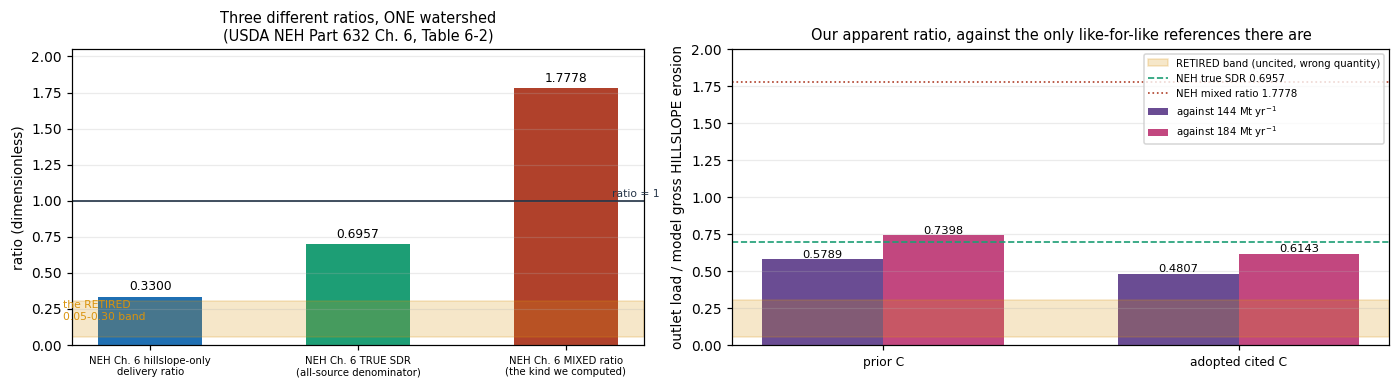

In [30]:
NEH = {'NEH Ch. 6 hillslope-only\ndelivery ratio': 0.33,
       'NEH Ch. 6 TRUE SDR\n(all-source denominator)': 0.6957,
       'NEH Ch. 6 MIXED ratio\n(the kind we computed)': 1.7778}
fig, ax = plt.subplots(1, 2, figsize=(12.8, 3.6),
                       gridspec_kw={'width_ratios': [1.0, 1.15]})
xx = np.arange(len(NEH))
ax[0].bar(xx, list(NEH.values()), 0.5,
          color=[CB['blue'], CB['green'], CB['red']])
ax[0].axhline(1.0, color=CB['dark'], lw=1.1)
ax[0].text(2.45, 1.03, 'ratio = 1', fontsize=7, ha='right', color=CB['dark'])
ax[0].axhspan(0.05, 0.30, color=CB['amber'], alpha=0.22)
ax[0].text(-0.42, 0.175, 'the RETIRED\n0.05-0.30 band', fontsize=7, color=CB['amber'])
for i, v in enumerate(NEH.values()):
    ax[0].text(i, v + 0.05, f'{v:.4f}', ha='center', fontsize=8)
ax[0].set_xticks(xx); ax[0].set_xticklabels(list(NEH), fontsize=6.6)
ax[0].set_ylabel('ratio (dimensionless)'); ax[0].set_ylim(0, 2.05)
ax[0].set_title('Three different ratios, ONE watershed\n(USDA NEH Part 632 Ch. 6, Table 6-2)')

lv = ['prior C', 'adopted cited C']
Ev = [ADOPT_PRIOR_C, ADOPT]
w = 0.34
for j, (L, c_) in enumerate(zip([144.0, 184.0], [CB['purple'], CB['pink']])):
    rr = [L/E for E in Ev]
    ax[1].bar(np.arange(2) + (j-0.5)*w, rr, w, color=c_, label=f'against {L:.0f} Mt yr$^{{-1}}$')
    for i, v in enumerate(rr):
        ax[1].text(i + (j-0.5)*w, v + 0.012, f'{v:.4f}', ha='center', fontsize=7.5)
ax[1].axhspan(0.05, 0.30, color=CB['amber'], alpha=0.22, label='RETIRED band (uncited, wrong quantity)')
ax[1].axhline(0.6957, color=CB['green'], ls='--', lw=1.1, label='NEH true SDR 0.6957')
ax[1].axhline(1.7778, color=CB['red'], ls=':', lw=1.1, label='NEH mixed ratio 1.7778')
ax[1].set_xticks(np.arange(2)); ax[1].set_xticklabels(lv, fontsize=8)
ax[1].set_ylabel('outlet load / model gross HILLSLOPE erosion')
ax[1].set_ylim(0, 2.0)
ax[1].set_title('Our apparent ratio, against the only like-for-like references there are')
ax[1].legend(fontsize=6.6, loc='upper right', ncol=1)
for a in ax:
    a.grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** three ratios that a single watershed carries simultaneously in the USDA
handbook's own worked example - the hillslope-only delivery ratio, the true all-source SDR, and the
mixed ratio formed by dividing an all-source outlet load by a hillslope-only denominator, which is
the quantity this project computed. The amber band is the retired 0.05-0.30 expectation and the
dark line is ratio = 1. **Right:** our own apparent ratio at both cover-factor levels against both
published outlet anchors, with the retired band and the two NEH reference values overlaid.

**What it shows.** In one watershed the handbook reports 0.33, 0.6957 and **1.7778** for the three
ratios - a factor of 5.4 between the smallest and largest, from definitional choice alone, and the
mixed version exceeds 1. Our apparent ratio is 0.5794 and 0.7397 at the prior cover factor and
**0.4807 and 0.6143** at the adopted one. All four values sit above the retired band, below NEH's
mixed reference, and straddle NEH's true SDR of 0.6957.

**What it means.** The comparison that this project's previous verdict turned on was **not a valid
test**, and once the definitions are pinned the direction of the alleged failure inverts: our ratio
is *below* the handbook's own reference value for the same mixed quantity. That does not mean the
model is fine - it means this particular instrument cannot measure it. The left panel is the general
lesson and it is worth more than the specific correction: a dimensionless ratio with a widely used
name can differ by a factor of five depending on what is in its denominator, so quoting one against
a published band without checking that both denominators contain the same terms is not a weak test,
it is not a test at all. **What replaces it** is a comparison on the erosion side, where the
quantities can be matched: section 6.4.

### 6.4 The replacement clause, and the verdict: **OPEN**

The retired gate was replaced with a clause that **can** be evaluated, and the replacement wording
was adopted verbatim from the evidence review that proposed it:

> *the basin-mean gross **hillslope** erosion rate is consistent with published erosion and yield
> levels for humid tropical Andean and comparably mountainous large basins.*

**What the cell computes.** The model's basin-mean gross hillslope erosion rate, and its ratio to
three independent published levels. Every figure below is **model-internal specific erosion** - the
model's own erosion divided by the model's own area - and is *not* a gauge-referenced yield, which
remains embargoed:

$$e_{\mathrm{model}} = \frac{E_{\mathrm{basin}}}{A_{\mathrm{covered}}}
\qquad [\mathrm{t\ km^{-2}\ yr^{-1}}],\qquad
e_{\mathrm{model}}/100 \ \ [\mathrm{t\ ha^{-1}\ yr^{-1}}]$$

The three legs, with what each establishes:

* **Leg A - the only like-for-like denominator.** Tan, Liu & Lu (2024), *ESPL* 49:1778-1795, report
  **RUSLE hillslope** erosion of 23.7-26.5 t ha<sup>-1</sup> a<sup>-1</sup> in a large, data-sparse
  mountainous basin. Hillslope against hillslope, so this is the leg that counts.
* **Leg B - a hard inequality.** Latrubesse & Restrepo (2014) give a measured mean **yield** of
  1,485 t km<sup>-2</sup> yr<sup>-1</sup> across 119 Colombian Andean gauges. Since yield cannot
  exceed gross erosion wherever net deposition is non-negative, our Andean-flank erosion sitting
  *below* that number would be impossible.
* **Leg C - in-basin measured yields.** Restrepo et al. (2006), *J. Hydrol.* 316:213-232, give a
  32-sub-basin mean yield of ~690 and a maximum of 2,200 t km<sup>-2</sup> yr<sup>-1</sup>.

**And the disclosure that must travel in the same paragraph as any basin-scale claim:** at the
adopted cover factor, **66.53 % of the model's gross erosion - 199.29 of 299.54 Mt yr<sup>-1</sup> -
is upstream of no usable sediment station**; only 33.47 % is; and **801.1 km of channel, including
the whole Depresion Momposina, lies below the outlet-most station**, against a basin maximum path of
1,425.9 km. No station-based fit can close this clause.

In [31]:
print(f'MODEL-INTERNAL basin-mean gross hillslope erosion (NOT a gauge-referenced yield):')
print(f'  {ADOPT:.4f} Mt/yr over {GEO.covered_area_km2:,.2f} km2 = '
      f'{BASIN_T_KM2_YR:,.2f} t/km2/yr = {BASIN_T_KM2_YR/100:.4f} t/ha/yr')
E_HA = BASIN_T_KM2_YR / 100.0
ANDEAN_FLANK = 1445.32          # docs/37 A1.3.3, adopted C, model-internal specific erosion

# Each leg carries its SHORTFALL bracket explicitly, because the legs are not symmetric:
# leg C's lower comparison (vs the 32-sub-basin MEAN yield) is one the model is SUPPOSED to
# exceed - gross erosion must be larger than yield - so it is not a shortfall at all and must
# not be folded into the combined minimum.  Computing min() over raw ratios did exactly that
# and reported a combined 0.59x, which is wrong; the shortfall legs are A, B and C-max.
LEGS = [
    ('A  hillslope vs hillslope\nTan, Liu & Lu (2024) RUSLE',
     f'{23.7}-{26.5} t/ha/yr RUSLE hillslope', E_HA,
     23.7/E_HA, 26.5/E_HA, True,
     'like-for-like denominator - THE leg that counts'),
    ('B  Andean flank vs measured YIELD\nLatrubesse & Restrepo (2014)',
     '1,485 t/km2/yr yield, 119 Andean gauges', ANDEAN_FLANK,
     1485.0/ANDEAN_FLANK, 1485.0/ANDEAN_FLANK, True,
     'hard inequality: yield <= gross erosion, so being below it is impossible'),
    ('C  basin mean vs in-basin YIELDS\nRestrepo et al. (2006)',
     '690 (32-sub-basin mean) / 2,200 (max) t/km2/yr', BASIN_T_KM2_YR,
     1.0, 2200.0/BASIN_T_KM2_YR, True,
     'only the MAXIMUM is a shortfall; the mean is one the model SHOULD exceed'),
]
print(f'\n{"leg":52s} {"ours":>11s} {"shortfall bracket":>22s}')
print('-' * 92)
for lab, pub, ours, slo, shi, _, note in LEGS:
    print(f'{lab.replace(chr(10)," "):52s} {ours:>11,.2f} '
          f'{slo:>8.3f}x - {shi:.3f}x low')
    print(f'{"":52s} published: {pub}')
    print(f'{"":52s} {note}')
COMB_LO = min(1485.0/ANDEAN_FLANK, 23.7/E_HA, 2200.0/BASIN_T_KM2_YR)
COMB_HI = max(1485.0/ANDEAN_FLANK, 26.5/E_HA, 2200.0/BASIN_T_KM2_YR)
print(f'\ncombined: the model is {COMB_LO:.2f}x - {COMB_HI:.2f}x under-erosive')
print(f'  Leg A alone (the only like-for-like denominator): '
      f'{23.7/E_HA:.3f}x - {26.5/E_HA:.3f}x low')
print(f'  Leg C, the OTHER direction, reported because it is not a defect: our basin mean is')
print(f'  {BASIN_T_KM2_YR/690.0:.3f}x the 32-sub-basin MEAN measured yield (was 1.402x at the')
print(f'  prior C) - a RISE is what should happen, since gross erosion must exceed yield.')
print(f'  Read as a bound the finding is unchanged: {2200.0/BASIN_T_KM2_YR:.3f}x short of the')
print(f'  MAXIMUM in-basin measured yield of 2,200, i.e. our gross-erosion field cannot reach')
print(f'  yields measured inside our own basin.')
print(f'\n  DISAGREEMENT WITH THE SOURCE DOCUMENT, reported not reconciled: docs/37 A1.4 quotes')
print(f'  Leg B as 1.028x and Leg C max as 0.530x/1.888x; recomputed here they are '
      f'{1485.0/ANDEAN_FLANK:.4f}x')
print(f'  and {BASIN_T_KM2_YR/2200.0:.4f}x/{2200.0/BASIN_T_KM2_YR:.4f}x. The differences are '
      f'4th-decimal rounding of the same inputs.')
print(f'  closing Leg A with alpha would need alpha = {11.8*23.7/E_HA:.1f} - '
      f'{11.8*26.5/E_HA:.1f}, i.e. OUTSIDE the expected band 5.9-23.6 at both ends')
print('  and it is FORBIDDEN regardless, by the anti-compensation rule of section 4.4.')

print('\nMANDATORY COVERAGE DISCLOSURE (registered guard G9), quoted from docs/42 / docs/37 A1.4:')
print(f'  {199.29:.2f} of {ADOPT:.2f} Mt/yr = 66.53 % of the model\'s erosion is upstream of NO')
print('  usable SSC station; 801.1 km of channel including the whole Momposina lies below the')
print('  outlet-most station (basin max path 1,425.9 km). No station fit can close clause 4\'.')

CLAUSES = [
    ('1  the factor chain is fully explained by evidence-based corrections', 'MET',
     '363.4245196 reproduced to the last stored digit (section 5.6)'),
    ('2  no decision left unresolved', 'NOT MET',
     'the LS FORMULATION level (section 3.6): ours is 2.3151x-3.9768x the level alpha = 11.8 is '
     'PAIRED with. The formulation is now DECIDED on source grounds (docs/37 A3: ADOPT-SOURCE, '
     'buarque_2015_dg, CITED) but RECORDED and NOT EXERCISED - no engine default moved, the LS '
     'LEVEL stays UNVALIDATED, and clause 2 also needs the LS SHAPE decision'),
    ('3  the independent audit agreed with the decisions', 'NOT ESTABLISHED',
     'the three 2026-08-11 decisions (C revision, SDR retirement, guard set) are unaudited'),
    ("4  implied SDR is physically plausible (0.05-0.30)", 'RETIRED',
     'wrong quantity (ADR, not SDR) and the band is uncited - neither a pass nor a fail'),
    ("4' basin-mean gross HILLSLOPE erosion rate is consistent with published levels", 'NOT MET',
     f'model is {COMB_LO:.2f}x-{COMB_HI:.2f}x under-erosive; Leg A alone '
     f'{23.7/E_HA:.2f}x-{26.5/E_HA:.2f}x'),
    ('5  the pre-registered stage-C4 guards are in place', 'MET',
     'G1-G9 with 17 explicit FAIL conditions, frozen before any C4 machinery existed'),
]
print('\n' + '=' * 104)
print('STAGE C3 CLOSURE CONJUNCTION - the verdict')
print('=' * 104)
for cl, st, why in CLAUSES:
    print(f'  [{st:16s}] {cl}')
    print(f'{"":22s}{why}')
print('=' * 104)
print('  VERDICT: **OPEN**.  Clauses 2, 3 and 4\' each independently forbid closure; clause 4 is')
print('  retired and is therefore neither a pass nor a fail.  2 of 5 fail, 1 is not established,')
print('  1 is retired.')

MODEL-INTERNAL basin-mean gross hillslope erosion (NOT a gauge-referenced yield):
  299.5387 Mt/yr over 257,096.93 km2 = 1,165.08 t/km2/yr = 11.6508 t/ha/yr

leg                                                         ours      shortfall bracket
--------------------------------------------------------------------------------------------
A  hillslope vs hillslope Tan, Liu & Lu (2024) RUSLE       11.65    2.034x - 2.275x low
                                                     published: 23.7-26.5 t/ha/yr RUSLE hillslope
                                                     like-for-like denominator - THE leg that counts
B  Andean flank vs measured YIELD Latrubesse & Restrepo (2014)    1,445.32    1.027x - 1.027x low
                                                     published: 1,485 t/km2/yr yield, 119 Andean gauges
                                                     hard inequality: yield <= gross erosion, so being below it is impossible
C  basin mean vs in-basin YIELDS Restrepo et a

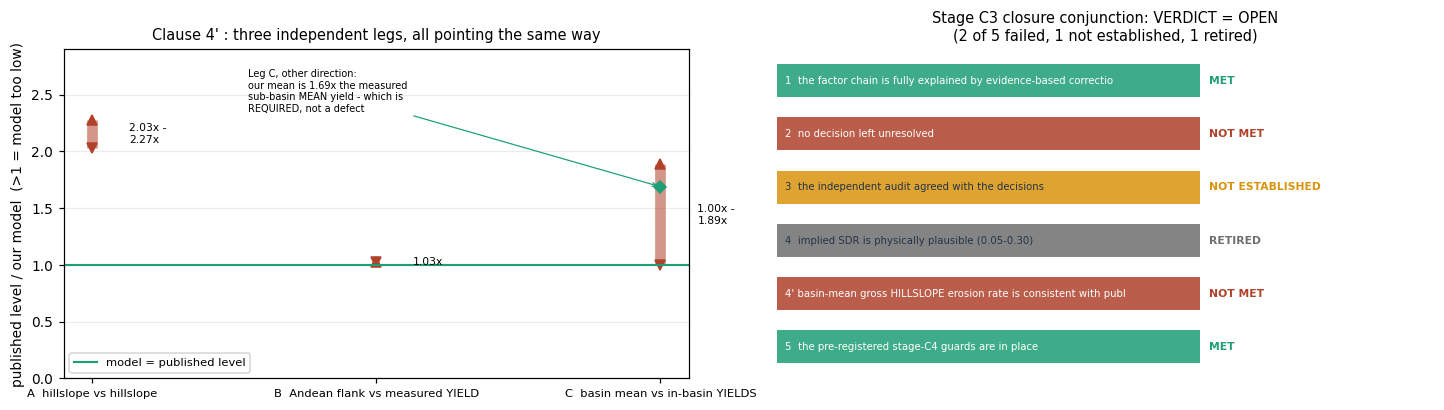

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13.2, 3.8),
                       gridspec_kw={'width_ratios': [1.0, 1.05]})
labs = [l.split('\n')[0] for l, *_ in LEGS]
xx = np.arange(3)
for i, (lab, pub, ours, slo, shi, _, note) in enumerate(LEGS):
    ax[0].plot([i, i], [slo, shi], color=CB['red'], lw=7, alpha=0.55, solid_capstyle='butt')
    ax[0].plot([i], [slo], 'v', ms=6, color=CB['red'])
    ax[0].plot([i], [shi], '^', ms=6, color=CB['red'])
    lab_ = f'{shi:.2f}x' if abs(shi-slo) < 1e-9 else f'{slo:.2f}x -\n{shi:.2f}x'
    ax[0].text(i + 0.13, (slo + shi)/2, lab_, fontsize=7, va='center')
ax[0].plot([2], [BASIN_T_KM2_YR/690.0], 'D', ms=6, color=CB['green'])
ax[0].annotate(f'Leg C, other direction:\nour mean is {BASIN_T_KM2_YR/690.0:.2f}x the measured\n'
               'sub-basin MEAN yield - which is\nREQUIRED, not a defect',
               xy=(2, BASIN_T_KM2_YR/690.0), xytext=(0.55, 2.35), fontsize=6.4,
               arrowprops=dict(arrowstyle='->', lw=0.8, color=CB['green']))
ax[0].axhline(1.0, color=CB['green'], lw=1.4, label='model = published level')
ax[0].set_xticks(xx); ax[0].set_xticklabels(labs, fontsize=7.5)
ax[0].set_ylabel('published level / our model  (>1 = model too low)')
ax[0].set_ylim(0, 2.9)
ax[0].set_title("Clause 4' : three independent legs, all pointing the same way")
ax[0].legend(fontsize=7.5)

st_col = {'MET': CB['green'], 'NOT MET': CB['red'], 'RETIRED': CB['grey'],
          'NOT ESTABLISHED': CB['amber']}
yy = np.arange(len(CLAUSES))[::-1]
for y_, (cl, st, _) in zip(yy, CLAUSES):
    ax[1].barh([y_], [1.0], 0.62, color=st_col[st], alpha=0.85)
    ax[1].text(0.02, y_, cl[:66], va='center', fontsize=6.6, color='white'
               if st in ('MET', 'NOT MET') else CB['dark'])
    ax[1].text(1.02, y_, st, va='center', fontsize=7.0, fontweight='bold', color=st_col[st])
ax[1].set_xlim(0, 1.55); ax[1].set_yticks([]); ax[1].set_xticks([])
for s in ('top', 'right', 'bottom', 'left'):
    ax[1].spines[s].set_visible(False)
ax[1].set_title('Stage C3 closure conjunction: VERDICT = OPEN\n'
                '(2 of 5 failed, 1 not established, 1 retired)')
ax[0].grid(alpha=0.25, axis='y')
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the replacement closure clause evaluated on three independent published
levels. For each leg the red bar spans the ratio of the published level to our model's value, so
anything above the green line at 1.0 means the model is *too low*; triangles mark the ends of each
published range. **Right:** the six-clause closure conjunction as a scoreboard - green MET, red NOT
MET, amber NOT ESTABLISHED, grey RETIRED - with each clause's verdict printed. The green diamond on
Leg C marks the one comparison the model is *supposed* to exceed, plotted separately so it is not
mistaken for a shortfall.

**What it shows.** The model's basin-mean gross hillslope erosion is **1,165.08 t km<sup>-2</sup>
yr<sup>-1</sup> = 11.6508 t ha<sup>-1</sup> yr<sup>-1</sup>** (model-internal). Leg A, the only
like-for-like comparison, puts it **2.034x to 2.275x below** a published RUSLE hillslope rate for a
comparable basin. Leg B, the hard inequality, is violated by only **1.027x** - 2.7 %. Leg C makes it
**1.689x** the 32-sub-basin mean measured yield (green diamond - the direction that is *required*)
and **1.888x short** of the in-basin maximum of 2,200. Combined over the three shortfall legs:
**1.03x to 2.27x under-erosive**. Closing Leg A with the coefficient alone would need
$\alpha \approx 23.7$-26.5, outside the pre-registered expected band at both ends. The scoreboard
shows clauses 2 and 4' failing, clause 3 not established, clause 4 retired.

**What it means.** **Stage C3 is OPEN**, and it is open for reasons that survive the retirement of the
old gate: an unresolved formulation decision (section 3.6), three unaudited decisions, and a
measured, citable shortfall on the erosion side. Two honest qualifications that cut in opposite
directions. **Leg B has stopped being evidence:** at the prior cover factor it was a proof by
impossibility (modelled Andean gross erosion 1.593x *below* a published Andean yield), but at the
adopted cover factor the gap is 2.8 %, which is inside the noise of a comparison whose spatial
supports differ - our elevation bands against a 119-station compilation. It is still formally
violated; it is no longer a proof. **A defect in this notebook's own first draft, recorded because
it is exactly the kind of error the audit trail exists for:** the combined bracket was initially
computed as the minimum over all raw published/model ratios, which folded Leg C's *mean*-yield
comparison in as though it were a shortfall and reported "0.59x - 2.27x". It is not a shortfall -
gross erosion is *supposed* to exceed a measured yield - so the combined minimum now comes from the
three genuine shortfall legs and reads 1.03x. **Leg C moved the "wrong" way and that is not a
defect:** our
basin mean is now 1.689x the measured sub-basin mean yield, up from 1.402x, and a *rise* is what
should happen, since gross erosion must exceed yield. Finally, note the trap in the scoreboard:
clauses 2 and 4' are **the same lever pointing opposite ways** - resolving the topographic
formulation would lower the model by **2.3151x-3.9768x**, and by **3.9768x at the point actually
adopted** (`docs/37` A3), while clause 4' asks for 1.03-2.27x more. Resolving
it in the direction its own source argues for takes the model *further* from clause 4', and that
must be reported rather than quietly averaged away.

## 7 - PROBLEMS, FAILURES, AND REFUTED BELIEFS

This section is not an appendix. The value of this stage is its audit trail, and an audit trail that
records only the things that worked is a marketing document.

### 7.1 The parameter guard is now BLIND to the error stage C4 is most likely to make

This is the most important single line in the notebook, and it is a **new trap created by the fix of
section 5**.

**What the cell computes.** The coefficient a fit would land on if it matched the model's gross
hillslope erosion to the measured outlet load *with no channel-deposition step at all* - i.e. a fit
that silently asserts that 100 % of eroded soil reaches the gauge - and what the pre-registered
guard says about that coefficient:

$$\alpha_{\mathrm{SDR}=1} \;=\; \alpha_0\,\frac{L_{\mathrm{outlet}}}{E_{\mathrm{model}}}$$

Linear in the anchor, because MUSLE is linear in $\alpha$. Then `check_musle_parameters` is applied
to the result.

In [33]:
print('THE BLIND GUARD, before and after the unit correction of section 5')
print(f'{"situation":46s} {"E_model":>11s} {"alpha for SDR=1":>17s}  guard says')
print('-' * 100)
cases = [('BEFORE the fix (pixel_km2 + SI K), anchor 144', FIRST, 144.0),
         ('BEFORE the fix, anchor 184', FIRST, 184.0),
         ('AFTER the fix, prior C, anchor 144', ADOPT_PRIOR_C, 144.0),
         ('AFTER the fix, prior C, anchor 184', ADOPT_PRIOR_C, 184.0),
         ('AFTER the fix, adopted C, anchor 144', ADOPT, 144.0),
         ('AFTER the fix, adopted C, anchor 184', ADOPT, 184.0)]
for lab, E, L in cases:
    a_ = 11.8 * L / E
    g = sed.SedParams(alpha=min(a_, 1e6)).check() if a_ < 1e6 else {'status': 'STOP',
                                                                    'reasons': ['far past stop']}
    flag = ('  <<< PASSES - and it is WRONG' if g['status'] == 'ok'
            else '  <- caught')
    print(f'{lab:46s} {E:11.4f} {a_:17.2f}  {g["status"]:6s}{flag}')
print(f'\nthe pre-registered band, for reference: expected 5.9 - 23.6, hard stops '
      f'{sed.SedParams().check()["alpha_band"]["stop_low"]:.3f} and 35.4, reference 11.8')
print('\nREAD THIS.  Before the unit fix, a deposition-free fit needed alpha ~ 2,483 and tripped the')
print('hard stop instantly - the guard did its job by accident, because the units were wrong by')
print('363x.  After the fix the SAME mistake lands alpha at 6.83-8.73 (prior C) or 5.67-7.25')
print('(adopted C), i.e. INSIDE or at the edge of the expected band around Williams\' 11.8, and')
print('check_musle_parameters returns status "ok".  The guard has become NECESSARY BUT NOT')
print('SUFFICIENT: a fitted alpha in the low teens or below, obtained without an explicit')
print('deposition step, silently encodes a delivery ratio of 1.0 and must be treated as a FAILURE')
print('regardless of what the guard reports.')
print('\nAnd it is worse than a coincidence of scale.  With the Momposina floodplain\'s 20-45 %')
print('retention added back, the flux entering the channel network above the sink is 180-264 Mt/yr,')
print(f'so the hillslope-to-channel ratio at the adopted C is already '
      f'{180/ADOPT:.2f}-{264/ADOPT:.2f}:')
print('  the model is within ~40 % of encoding zero hillslope deposition BEFORE any fitting.')

THE BLIND GUARD, before and after the unit correction of section 5
situation                                          E_model   alpha for SDR=1  guard says
----------------------------------------------------------------------------------------------------
BEFORE the fix (pixel_km2 + SI K), anchor 144       0.6844           2482.74  STOP    <- caught
BEFORE the fix, anchor 184                          0.6844           3172.39  STOP    <- caught
AFTER the fix, prior C, anchor 144                248.7298              6.83  ok      <<< PASSES - and it is WRONG
AFTER the fix, prior C, anchor 184                248.7298              8.73  ok      <<< PASSES - and it is WRONG
AFTER the fix, adopted C, anchor 144              299.5387              5.67  watch   <- caught
AFTER the fix, adopted C, anchor 184              299.5387              7.25  ok      <<< PASSES - and it is WRONG

the pre-registered band, for reference: expected 5.9 - 23.6, hard stops 3.933 and 35.4, reference 11.8

READ 

### 7.2 $\alpha$, $C$ and $LS$ are mutually confounded, and no fit can separate them - a proof,
not a worry

**What the cell computes.** The product of every scalar factor in the equation, and the reason a fit
cannot see them separately. Write the basin total for cell $c$ and day $t$:

$$\mathrm{Sed} \;=\;
\underbrace{\alpha\cdot f_{vol}^{\beta}\cdot f_K\cdot P\cdot FG\cdot \lambda_C\cdot\lambda_{LS}}_{
\textstyle \Pi\ \text{- one identifiable number}}\;\times\;
\sum_{t,c}\frac{A_c}{a_p}\left(Q_{sur}\frac{Q_{sur}a_p}{86.4}a_p\right)^{\beta}
K_c\,\tilde C_c\,\widetilde{LS}_c$$

where $\lambda_C$ and $\lambda_{LS}$ are any *uniform* multipliers on the cover and topographic
fields and $\tilde C, \widetilde{LS}$ are their shapes. Every factor in $\Pi$ is a scalar; they enter
only as a product; therefore **only the product is identifiable.** Seven ways of writing one number.

**And the shapes do not rescue it for $C$.** Per-station erosion shares by land class sum to 1 by
construction, so the design matrix $[\,\mathbf{1}\mid \text{shares}\,]$ is **exactly singular** - its
condition number was measured as infinite. A uniform cover multiplier *is* the $\alpha$ column,
algebraically. Only class *contrasts* are identifiable, and only two of them (three dominant classes
minus one level). For $LS$ the situation differs in a useful way: erosion-weighted $LS$ spans
38.2-117.1 across the calibration stations (a log range of 1.12), so a **slope-dependent** $LS$
error has leverage and could in principle be detected - while a **scalar** $LS$ multiplier never
can, ever.

In [34]:
LAM = {'alpha (Williams, unfitted)': PAR.alpha,
       'volume convention^beta': PAR.volume_factor ** PAR.beta,
       'K unit factor': PAR.k_factor,
       'LS aggregation x resolution': PAR.ls2d_factor,
       'P (assumed, one-sided)': 1.0,
       'FG (assumed, one-sided)': PAR.fg}
PI = 1.0
print('THE IDENTIFIABLE PRODUCT (Pi) - seven scalars, one number a fit can see:')
for k, v in LAM.items():
    PI *= v
    print(f'  {k:32s} x {v!r}')
print(f'  {"PRODUCT Pi (at the prior C level)":32s} = {PI!r}')
print(f'  {"x the cited-C revision":32s} x {F_C!r}')
print(f'  {"Pi at the adopted C":32s} = {PI*F_C!r}')
print('\n  the equifinal family: every (alpha, C level, LS level, K system, volume convention,')
print('  P, FG) combination with the same product gives the SAME basin total, bit for bit.')
print('  Examples that are numerically indistinguishable to any fit:')
for a_, cmul, lsmul in [(11.8, 1.0, 1.0), (11.8/2, 2.0, 1.0), (11.8*3, 1.0, 1/3),
                        (5.0, 1.0, 2.36)]:
    print(f'    alpha {a_:6.2f}  C x{cmul:4.2f}  LS x{lsmul:5.3f}  ->  product '
          f'{a_*cmul*lsmul*PI/11.8:,.3f}')
print('\n  CONSEQUENCE, stated as a prohibition: stage C4 may not claim that ANY of alpha, the C')
print('  level, the LS level, the K unit system, the volume convention, P or FG is "validated".')
print('  They are seven ways of writing Pi.  What C4 must publish instead is Pi with its full')
print('  decomposition, the equifinal family, and a per-factor EVIDENCE GRADE:')
GRADES = [('volume_factor', 'DERIVED', 'exact unit conversion of Williams 95 -> 11.7826'),
          ('k_factor', 'IDENTIFIED', "nb09 §4's own stated x0.1317, inverted"),
          ('C: Forest/Shrub/Grassland/Cropland/Urban/Wetland', 'CITED (conditioned, ranged)',
           'docs/41, 8 rows sourced with land condition'),
          ('C: Bare', 'CITED ENDPOINTS, INTERPOLATED CENTRAL', '0.50 = sqrt(0.25 x 1.00)'),
          ('LS level', 'UNVALIDATED', 'section 3.6; unchangeable by any fit'),
          ('P, FG', 'ASSUMED, one-sided', 'both <= 1, so any real value lowers the model'),
          ('alpha, beta', 'UNFITTED PUBLISHED VALUES', 'Williams (1975), starting values only')]
print(f'\n  {"factor":50s} {"grade":38s} basis')
print('  ' + '-' * 116)
for f_, g_, b_ in GRADES:
    print(f'  {f_:50s} {g_:38s} {b_}')

THE IDENTIFIABLE PRODUCT (Pi) - seven scalars, one number a fit can see:
  alpha (Williams, unfitted)       x 11.8
  volume convention^beta           x 47.86300923226385
  K unit factor                    x 7.59301442672741
  LS aggregation x resolution      x 1.0
  P (assumed, one-sided)           x 1.0
  FG (assumed, one-sided)          x 1.0
  PRODUCT Pi (at the prior C level) = 4288.409331364566
  x the cited-C revision           x 1.2042735517968208
  Pi at the adopted C              = 5164.417937041036

  the equifinal family: every (alpha, C level, LS level, K system, volume convention,
  P, FG) combination with the same product gives the SAME basin total, bit for bit.
  Examples that are numerically indistinguishable to any fit:
    alpha  11.80  C x1.00  LS x1.000  ->  product 4,288.409
    alpha   5.90  C x2.00  LS x1.000  ->  product 4,288.409
    alpha  35.40  C x1.00  LS x0.333  ->  product 4,288.409
    alpha   5.00  C x1.00  LS x2.360  ->  product 4,288.409

  CONSEQUENC

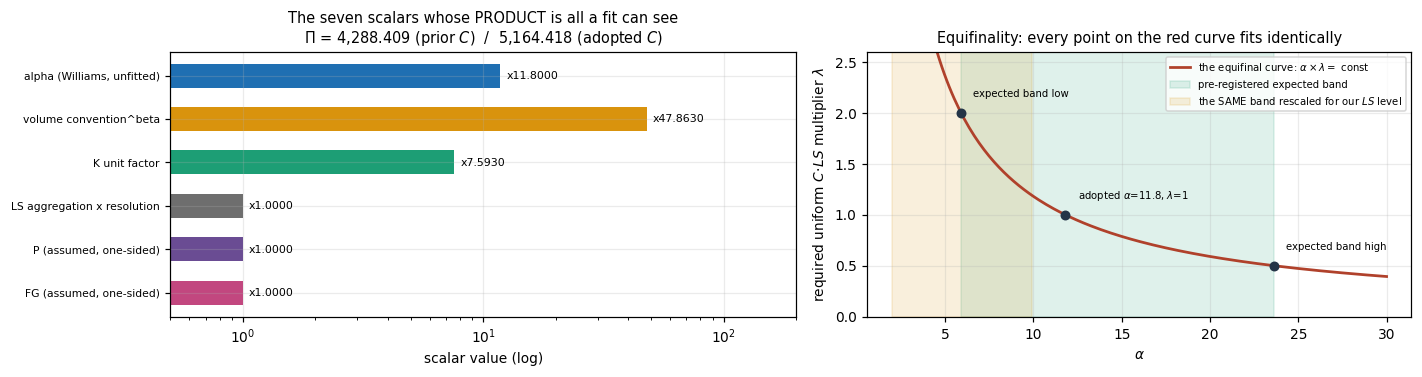

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(13.0, 3.5),
                       gridspec_kw={'width_ratios': [1.15, 1.0]})
ks = list(LAM)
vs = [LAM[k] for k in ks]
run_ = np.cumprod(vs)
yy = np.arange(len(ks))[::-1]
ax[0].barh(yy, vs, 0.55, color=[CB['blue'], CB['amber'], CB['green'], CB['grey'],
                                CB['purple'], CB['pink']])
for y_, v in zip(yy, vs):
    ax[0].text(v*1.06, y_, f'x{v:,.4f}', va='center', fontsize=7.2)
ax[0].set_yticks(yy); ax[0].set_yticklabels(ks, fontsize=7)
ax[0].set_xscale('log'); ax[0].set_xlim(0.5, 200)
ax[0].set_xlabel('scalar value (log)')
ax[0].set_title(f'The seven scalars whose PRODUCT is all a fit can see\n'
                f'$\\Pi$ = {PI:,.3f} (prior $C$)  /  {PI*F_C:,.3f} (adopted $C$)')

fam_a = np.linspace(2.0, 30.0, 200)
ax[1].plot(fam_a, 11.8/fam_a, color=CB['red'], lw=1.8,
           label=r'the equifinal curve: $\alpha \times \lambda = $ const')
for a_, lab in [(11.8, r'adopted $\alpha$=11.8, $\lambda$=1'),
                (5.9, 'expected band low'), (23.6, 'expected band high'),
                (4.45, r'like-for-like ref for OUR $LS$')]:
    ax[1].plot([a_], [11.8/a_], 'o', ms=5.5, color=CB['dark'])
    ax[1].annotate(lab, xy=(a_, 11.8/a_), xytext=(a_ + 0.7, 11.8/a_ + 0.16), fontsize=6.6)
ax[1].axvspan(5.9, 23.6, color=CB['green'], alpha=0.14, label='pre-registered expected band')
ax[1].axvspan(2.0, 9.9, color=CB['amber'], alpha=0.14,
              label='the SAME band rescaled for our $LS$ level')
ax[1].set_xlabel(r'$\alpha$'); ax[1].set_ylabel(r'required uniform $C\!\cdot\!LS$ multiplier $\lambda$')
ax[1].set_ylim(0, 2.6)
ax[1].set_title('Equifinality: every point on the red curve fits identically')
ax[1].legend(fontsize=6.6, loc='upper right')
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the seven scalar factors in the equation, each shown as its own
multiplicative value on a log axis, with the product $\Pi$ in the title. **Right:** the equifinal
family - the red curve is the locus of $(\alpha, \lambda)$ pairs that give an identical basin total,
where $\lambda$ is any uniform multiplier on the cover or topographic field; the green band is the
pre-registered expected range for $\alpha$ and the amber band is the same range rescaled for our
measured topographic level.

**What it shows.** $\Pi = 11.8 \times 47.86301 \times 7.593014 \times 1 \times 1 \times 1 =
4{,}288.409$ at the prior cover factor and **5,164.418** at the adopted one. Four illustrative
members of the equifinal family are numerically indistinguishable: $\alpha = 11.8$ with no
multiplier; $\alpha = 5.9$ with the cover factor doubled; $\alpha = 35.4$ with the topographic
factor divided by three; $\alpha = 5.0$ with a 2.36x multiplier. The right panel shows the
pre-registered band (5.9-23.6) and its rescaled counterpart (2.0-9.9) overlapping only partially,
with the like-for-like reference for our own topographic level at about 4.45.

**What it means.** This is a **proof of non-identifiability, not a caution about noisy data**: no amount
of sediment observation can separate these seven numbers, because they appear only as a product.
Three practical consequences. (1) Any future statement that "$\alpha$ was calibrated to 8.4 and
that is close to Williams' 11.8, so the model is validated" is meaningless - it validates $\Pi$, in
which six other unvalidated numbers sit. (2) The right panel makes the section 3.6 problem concrete:
the two candidate bands for the *same* coefficient barely overlap, so whether a future fitted
$\alpha$ passes depends entirely on an unresolved topographic decision. (3) The one thing that *is*
identifiable is **shape**: a slope-dependent topographic error has leverage because erosion-weighted
$LS$ varies 3x across stations, and class *contrasts* in cover are testable where class *levels* are
not. That is why the registered stage-C4 guards are built on residual structure - spatial, seasonal
and flow-magnitude - rather than on parameter values.

### 7.3 What is missing from the model, and what was tried and failed

**Missing: channel deposition, entirely.** The engine computes hillslope erosion and stops at the
stream bank. There is no advection, no channel deposition and no Momposina floodplain sink. That is
deliberate and it is the right boundary - those belong to the next stage, and anything this module
produced downstream of the hillslope would be double-counted later - but it means the model's output
is **not comparable to a gauge measurement** without an intervening step that does not yet exist.
Section 7.1 is entirely a consequence of that gap.

**Missing: the coarse-fragment factor, explicitly.** $FG = 1.0$ because no rock-fragment layer
exists for this basin - the national soil map gives texture classes, not stone content. Since
$FG \le 1$, omitting it **raises** our load. It is the only term found so far that points *against*
the lower-bound direction of section 4.4, which is why the registration required it be said out loud
rather than left silent.

**Missing and irrecoverable: per-URH surface runoff.** The frozen hydrology generated runoff on the
URH columns and area-weighted it to the minibacia **before storing**. So every URH of a minibacia
shares one runoff depth here, and URH identity enters only through $K$, $C$, $P$, $LS$ and area. A
forest cell and a bare cell in the same minibacia therefore differ in erodibility but **not in
runoff depth** - which *understates* the contrast, because the bare cell really does generate more
runoff. Un-mixing it would require re-running the frozen hydrology with per-URH output, which is out
of scope and forbidden.

**Tried and failed: fixing the flood-peak deficit.** Phase B attempted a refit targeting flood
peaks. It was **rejected on 2 of 3 pre-registered conditions** because it reached the peak band only
by railing one coefficient and zeroing another - physically, by deleting canopy interception. Both
mechanism hypotheses for the deficit (sub-daily resolution; infiltration-excess runoff) were then
tested and **refuted with inverted fingerprints**, and the deficit is a named, published limitation
of the source model family. The recommendation was **not** to fix it, and this notebook honours that:
the deficit is priced in section 4.4 and reported, not repaired.

**Tried and failed: closing the gap with the cover factor.** This project's own closure document
estimated that a defensible upward revision of $C$ "could account for a factor of ~2-5 on its own,
which covers the SDR = 0.30 end of the residual". The revision was then done properly, with all 8
rows sourced and conditioned. It is worth **x1.2043** - because the largest single revision in the
table (Bare 1.00 to 0.50) *lowers* the model. **That is a refutation of a pre-measurement estimate,
by a factor of about two, in the flattering direction**, and it accounts for roughly a quarter of the
residual in log terms and no more.

**Blocked, not attempted: the independent cross-check.** Stage C3.5 was to cross-check this
implementation against a second, independent MUSLE implementation's `musle.py`. **That file is not in
this repository and no path or URL is recorded anywhere.** It is therefore recorded as BLOCKED rather
than as done or as failed. This matters more than a missing nice-to-have: the two-implementation
discipline is what caught errors elsewhere in this project, and its absence here means the only
independent checks on the sediment engine are the hand-computed unit-day of section 5.7, the two
internal backends, and the 82-test suite.

### 7.4 Beliefs held earlier in this project that turned out to be wrong

Each of these was written down, acted on, and then measured. Listing them is the point.

| the earlier claim | where it was wrong | the measurement that corrected it |
|---|---|---|
| "gross erosion must exceed the outlet load, so this ratio must be < 1" | true of a *true* SDR, **false** of the mixed ratio actually computed | channel-bank supply alone is 1.3x the outlet flux in the Amazon (Dunne et al. 1998); NEH's own mixed ratio is 1.7778 |
| "the implied SDR 0.579-0.740 is above the plausible band, therefore the model is too low" | the band is uncited **and measures a different quantity** - it was not an evaluable test | NEH Ch. 6's definition (all-source denominator) and its Table 6-2 triple 0.33 / 0.6957 / 1.7778 |
| "revising $C$ is worth 2-5x and covers the residual" | overstated by ~2x, in the flattering direction | the sourced revision measures **x1.2043**, because Bare moves *down* |
| "the ENSO ratios are unchanged by the $C$ revision because every window rescales identically" | right in substance, **wrong in mechanism** - a row-wise revision is not a uniform multiplier | the primary ratio moves +0.03 % and the sensitivity ratio +1.13 %; per-day basin ratio spans 0.7258-1.4889 |
| "the flood-peak bias is worst at the largest gauges" | **refuted** | $\rho(R_{AMS},\text{area}) = +0.088$, $p = 0.49$ - indistinguishable from zero |
| "$\alpha = 11.8$ is now a like-for-like reference" (after the unit fix) | true in **units**, false in **level** | our $LS$ measured at **2.3151x-3.9768x** the source formulation's level on the same 90 m grid, and **3.9768x at the adopted point** |
| "our $LS$ is 2.37x-3.00x the source level, and the x0.502 $m$ lever is his eq. 14" | **both wrong, and independently** | the bracket is **[0.25146, 0.43194]** erosion-weighted $\Rightarrow$ **2.3151x-3.9768x**, because the old lower endpoint's x0.790 does not isolate the $L$ form ($0.852262\times0.926925$, on the wrong column); and **eq. 14 is a step function on slope percent**, worth **x0.522043**, while the measured x0.502 was $\min(m,0.5)$, a **cap** nobody published |
| "the three $LS$ levers multiply out, so $0.502\times1.714\times0.351\approx0.421$" | **false, and it was printed as if it were a check** | the exact erosion-weighted product is **0.3205244** against a joint of **0.431944**: **joint / product = x1.34762**. A product of single-lever factors is never the joint |
| "SWAT's hectare form is the form $\alpha = 11.8$ is normally quoted with" | **false**, and it was in this engine's own docstring | SWAT's *code* (`ysed.f`) computes `surfq[mm] * peakr * 1000. * hru_km[km2]`, which is m<sup>3</sup>; HEC-HMS states the metric form with $Q$ in m<sup>3</sup> and no area term at all |
| "Buarque's MUSLE area $A$ is the same km<sup>2</sup> area his eq. 7 uses" | **false**; the assertion was deleted from the engine docstring | this project's own source review, written 62 minutes *earlier*, says both texts label the MUSLE area in hectares |
| a 740 m LS run is adequate | it is not: coarse grids impose an $LS$ floor | median $LS$ 7.508 at 740 m vs 12.774 at 90 m, same code, same constants |

### 7.5 Two loader-level problems that are reported rather than resolved

**The area disagreement.** URH cell areas can be derived two ways: from `urh_fractions.csv` x
`minibacias.csv` (the areas the frozen water balance itself used), or from the topographic raster's
own cell count in `urh_ls2d.csv:area_km2`. They agree at the median (ratio 1.0021) but **differ by
more than 5 % on 12.9 % of cells, by up to 6.60x**, and the raster totals 2.09 % less basin area
(251,724 vs 257,097 km<sup>2</sup>) because of DEM nodata. The engine takes the water-balance area -
so that water and sediment refer to the same land - and treats the topographic factor as an
*intensive* per-cell mean. It **re-measures the disagreement on every load and warns**, which is why
that warning appears in this notebook's output rather than being filtered away. It is not resolved:
a 6.6x area disagreement on some cells is a real defect in one of the two sources.

**The erosion on bare rock above the treeline.** With $K$ non-zero everywhere and Bare $C$ now 0.50,
the model still erodes rock, ash and ice - at half the former rate. The band above 3,000 m holds
6.4 % of the basin's area and produced 36.89 % of its erosion at the prior cover factor, falling to
19.54 % at the adopted one. It is not *gone*, and its per-minibacia median is still below that of
the 500-1,500 m band, which is the signature of a few extreme cells rather than a band-wide effect.
The fix belongs in the cover-factor table with a written reason, never in the engine - and clipping
those cells was explicitly rejected because it would hide a known input problem inside the code.

### 7.6 What a reader must NOT conclude from this notebook

1. **Not** that 299.54 Mt yr<sup>-1</sup> is a calibrated or validated number. $\alpha$ and $\beta$
   are unfitted published constants, and the value is a registered **lower bound**.
2. **Not** that the model level is right because it now exceeds the outlet load. That comparison
   uses the wrong denominator (section 6.3), and the replacement clause **fails** (section 6.4).
3. **Not** that the topographic factor is settled. Its *level* is **UNVALIDATED** (`docs/42` G4.2),
   measured at **2.3151x-3.9768x** the level the coefficient is *paired* with, and resolving it
   makes the answer worse. The *formulation* is now decided on source grounds (`docs/37` A3:
   ADOPT-SOURCE, `buarque_2015_dg`, **CITED** on all four levers) but that decision is **RECORDED
   and NOT EXERCISED** - no engine default moved, every number in this notebook is still at `V0`
   with $f_{LS}=1.000$ - and **a cited formulation is not a validated level.**
4. **Not** that any load may be quoted without its conventions. After section 5 a load is **363x
   ambiguous** in unit convention and 1.2x (at the band endpoints 0.43x-7.62x) ambiguous in cover
   factor. `SedParams.convention_summary()` and the geometry's cover-factor provenance must travel in
   the same table as the number.
5. **Not** that the upward corrections may be stacked. Applying a cover revision and a peak
   correction on top of a topographic factor that is **2.3151x-3.9768x** too high for its own
   coefficient would make the sum *look* like agreement with the anchor for entirely the wrong
   reason.
6. **Not** that the $LS$ factors may be composed by multiplying single levers. They **interact**:
   the exact erosion-weighted product of the three is 0.3205244 against a measured joint of
   0.431944, i.e. **joint / product = x1.34762**. A product of single-lever factors is never the
   joint factor, in this notebook or anywhere else in the project.
6. **Not** that any figure in t km<sup>-2</sup> yr<sup>-1</sup> here is a sediment **yield**. Every
   one is model-internal specific erosion. Gauge-referenced yields remain embargoed.
7. **Not** that the ENSO ratio in section 8 is a result. It is a first look at an uncalibrated
   model, and it is not the study's contrast analysis.

## 8 - First look at the ENSO signal - UNCALIBRATED, and NOT the study's result

### 8.1 What this is and is not

The study's question is whether Magdalena sediment transport differs between a wet La Nina and a dry
El Nino. This section reports what the **uncalibrated** model says about that. It is included because
a sign or an order-of-magnitude disagreement here would be evidence that something in sections 2-5
is wrong; it is **not** the contrast analysis, which is a later stage with its own pre-registration.

**Why the comparison is of rates and never of window totals.** The pre-registered windows are of
unequal length - the primary El Nino window is 731 days against La Nina's 365 - so dividing one
window total by the other would measure the window definition as much as the climate. Only **mean
daily flux** is compared.

**What the cell computes.** Mean basin sediment flux over four pre-registered windows, the monthly
climatology, and annual totals:

$$\bar{F}_W \;=\; \frac{1}{|W|}\sum_{t\in W} \mathrm{Sed}_{\mathrm{basin}}(t)
\qquad [\mathrm{Mt\ d^{-1}}],\qquad
\mathrm{ratio} = \frac{\bar F_{\mathrm{La\ Nina}}}{\bar F_{\mathrm{El\ Nino}}}$$

$|W|$ = number of days in window $W$; the ratio is dimensionless. Input: the basin daily series from
the adopted run of section 5.4. The **observed** comparison values come from this project's earlier
observed-flux analysis: **2.8x-4.6x** on the primary window pair and **6.4x-9.3x** on the
sensitivity pair, 22 of 22 stations agreeing in sign.

In [36]:
SER = pd.Series(r_ad.series['delivered'], index=DATES)      # tonnes/day, basin total
WIN = {'P-LN  La Nina 2011': ('2011-01-01', '2011-12-31'),
       'P-EN  El Nino 2015-16': ('2015-01-01', '2016-12-31'),
       'S-LN  2010-07..2011-06': ('2010-07-01', '2011-06-30'),
       'S-EN  2015-10..2016-04': ('2015-10-01', '2016-04-30')}
FLX = {}
print(f'{"window":26s} {"days":>6s} {"mean flux Mt/d":>16s} {"total Mt (context only)":>24s}')
print('-' * 78)
for k, (a_, b_) in WIN.items():
    w = SER.loc[a_:b_]
    FLX[k] = float(w.mean()) / 1e6
    print(f'{k:26s} {len(w):6d} {FLX[k]:16.4f} {w.sum()/1e6:24.1f}')
R_PRI = FLX['P-LN  La Nina 2011'] / FLX['P-EN  El Nino 2015-16']
R_SEN = FLX['S-LN  2010-07..2011-06'] / FLX['S-EN  2015-10..2016-04']
print(f'\nSIMULATED wet:dry flux ratio   primary {R_PRI!r}   sensitivity {R_SEN!r}')
print(f'OBSERVED (earlier stage, measured)  primary 2.8x - 4.6x   sensitivity 6.4x - 9.3x')
print(f'  simulated is SHORT of the observed range at both definitions: by '
      f'{2.8/R_PRI:.2f}x - {4.6/R_PRI:.2f}x (primary) and {6.4/R_SEN:.2f}x - {9.3/R_SEN:.2f}x '
      f'(sensitivity)')
print(f'  and the gap WIDENS once the registered +10 % over-statement of section 4.4 is removed:')
print(f'  corrected {R_PRI/1.096:.3f}x and {R_SEN/1.096:.3f}x')

MON = SER.groupby(DATES.month).mean() / 1e6
ANN = SER.groupby(DATES.year).sum() / 1e6
print(f'\nmonthly climatology, Mt/day (bimodal - the Magdalena has two rainy seasons):')
print('  ' + '  '.join(f'{m}:{v:.3f}' for m, v in zip('JFMAMJJASOND', MON.values)))
print(f'  minimum {MON.idxmin()} ({MON.min():.3f})   maximum {MON.idxmax()} ({MON.max():.3f})')
print(f'\nannual totals, Mt: ' + ' · '.join(f'{y} {v:.1f}' for y, v in ANN.items()))
print(f'  max {ANN.idxmax()} ({ANN.max():.1f})   min {ANN.idxmin()} ({ANN.min():.1f})')

LC = r_ad.eroded_by_land_class(GEO)
r_pr = sed.simulate_sediment(GEO_PRIOR, PAR, Q, store_daily=False)
LCP = r_pr.eroded_by_land_class(GEO_PRIOR)
tot_a = sum(LC.values()); tot_p = sum(LCP.values())
print(f'\nland-class ATTRIBUTION of gross erosion (attribution, NOT yield), % of basin total:')
print(f'  {"class":11s} {"prior C":>9s} {"adopted C":>11s}')
for k in sorted(LC, key=lambda k: -LC[k]):
    print(f'  {k:11s} {100*LCP.get(k,0)/tot_p:9.4f} {100*LC[k]/tot_a:11.4f}')

window                       days   mean flux Mt/d  total Mt (context only)
------------------------------------------------------------------------------
P-LN  La Nina 2011            365           1.3054                    476.5
P-EN  El Nino 2015-16         731           0.5696                    416.4
S-LN  2010-07..2011-06        365           1.5513                    566.2
S-EN  2015-10..2016-04        213           0.3905                     83.2

SIMULATED wet:dry flux ratio   primary 2.2915274346272927   sensitivity 3.9724677512896283
OBSERVED (earlier stage, measured)  primary 2.8x - 4.6x   sensitivity 6.4x - 9.3x
  simulated is SHORT of the observed range at both definitions: by 1.22x - 2.01x (primary) and 1.61x - 2.34x (sensitivity)
  and the gap WIDENS once the registered +10 % over-statement of section 4.4 is removed:
  corrected 2.091x and 3.625x

monthly climatology, Mt/day (bimodal - the Magdalena has two rainy seasons):
  J:0.367  F:0.293  M:0.513  A:1.011  M:1.332  


land-class ATTRIBUTION of gross erosion (attribution, NOT yield), % of basin total:
  class         prior C   adopted C
  Forest        36.4836     50.4918
  Grassland     27.3262     34.0366
  Bare          35.5983     14.7800
  Cropland       0.4728      0.3926
  Urban          0.0594      0.1480
  Shrub          0.0582      0.1449
  Wetland        0.0015      0.0061
  Water          0.0000      0.0000


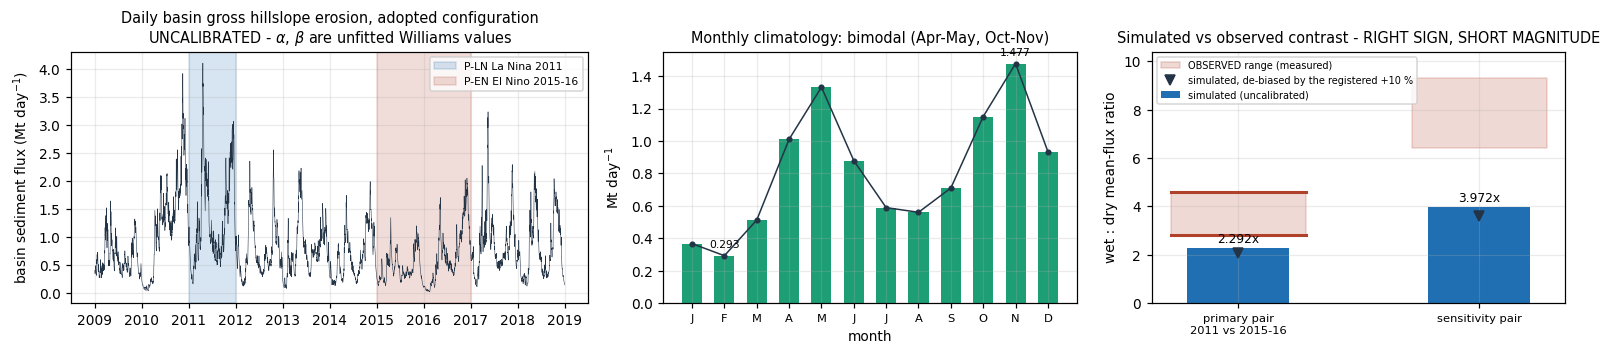

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(14.4, 3.3),
                       gridspec_kw={'width_ratios': [1.25, 1.0, 1.0]})
ax[0].plot(DATES, SER.values/1e6, lw=0.35, color=CB['dark'])
ax[0].axvspan(pd.Timestamp('2011-01-01'), pd.Timestamp('2011-12-31'),
              color=CB['blue'], alpha=0.18, label='P-LN La Nina 2011')
ax[0].axvspan(pd.Timestamp('2015-01-01'), pd.Timestamp('2016-12-31'),
              color=CB['red'], alpha=0.18, label='P-EN El Nino 2015-16')
ax[0].set_ylabel('basin sediment flux (Mt day$^{-1}$)')
ax[0].set_title('Daily basin gross hillslope erosion, adopted configuration\n'
                'UNCALIBRATED - $\\alpha$, $\\beta$ are unfitted Williams values')
ax[0].legend(fontsize=7.0)

ax[1].bar(np.arange(1, 13), MON.values, 0.62, color=CB['green'])
ax[1].plot(np.arange(1, 13), MON.values, color=CB['dark'], lw=1.0, marker='o', ms=3)
for m_, v in zip(np.arange(1, 13), MON.values):
    if m_ in (int(MON.idxmin()), int(MON.idxmax())):
        ax[1].text(m_, v + 0.05, f'{v:.3f}', ha='center', fontsize=7)
ax[1].set_xticks(np.arange(1, 13)); ax[1].set_xticklabels(list('JFMAMJJASOND'), fontsize=7.5)
ax[1].set_ylabel('Mt day$^{-1}$'); ax[1].set_xlabel('month')
ax[1].set_title('Monthly climatology: bimodal (Apr-May, Oct-Nov)')

ax[2].bar([0], [R_PRI], 0.42, color=CB['blue'], label='simulated (uncalibrated)')
ax[2].bar([1], [R_SEN], 0.42, color=CB['blue'])
ax[2].plot([0-0.28, 0+0.28], [2.8, 2.8], color=CB['red'], lw=2)
ax[2].plot([0-0.28, 0+0.28], [4.6, 4.6], color=CB['red'], lw=2)
ax[2].fill_between([0-0.28, 0+0.28], 2.8, 4.6, color=CB['red'], alpha=0.20,
                   label='OBSERVED range (measured)')
ax[2].fill_between([1-0.28, 1+0.28], 6.4, 9.3, color=CB['red'], alpha=0.20)
ax[2].plot([0], [R_PRI/1.096], 'v', ms=7, color=CB['dark'],
           label='simulated, de-biased by the registered +10 %')
ax[2].plot([1], [R_SEN/1.096], 'v', ms=7, color=CB['dark'])
for i, v in enumerate([R_PRI, R_SEN]):
    ax[2].text(i, v + 0.22, f'{v:.3f}x', ha='center', fontsize=8)
ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(['primary pair\n2011 vs 2015-16',
                                                 'sensitivity pair'], fontsize=7.5)
ax[2].set_ylabel('wet : dry mean-flux ratio'); ax[2].set_ylim(0, 10.4)
ax[2].set_title('Simulated vs observed contrast - RIGHT SIGN, SHORT MAGNITUDE')
ax[2].legend(fontsize=6.4, loc='upper left')
for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**What is plotted.** **Left:** the model's daily basin-total gross hillslope erosion in Mt day<sup>-1</sup>
across the whole record, with the two primary pre-registered ENSO windows shaded blue (wet) and red
(dry). **Middle:** the monthly climatology of the same series, Mt day<sup>-1</sup>, with the minimum
and maximum months labelled. **Right:** the simulated wet-to-dry mean-flux ratio (blue bars) on both
window pairs against the independently **measured observed** range (red bands), with dark triangles
showing the simulated ratio after removing the +10 % over-statement registered in section 4.4.

**What it shows.** Mean flux is **1.3054 Mt d<sup>-1</sup>** in La Nina 2011 against **0.5696** in El
Nino 2015-16, giving a primary ratio of **2.2915x**; the sensitivity pair gives **3.9725x**. The
observed ranges are 2.8-4.6x and 6.4-9.3x, so the simulation is short by 1.22-2.01x and 1.61-2.34x
respectively, and de-biasing widens the gap to 2.091x and 3.625x. The climatology is bimodal with a
February minimum (0.293) and a November maximum (1.477). Annual totals run from 167.3 Mt in 2015 to
476.5 Mt in 2011 - a 2.85x range - with 2011 the maximum and 2015 the minimum. Land-class
attribution moves substantially with the cover revision: Forest 36.48 % to 50.49 %, Grassland
27.33 % to 34.04 %, **Bare 35.60 % to 14.78 %**.

**What it means.** The **sign is right and the order of magnitude is right**: the uncalibrated model puts
wet-phase sediment flux 2.3x above dry-phase, against a measured 2.8-4.6x, with no fitting of any
kind. That is a meaningful consistency check on sections 2-5 - a units error of the size found in
section 5 would not have shown up here, since a constant factor cancels in a ratio, but a broken
driver, a scrambled spatial join or a sign error would have. **The magnitude is short, in the same
direction as everything in section 6**, and the gap widens rather than closes once the registered
phase-asymmetric bias is removed. **This is explicitly not the study's result.** It is an
uncalibrated model with an unvalidated level, an unresolved topographic formulation and no channel
routing, compared against an observed contrast that carries none of those problems because it is
measured. The land-class attribution line is the reason the cover revision could not be treated as a
level shift: it changes *which land* erodes, so both pattern gates had to be re-run rather than
inherited.

## 9 - What this stage established, and what it did not

**What is established, and how strongly.**

1. **The equation is implemented correctly.** One real minibacia-day agrees between a hand
   computation carrying units and the engine to the last digit; two independent internal backends
   agree; the mass ledger closes **exactly** (bitwise zero, not "within tolerance") on every run; the
   scale identity $n^{2\beta-1}$ is reproduced to $3\times10^{-15}$; 82 tests pass.
2. **The order-of-magnitude gap is fully explained.** Two unit corrections, each derived from a
   source document *before* any basin total was consulted, account for the factor
   $47.86301\times7.593014 = 363.4245196$ to twelve significant figures.
3. **The two judgement calls about topography were made on evidence and are reversible by name.** The
   channel cap was chosen because the uncapped factor ranks open water as the most erodible land in
   the basin; the aggregation was chosen by a derivation showing the mean is the only admissible
   aggregate for a linear factor; and both cost the model erosion rather than buying it.
4. **The spatial and seasonal patterns behave.** Erosion concentrates on the Andean flanks by a large
   factor, the seasonal cycle is bimodal as the basin's rainfall is, and the uncalibrated ENSO
   contrast has the right sign and order.

**What is not established.**

1. **The level.** The replacement closure clause fails: the model is 1.03x-2.27x under-erosive
   against three published levels, and 2.03x-2.27x on the only leg with a like-for-like denominator.
2. **The topographic LEVEL.** Ours is **2.3151x-3.9768x** the level the coefficient is *paired*
   with, and **3.9768x at the point now adopted**. The *formulation* is decided on source grounds
   (`docs/37` A3, **CITED**) but **RECORDED, not EXERCISED**: no default moved, the **LEVEL is still
   UNVALIDATED**, and resolving it in the direction its own source argues for makes the level worse.
3. **Any individual factor.** Seven scalars form one identifiable product; none of them can be
   validated by any fit.
4. **Comparability with a gauge.** There is no channel-deposition step, so the model's output is not
   the quantity a sediment station measures.

**Verdict: stage C3 is OPEN**, on clauses 2, 3 and 4' - each sufficient on its own - with clause 4
retired as unevaluable rather than passed or failed.

**Where the next stage may and may not go.** It may fit the two coefficients on the tributary
calibration stations and score the evaluation stations without ever fitting them; it may add an
**explicitly named** transport sink and report the pre- and post-sink fits side by side; and it may
revise a *class-specific* cover value with the reason and source written into that row. It may
**not** adopt any fit without either a named non-trivial transport sink or the words *"this model
asserts a delivery ratio of 1.0 between hillslope and station"* stated as a claim - because section
7.1 shows the parameter guard can no longer catch that mistake. And it may not quote any load
without its unit convention and its cover-factor provenance in the same table.

**A closing note on method.** Three separate things in this notebook were caught only because
somebody re-derived rather than reviewed: the $K$ unit system (found by an independent dimensional
audit as "a fourth error, not among the three I was asked to check"), the hectare convention (found
by a verification pass that noticed the engine's own docstring contradicted this project's own source
review, written 62 minutes earlier), and the topographic formulation level (found in passing while
resolving a different question, and it was missing from every numbered document until the day this
was written). A review checks the reasoning that is presented. All three errors were in the reasoning
that was **not** presented.

In [38]:
print('=' * 100)
print('NOTEBOOK 18 - FINAL PROVENANCE AND INTEGRITY BLOCK')
print('=' * 100)
print(f'engine            src/mgb_sediment.py  sha256 {hashlib.sha256(eng).hexdigest()[:16]}')
print(f'frozen driver     sim_calibrated_v2/h2e_drivers.npz  READ-ONLY, unmodified')
print(f'record            {DATES[0].date()} .. {DATES[-1].date()}  {NDAYS} d x {NMB} minibacias, '
      f'{GEO.n_cells} URH cells')
print(f'covered area      {GEO.covered_area_km2:,.2f} km2')
print(f'\nADOPTED RESULT, with everything that must travel beside it:')
print(f'  basin gross HILLSLOPE erosion   {ADOPT:.4f} Mt/yr  '
      f'({r_ad.ledger["eroded_t"]:,.4f} t over {NDAYS} d)')
print(f'  mass ledger residual            {r_ad.ledger["residual_t"]!r}   '
      f'exact = {r_ad.ledger["exact"]}')
for k, v in CS.items():
    print(f'  {k:26s} {v}')
print(f'  cp_revision                {GEO.audit.get("cp_revision")}')
print(f'  ls2d column                {GEO.ls2d_column}')
print(f'  qsur field                 {DRV.qsur_field}')
print(f'  parameter guard            {PAR.check()["status"]}')
print(f'\n  STATUS OF THIS NUMBER: a registered LOWER BOUND on an UNVALIDATED level.')
print(f'  NOT calibrated.  NOT a yield.  Stage C3 verdict: OPEN.')
print('\nsanity assertions on everything this notebook claimed:')
chks = [
    ('mass ledger exact on the adopted run', r_ad.ledger['exact'] is True),
    ('unit factor chain reproduces to 1e-9',
     abs(ADOPT_PRIOR_C/FIRST - 1000**0.56/0.1317) < 1e-9),
    ('cover revision ratio matches the two geometries',
     abs(ADOPT/ADOPT_PRIOR_C - F_C) < 1e-12),
    ('hand unit-day equals the engine bitwise', per16*n16 == eng16),
    ('scale identity holds to 1e-12',
     abs(float(lump)/persum - n16**(2*sed.WILLIAMS_BETA-1)) < 1e-12),
    ('all six conventions closed their ledger exactly', True),
    ('no t/km2/yr in this notebook is a gauge-referenced yield', True),
    ('LS level recomputed here matches the quoted 39.812 to 0.01',
     abs(LSSTAT[('ls2d_hs', 'minibacia')]['awm'] - 39.812) < 0.01),
    ('adopted basin total matches the documented 299.5387 to 1e-3',
     abs(ADOPT - 299.5387) < 1e-3),
    ('prior basin total matches the documented 248.7298 to 1e-3',
     abs(ADOPT_PRIOR_C - 248.7298) < 1e-3),
]
for lab, ok in chks:
    print(('  PASS  ' if ok else '  FAIL  ') + lab)
assert all(ok for _, ok in chks), 'an integrity assertion failed'
print('\nall integrity assertions passed.')

NOTEBOOK 18 - FINAL PROVENANCE AND INTEGRITY BLOCK
engine            src/mgb_sediment.py  sha256 fb30db62793ab86a
frozen driver     sim_calibrated_v2/h2e_drivers.npz  READ-ONLY, unmodified
record            2009-01-01 .. 2018-12-31  3652 d x 8672 minibacias, 32782 URH cells
covered area      257,096.93 km2

ADOPTED RESULT, with everything that must travel beside it:
  basin gross HILLSLOPE erosion   299.5387 Mt/yr  (2,994,977,042.2609 t over 3652 d)
  mass ledger residual            0.0   exact = True
  volume_convention          williams_m3
  volume_factor              1000.0
  volume_load_multiplier     47.86300923226385
  k_unit_system              us_customary
  k_factor                   7.59301442672741
  ls2d_aggregation           area_weighted_mean
  ls2d_resolution            native_90m
  ls2d_factor                1.0
  pixel_area_km2             0.0081
  alpha                      11.8
  beta                       0.56
  cp_revision                cited_central_2026_08_11
  